# Code for "Computing Optimal Cancer Treatment Schedules Using a Mathematical Model of Treatment Resistance" 
## Charles D. Kocher, Joseph O. Deasy, Damon R. Reed, Larry Norton, Corey Weistuch.
### Memorial Sloan Kettering Cancer Center, New York, NY, USA.

This notebook creates all the figures for the above paper except the algorithm schematic, which was created in PowerPoint. Correspondence should be sent to weistucc@mskcc.org.

In [1]:
# import statements
import CHORD_utils as CU
import schedule_utils as SU
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time
import copy
%matplotlib inline

## Fig 1. Schematics of the proposed alternate schedules that are being tested

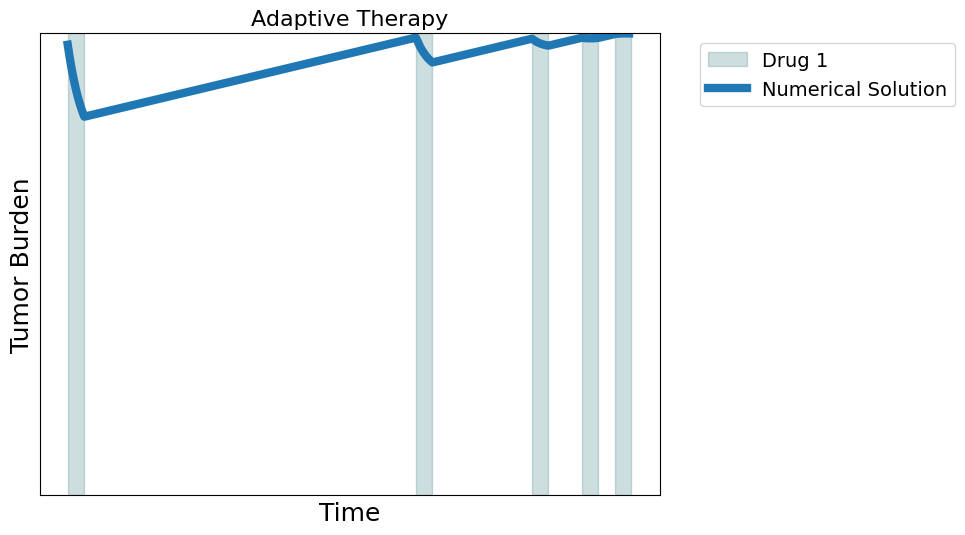

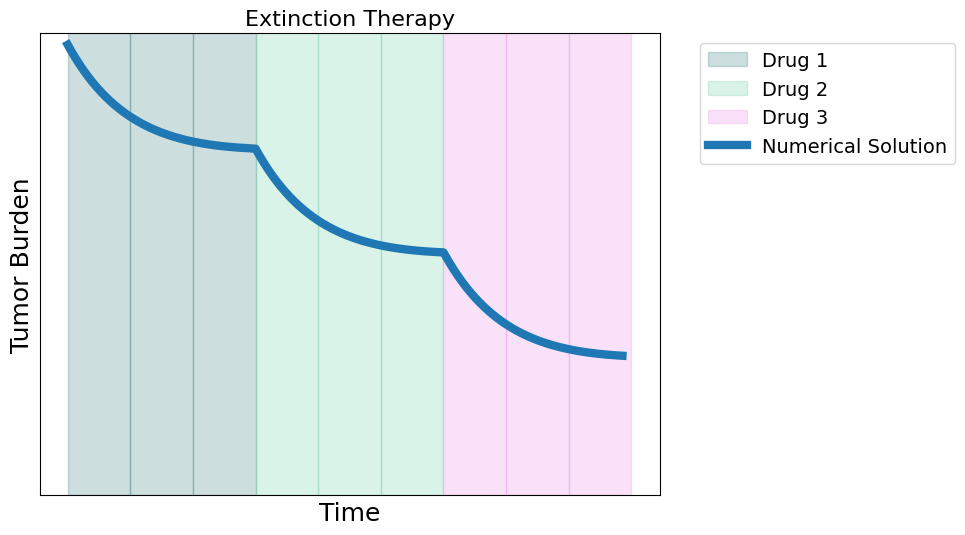

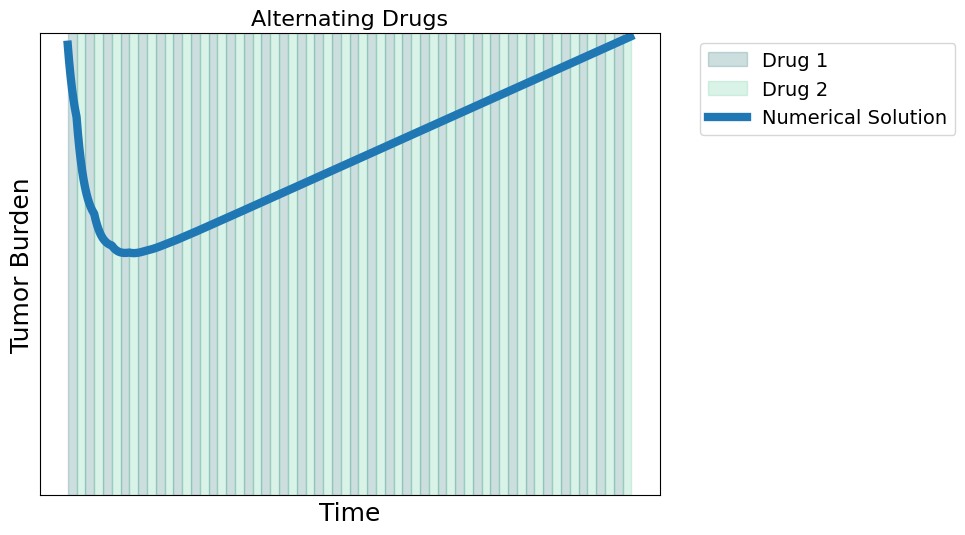

In [2]:
# set up parameters
gamma = np.log(2)/20
deltamult1 = 30
rmult1 = 4
smult1 = 0
deltamult2 = 30
rmult2 = 4
smult2 = 0
deltamult3 = 30
rmult3 = 4
smult3 = 0
params = [gamma, [deltamult1 * gamma, deltamult2 * gamma, deltamult3 * gamma], [rmult1 * gamma, rmult2 * gamma, rmult3 * gamma], [smult1 * gamma, smult2 * gamma, smult3 * gamma]]
timepercycle = 7

# adaptive therapy
alternatingstrategy = [{0},set(),set(),set(),set(),set(),set(),set(),set(),set(),set(),set(),set(),set(),set(),set(),set(),set(),set(),set(),set(),{0},set(),set(),set(),set(),set(),set(),{0},set(),set(),{0},set(),{0}]
fig = SU.full_sim(params,alternatingstrategy,timepercycle=timepercycle)
analyticalt,analyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],alternatingstrategy,timepercycle, *params)
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Adaptive Therapy',fontsize=16)
plt.ylim([1,2e12])
plt.ylabel('Tumor Burden')
plt.yticks([])
plt.xticks([])
plt.show()

# second-strike
alternatingstrategy = [{0},{0},{0},{1},{1},{1},{2},{2},{2}]
fig = SU.full_sim(params,alternatingstrategy,timepercycle=timepercycle)
analyticalt,analyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],alternatingstrategy,timepercycle, *params)
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Extinction Therapy',fontsize=16)
plt.ylim([1,2e12])
plt.ylabel('Tumor Burden')
plt.yticks([])
plt.xticks([])
plt.show()

# alternating
alternatingstrategy = [{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1},{0},{1}]
fig = SU.full_sim(params,alternatingstrategy,timepercycle=timepercycle)
analyticalt,analyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],alternatingstrategy,timepercycle, *params)
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Alternating Drugs',fontsize=16)
plt.ylim([1,2e12])
plt.ylabel('Tumor Burden')
plt.yticks([])
plt.xticks([])
plt.show()

## Fig 3. The three types of optimal schedules for one drug. 

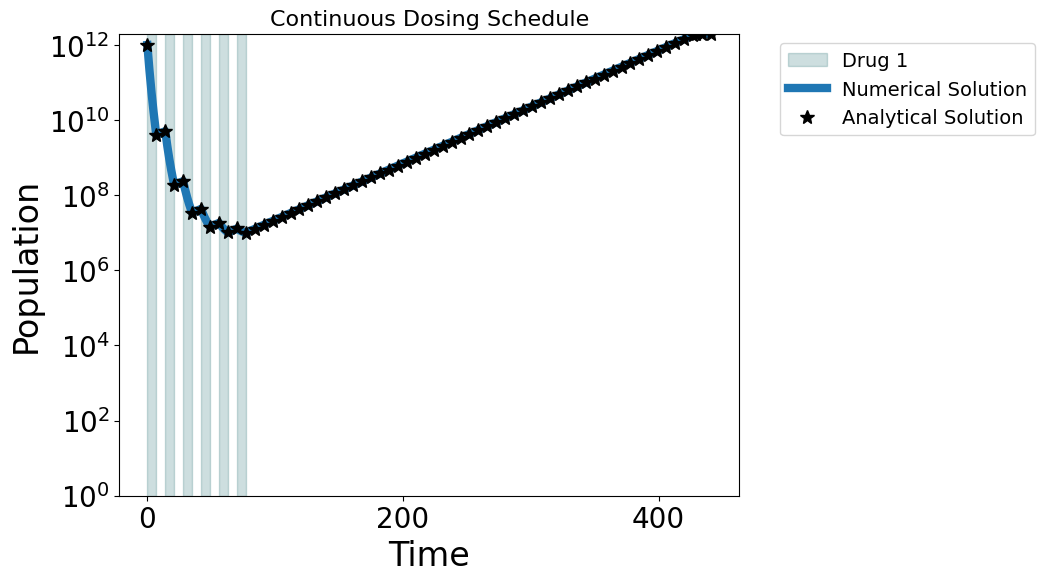

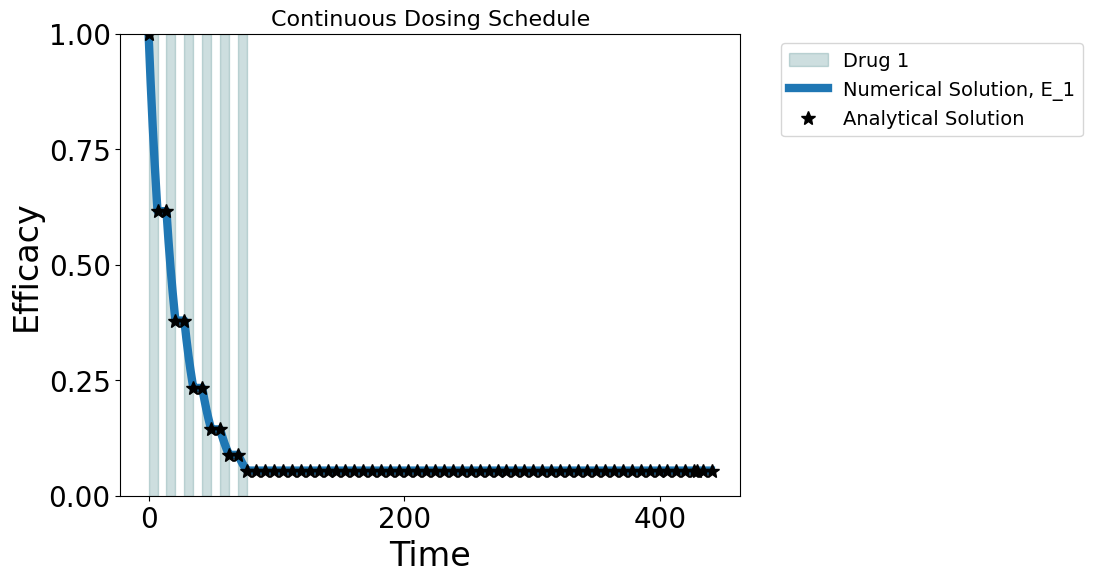

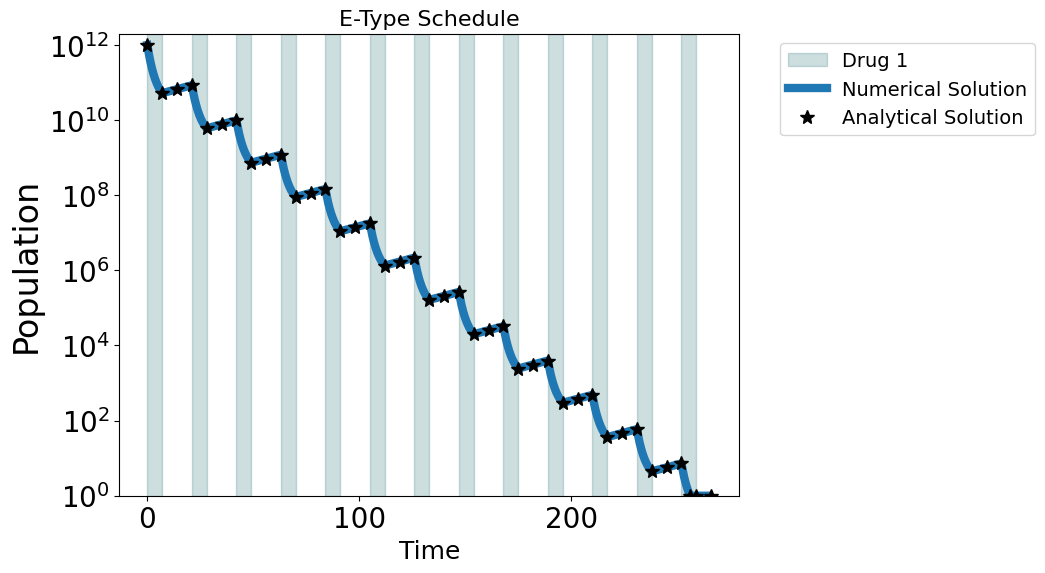

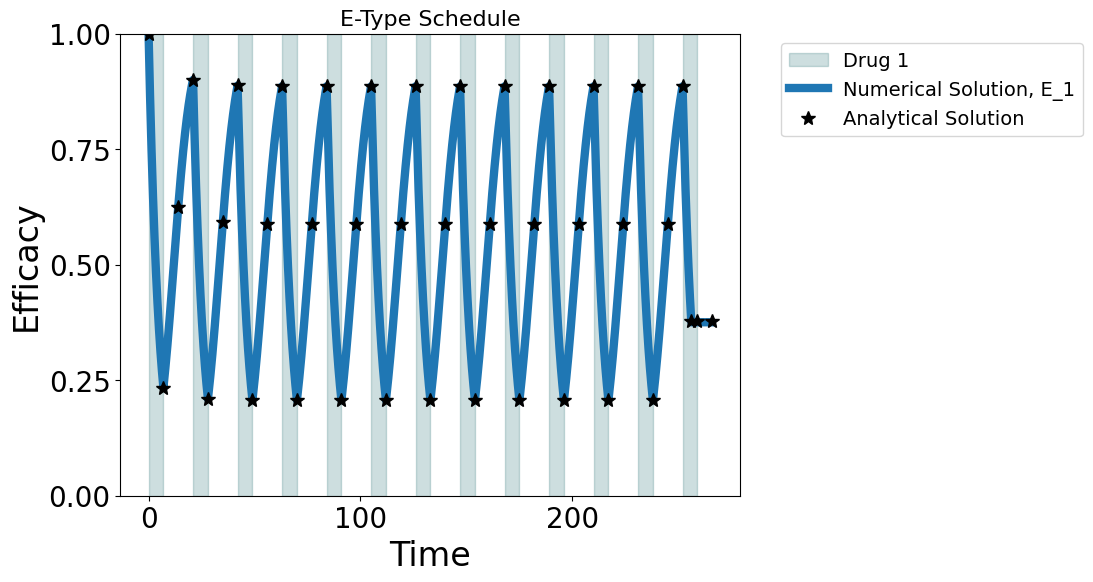

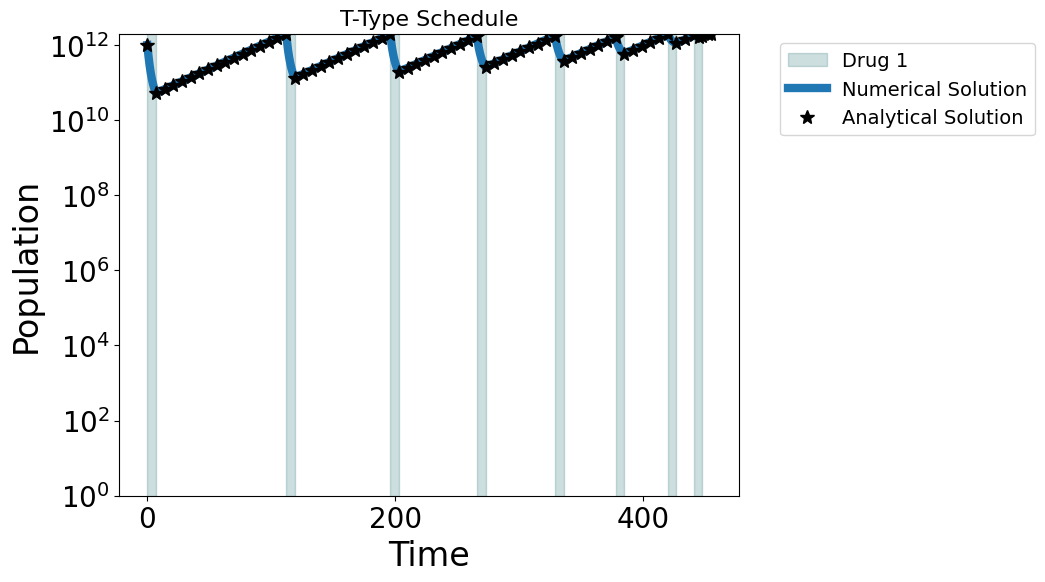

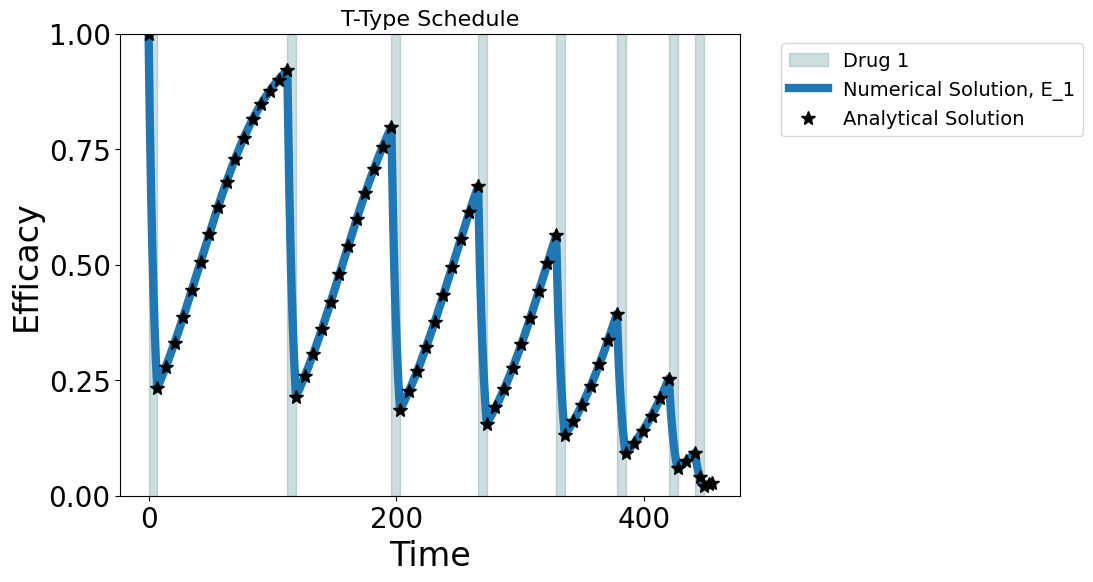

In [3]:
######## Continuous Dosing ##########
gamma = np.log(2)/20
deltamult = 30
rmult = 2
smult = 0
params = [gamma, [deltamult * gamma], [rmult * gamma], [smult * gamma]]
metric = 'CURE'
timepercycle = 7
ncycles = 10000
beta0 = 0.01
optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, beta0=beta0)
overalloptimalstrategy = SU.get_final_optimum(optimalstrategy,metric,params,timepercycle)

# plot the solution
fig = SU.full_sim(params,overalloptimalstrategy,timepercycle=timepercycle)
analyticalt,analyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],overalloptimalstrategy,timepercycle, *params)
plt.plot(analyticalt,[yy[0] for yy in analyticaly],'k*',markersize=10,label='Analytical Solution')
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Continuous Dosing Schedule',fontsize=16)
plt.ylim([1,2e12])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel('Population',fontsize=24)
plt.xlabel('Time',fontsize=24)
plt.show()

# plot the efficacy
fig = SU.full_sim_efficacy(params,overalloptimalstrategy,timepercycle=timepercycle)
plt.plot(analyticalt,[yy[1] for yy in analyticaly],'k*',markersize=10,label='Analytical Solution')
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Continuous Dosing Schedule',fontsize=16)
plt.ylim([0,1])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel('Efficacy',fontsize=24)
plt.xlabel('Time',fontsize=24)
plt.show()

######## E-type ##########
gamma = np.log(2)/20
deltamult = 25
rmult = 6
smult = 7
params = [gamma, [deltamult * gamma], [rmult * gamma], [smult * gamma]]
metric = 'CURE'
timepercycle = 7
ncycles = 10000
beta0 = 0.01
optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, beta0=beta0)
overalloptimalstrategy = SU.get_final_optimum(optimalstrategy,metric,params,timepercycle)

# plot the solution
fig = SU.full_sim(params,overalloptimalstrategy,timepercycle=timepercycle)
analyticalt,analyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],overalloptimalstrategy,timepercycle, *params)
plt.plot(analyticalt,[yy[0] for yy in analyticaly],'k*',markersize=10,label='Analytical Solution')
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('E-Type Schedule',fontsize=16)
plt.ylim([1,2e12])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel('Population',fontsize=24)
plt.show()

# plot the efficacy
fig = SU.full_sim_efficacy(params,overalloptimalstrategy,timepercycle=timepercycle)
plt.plot(analyticalt,[yy[1] for yy in analyticaly],'k*',markersize=10,label='Analytical Solution')
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('E-Type Schedule',fontsize=16)
plt.ylim([0,1])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel('Efficacy',fontsize=24)
plt.xlabel('Time',fontsize=24)
plt.show()

######## T-type ##########
gamma = np.log(2)/20
deltamult = 25
rmult = 6
smult = 1
params = [gamma, [deltamult * gamma], [rmult * gamma], [smult * gamma]]
metric = 'PFS'
timepercycle = 7
ncycles = 10000
beta0 = 0.01
optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, beta0=beta0)
overalloptimalstrategy = SU.get_final_optimum(optimalstrategy,metric,params,timepercycle)

# plot the solution
fig = SU.full_sim(params,overalloptimalstrategy,timepercycle=timepercycle)
analyticalt,analyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],overalloptimalstrategy,timepercycle, *params)
plt.plot(analyticalt,[yy[0] for yy in analyticaly],'k*',markersize=10,label='Analytical Solution')
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('T-Type Schedule',fontsize=16)
plt.ylim([1,2e12])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel('Population',fontsize=24)
plt.xlabel('Time',fontsize=24)
plt.show()

# plot the efficacy
fig = SU.full_sim_efficacy(params,overalloptimalstrategy,timepercycle=timepercycle)
plt.plot(analyticalt,[yy[1] for yy in analyticaly],'k*',markersize=10,label='Analytical Solution')
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('T-Type Schedule',fontsize=16)
plt.ylim([0,1])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel('Efficacy',fontsize=24)
plt.xlabel('Time',fontsize=24)
plt.show()

## Fig 3. CURE Phase space for one drug optimal schedules

In [4]:
# Do the phase space calculation with the simulated annealing algorithm

# first make all possible param values
gamma = np.log(2) / 20
delta = 50 * gamma
rmin = 5 * gamma 
rmax = 15 * gamma
smin = 0 
smax = 3 * gamma
linsamplenr = 9
linsamplens = 3
nwindows = 16
timepercycle = 7
rvals = [rmin + kk * (rmax - rmin) / linsamplenr for kk in range(linsamplenr+1)]
svals = [smin + kk * (smax - smin) / linsamplens for kk in range(linsamplens+1)]
phasespace = [[gamma, [delta], [rr], [ss]] for rr in rvals for ss in svals]
rvalsX = [ps[2][0] / ps[0] for ps in phasespace]
svalsY = [ps[3][0] / ps[0] for ps in phasespace]

# set up other parameters and stuff for the loop
metric = 'CURE' 
storage = []
storageE = []
storagereport = []
ncycles = 10000

# additional variables
curethresh = 1
progthresh = 2e12
print('Searching {} points in phase space'.format(len(phasespace)))

# time it
start_time = time.time()

for psindx,params in enumerate(phasespace):
    strategystart = None  
    optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, strategystart=strategystart)
    overalloptimalstrategy,report = SU.get_final_optimum(optimalstrategy,metric,params,timepercycle,reporting=True)
    storage.append(overalloptimalstrategy)
    storageE.append(energies)
    storagereport.append(report)

end_time = time.time()
print('Done!')
elapsed_time = end_time - start_time
print("Elapsed time: {:.4f} seconds, {:.4f} seconds per parameter set".format(elapsed_time,elapsed_time / len(phasespace)))

# store all the cure schedules to use as the starting point for the PFS run
if metric == 'CURE':
    curestorage = copy.deepcopy(storage)
    

Searching 40 points in phase space
Done!
Elapsed time: 205.7648 seconds, 5.1441 seconds per parameter set


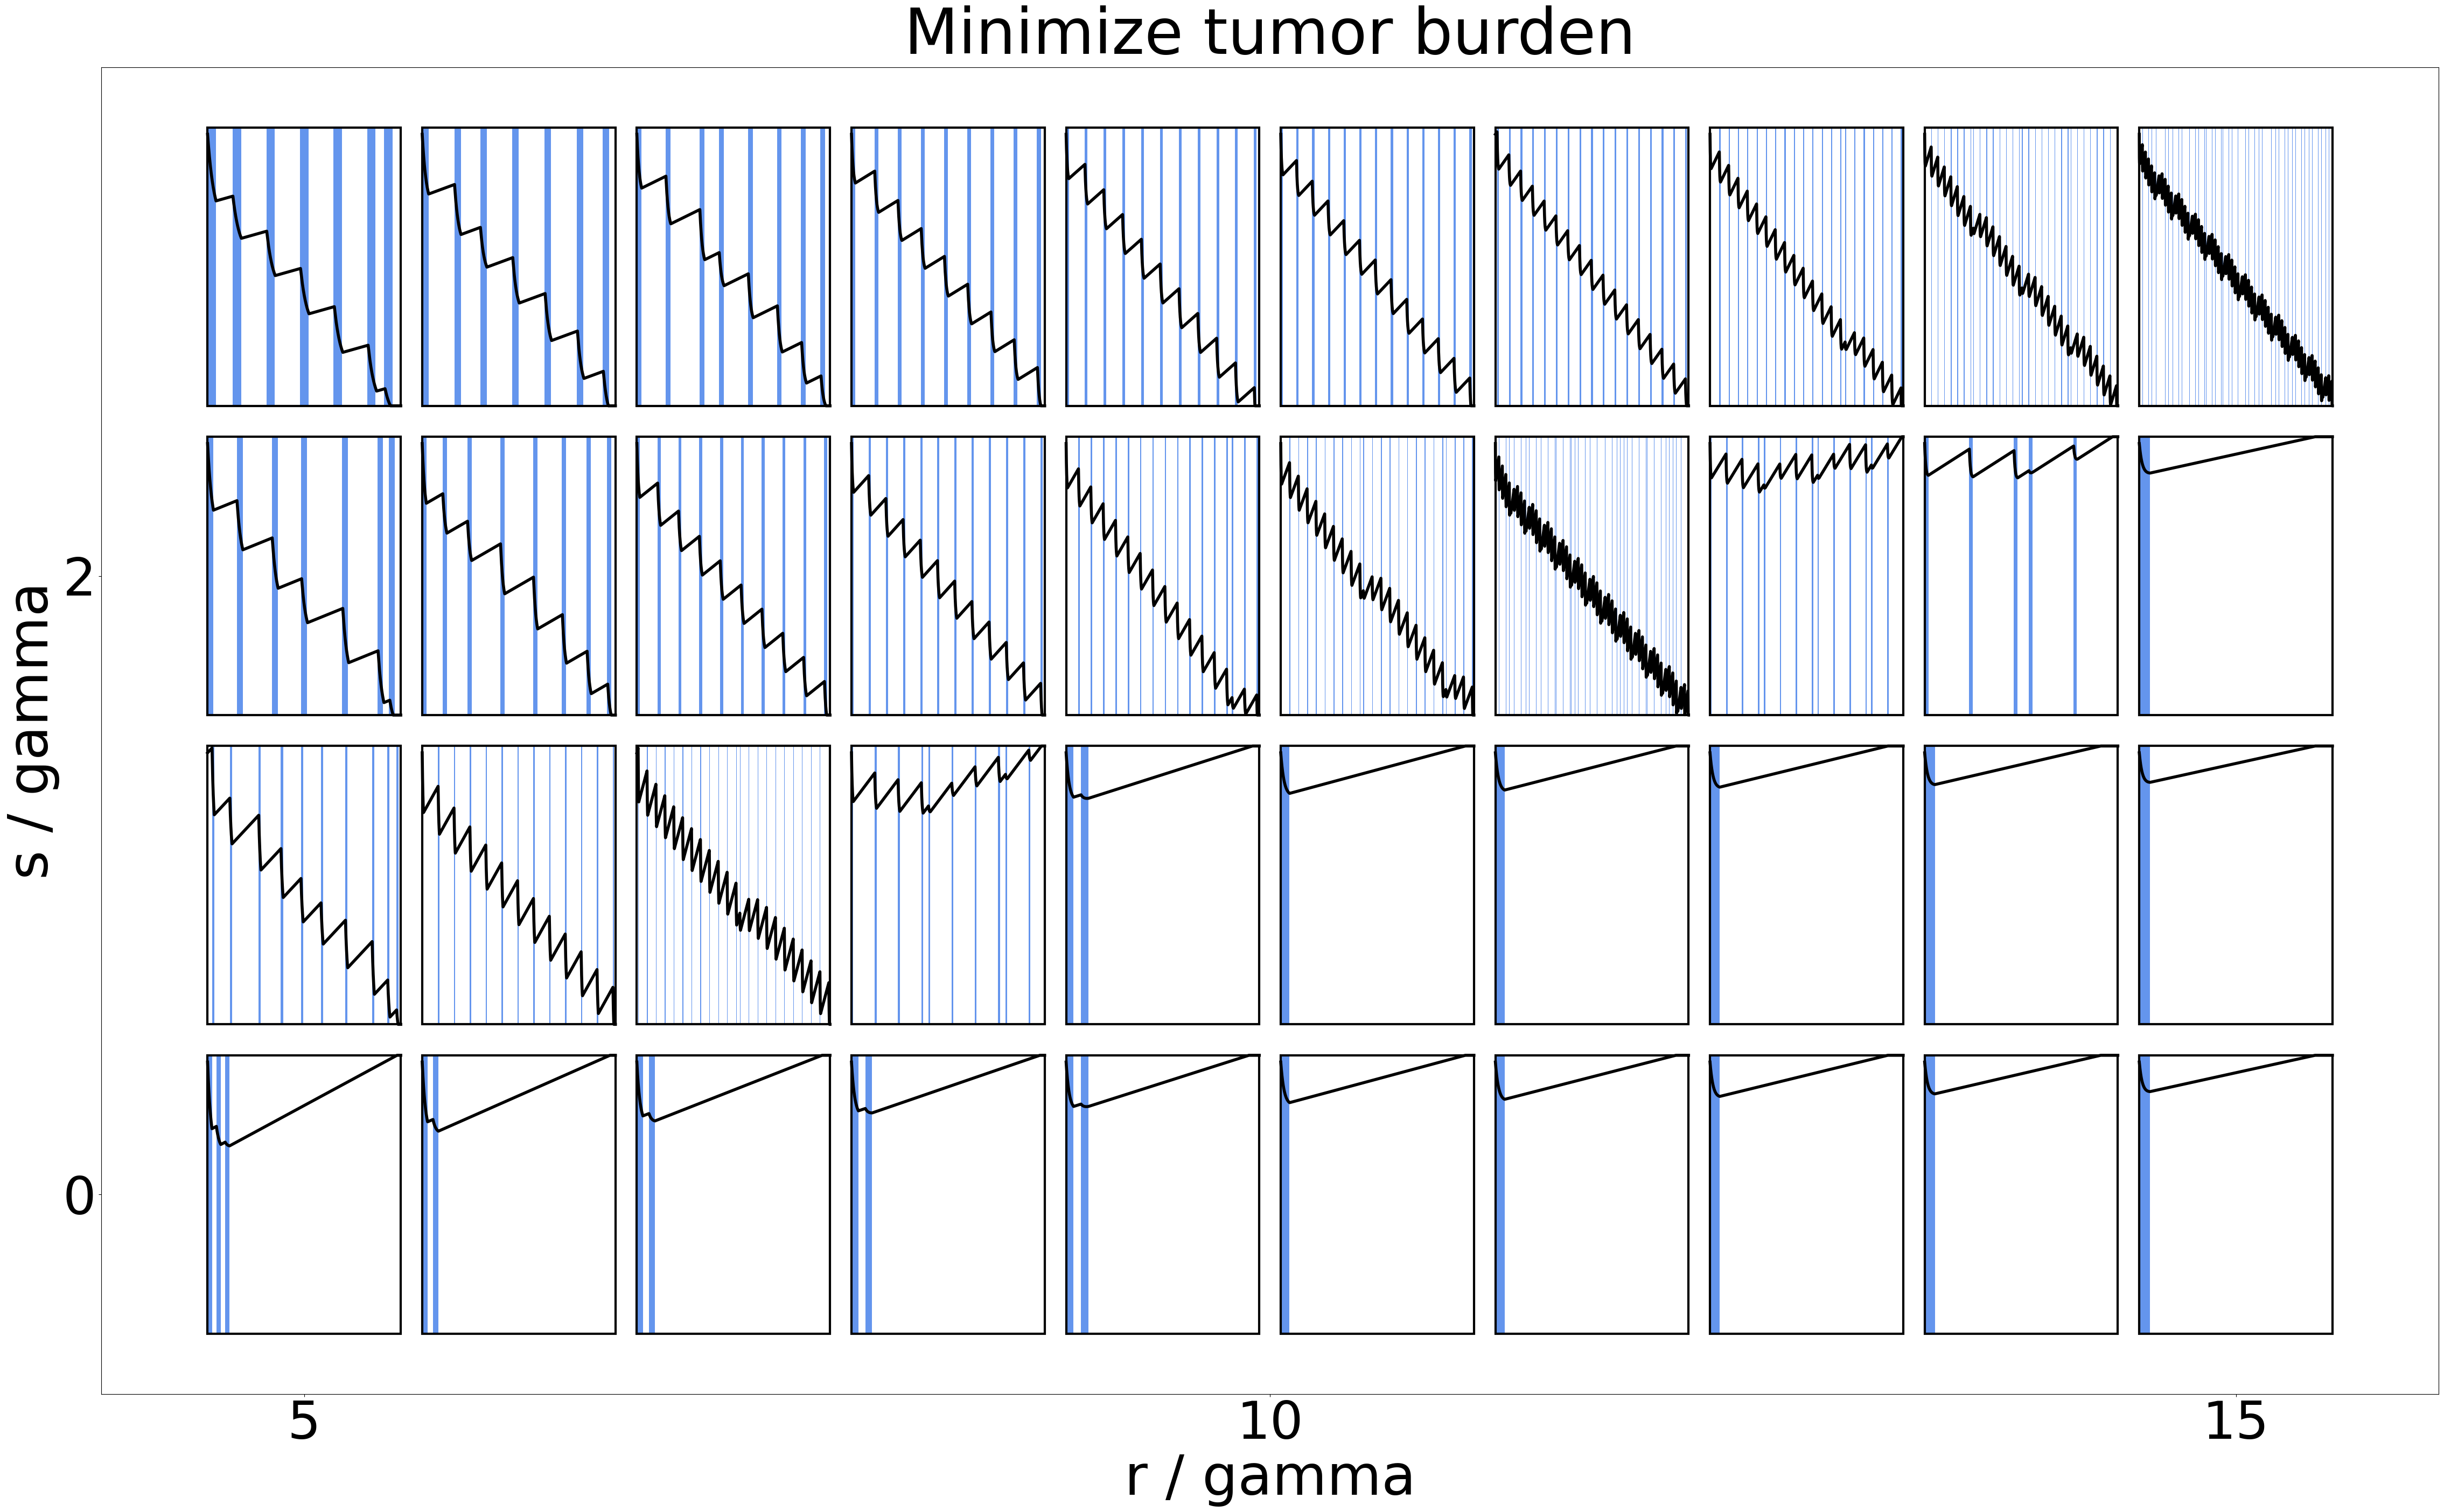

/Users/kocherc/Documents/GitHub/code/python/optimal-drug-switching/code-for-paper/schedule_utils.py:1474: RuntimeWarning: divide by zero encountered in scalar divide
  fxntoeval = lambda x: gamma * dt1 + delta * x / rr * (np.exp(-rr * dt1) - 1) + gamma / ss * np.log((1 - x * np.exp(-rr * dt1)) / ((1 - x) * np.exp(-rr * dt1)))


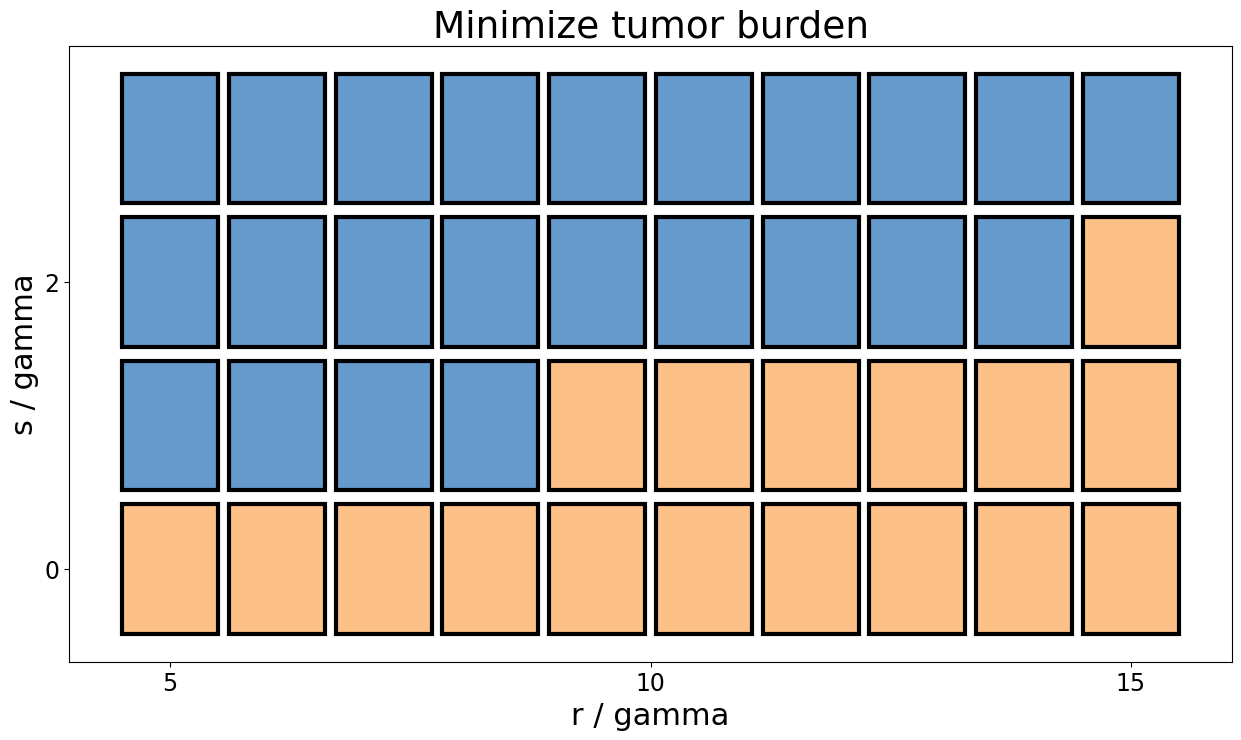

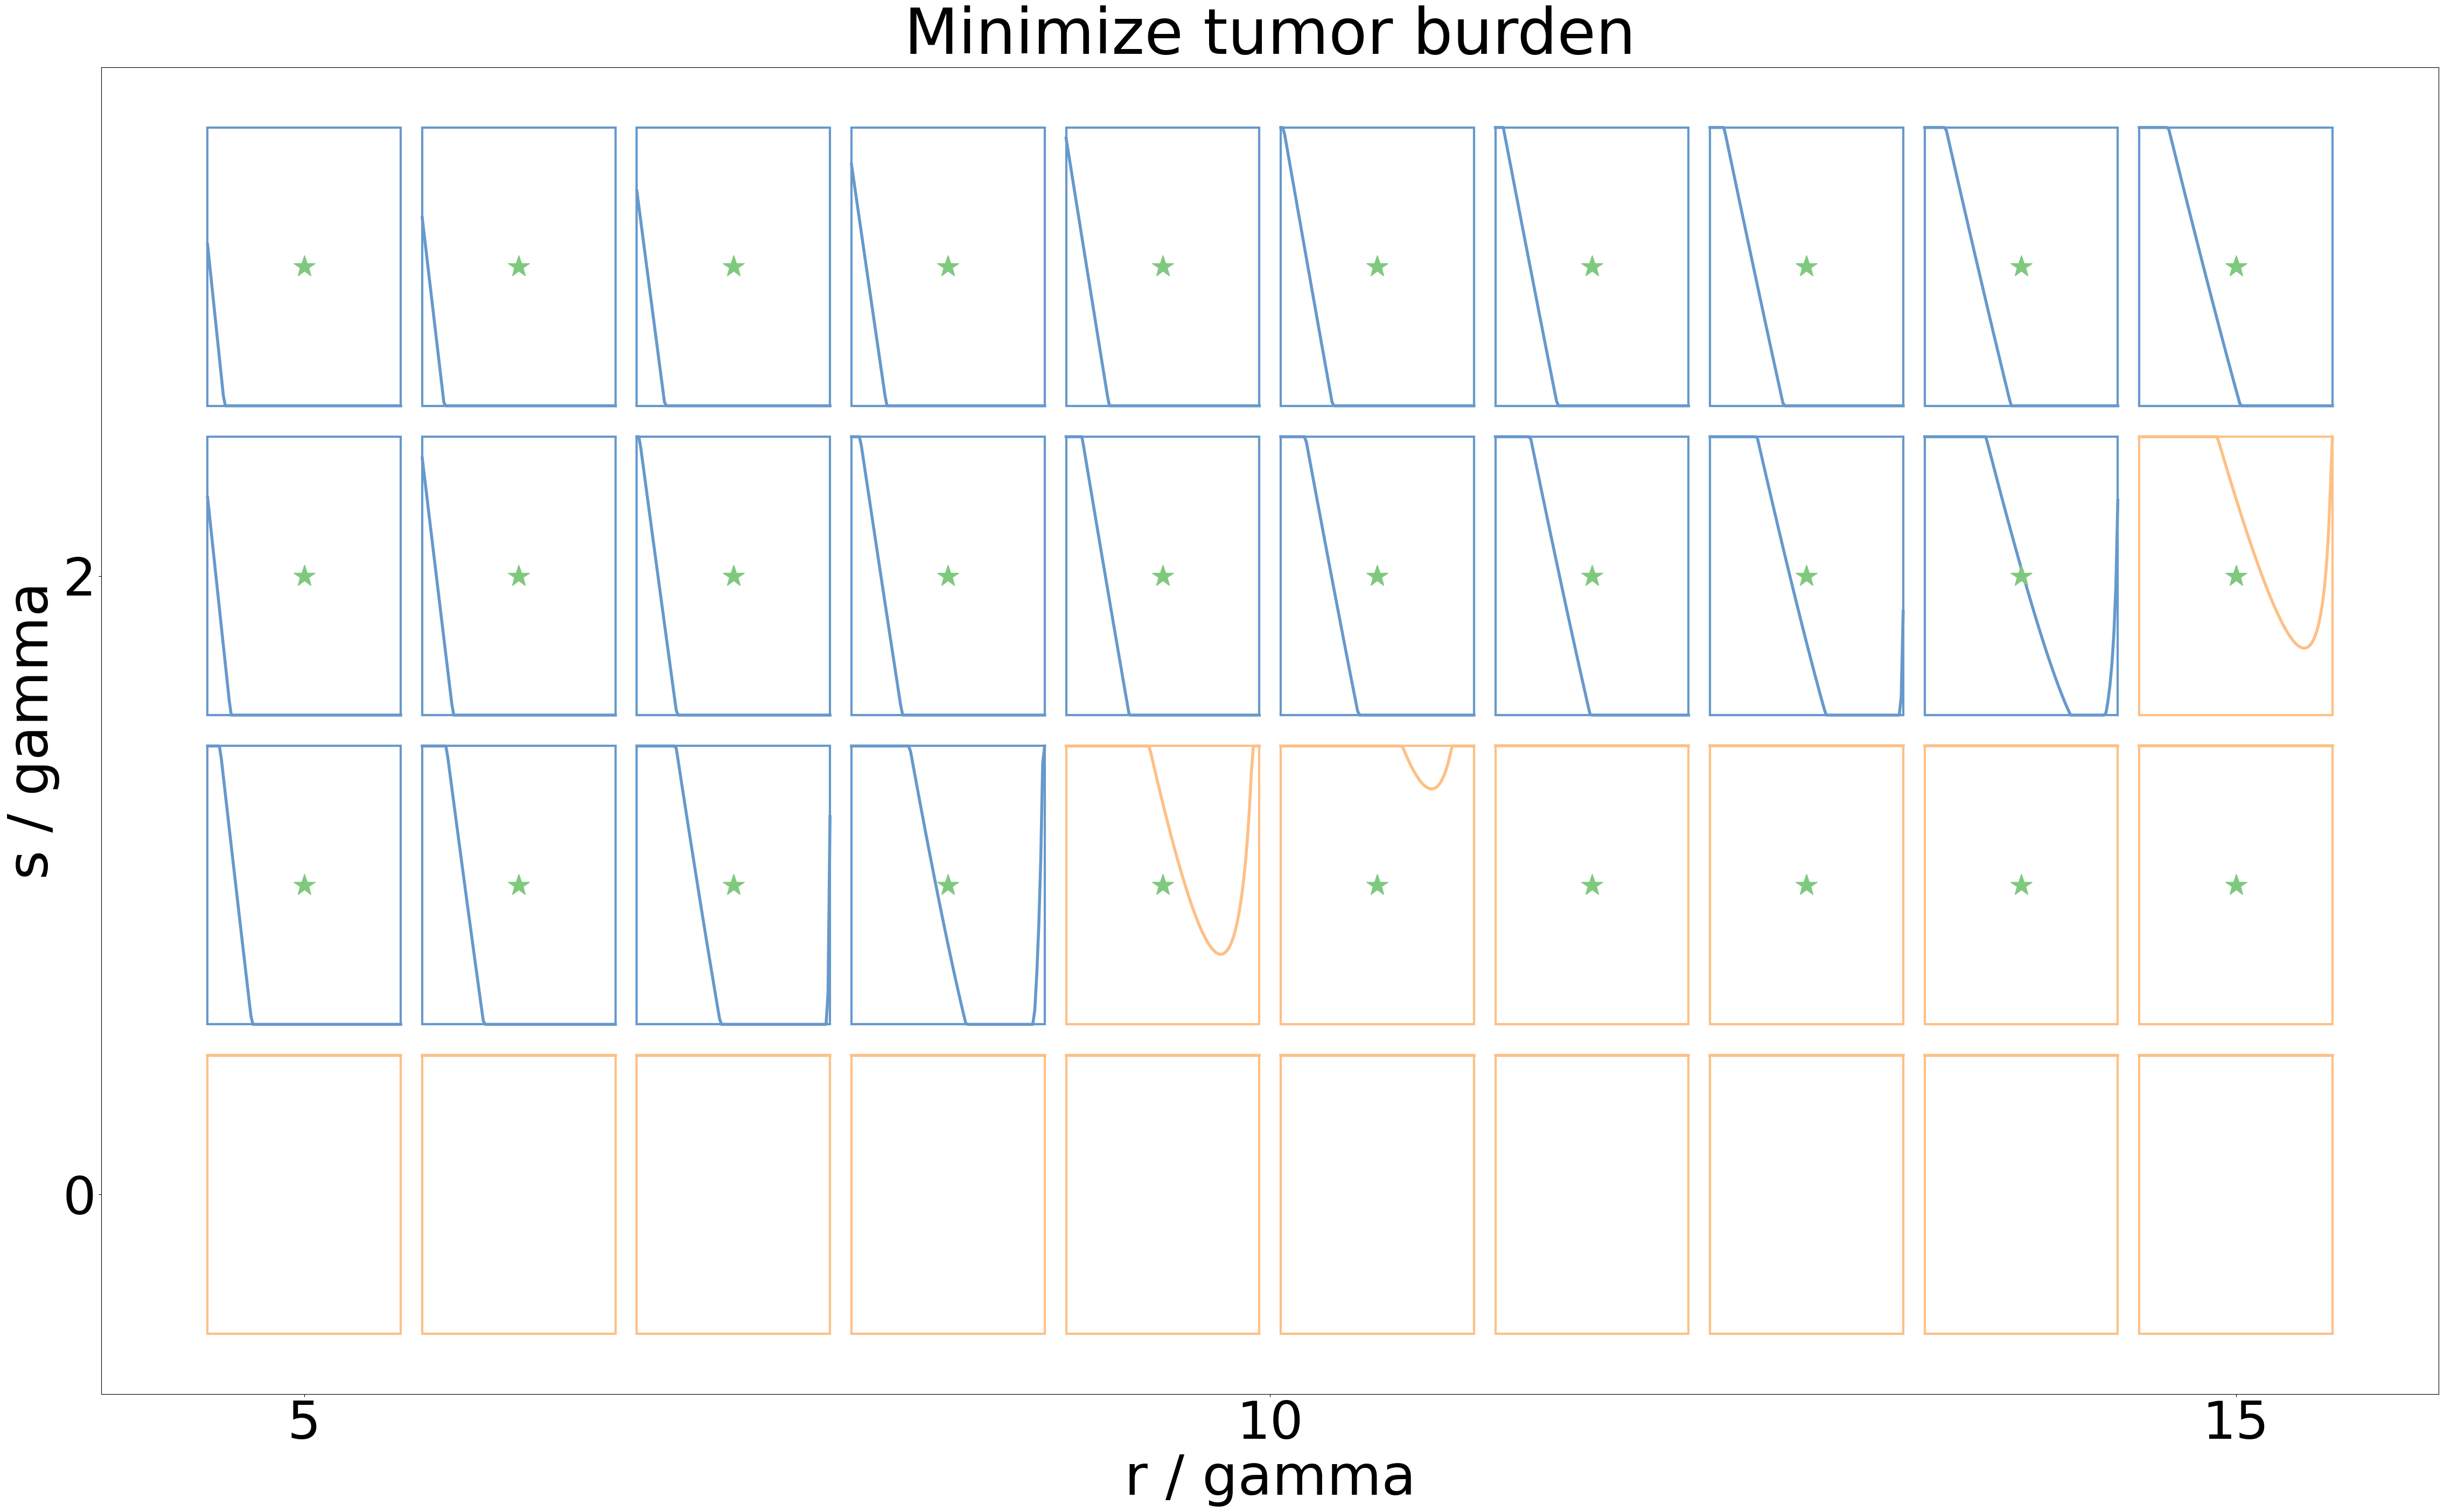

In [5]:
SU.plotphasediagram(storage,phasespace,storagereport,timepercycle,rvals,svals,rvalsX,svalsY,gamma,delta,metric)

## Fig 3. PFS phase space for 1 drug optimal schedules

In [6]:
# there can be a bit of stochasticity around the T/E phase boundary because of the variance of the simulated annealing algorithm. 
np.random.seed(9) # set the seed so you get the figures from the paper

# Do the phase space calculation with the simulated annealing algorithm

# first make all possible param values
gamma = np.log(2) / 20
delta = 50 * gamma
rmin = 5 * gamma 
rmax = 15 * gamma
smin = 0 
smax = 3 * gamma
linsamplenr = 9
linsamplens = 3
nwindows = 16
timepercycle = 7
rvals = [rmin + kk * (rmax - rmin) / linsamplenr for kk in range(linsamplenr+1)]
svals = [smin + kk * (smax - smin) / linsamplens for kk in range(linsamplens+1)]
phasespace = [[gamma, [delta], [rr], [ss]] for rr in rvals for ss in svals]
rvalsX = [ps[2][0] / ps[0] for ps in phasespace]
svalsY = [ps[3][0] / ps[0] for ps in phasespace]

# set up other parameters and stuff for the loop
metric = 'PFS' 
storage = []
storageE = []
storagereport = []
ncycles = 10000

# additional variables
curethresh = 1
progthresh = 2e12
print('Searching {} points in phase space'.format(len(phasespace)))

# time it
start_time = time.time()

for psindx,params in enumerate(phasespace):
    strategystart = None
    if metric == 'PFS' and 'curestorage' in locals():
        strategystart = curestorage[psindx]
        
    optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, strategystart=strategystart)
    overalloptimalstrategy,report = SU.get_final_optimum(optimalstrategy,metric,params,timepercycle,reporting=True)
    storage.append(overalloptimalstrategy)
    storageE.append(energies)
    storagereport.append(report)

end_time = time.time()
print('Done!')
elapsed_time = end_time - start_time
print("Elapsed time: {:.4f} seconds, {:.4f} seconds per parameter set".format(elapsed_time,elapsed_time / len(phasespace)))

# store all the cure schedules to use as the starting point for the PFS run
if metric == 'CURE':
    curestorage = copy.deepcopy(storage)
    

Searching 40 points in phase space
Done!
Elapsed time: 180.4847 seconds, 4.5121 seconds per parameter set


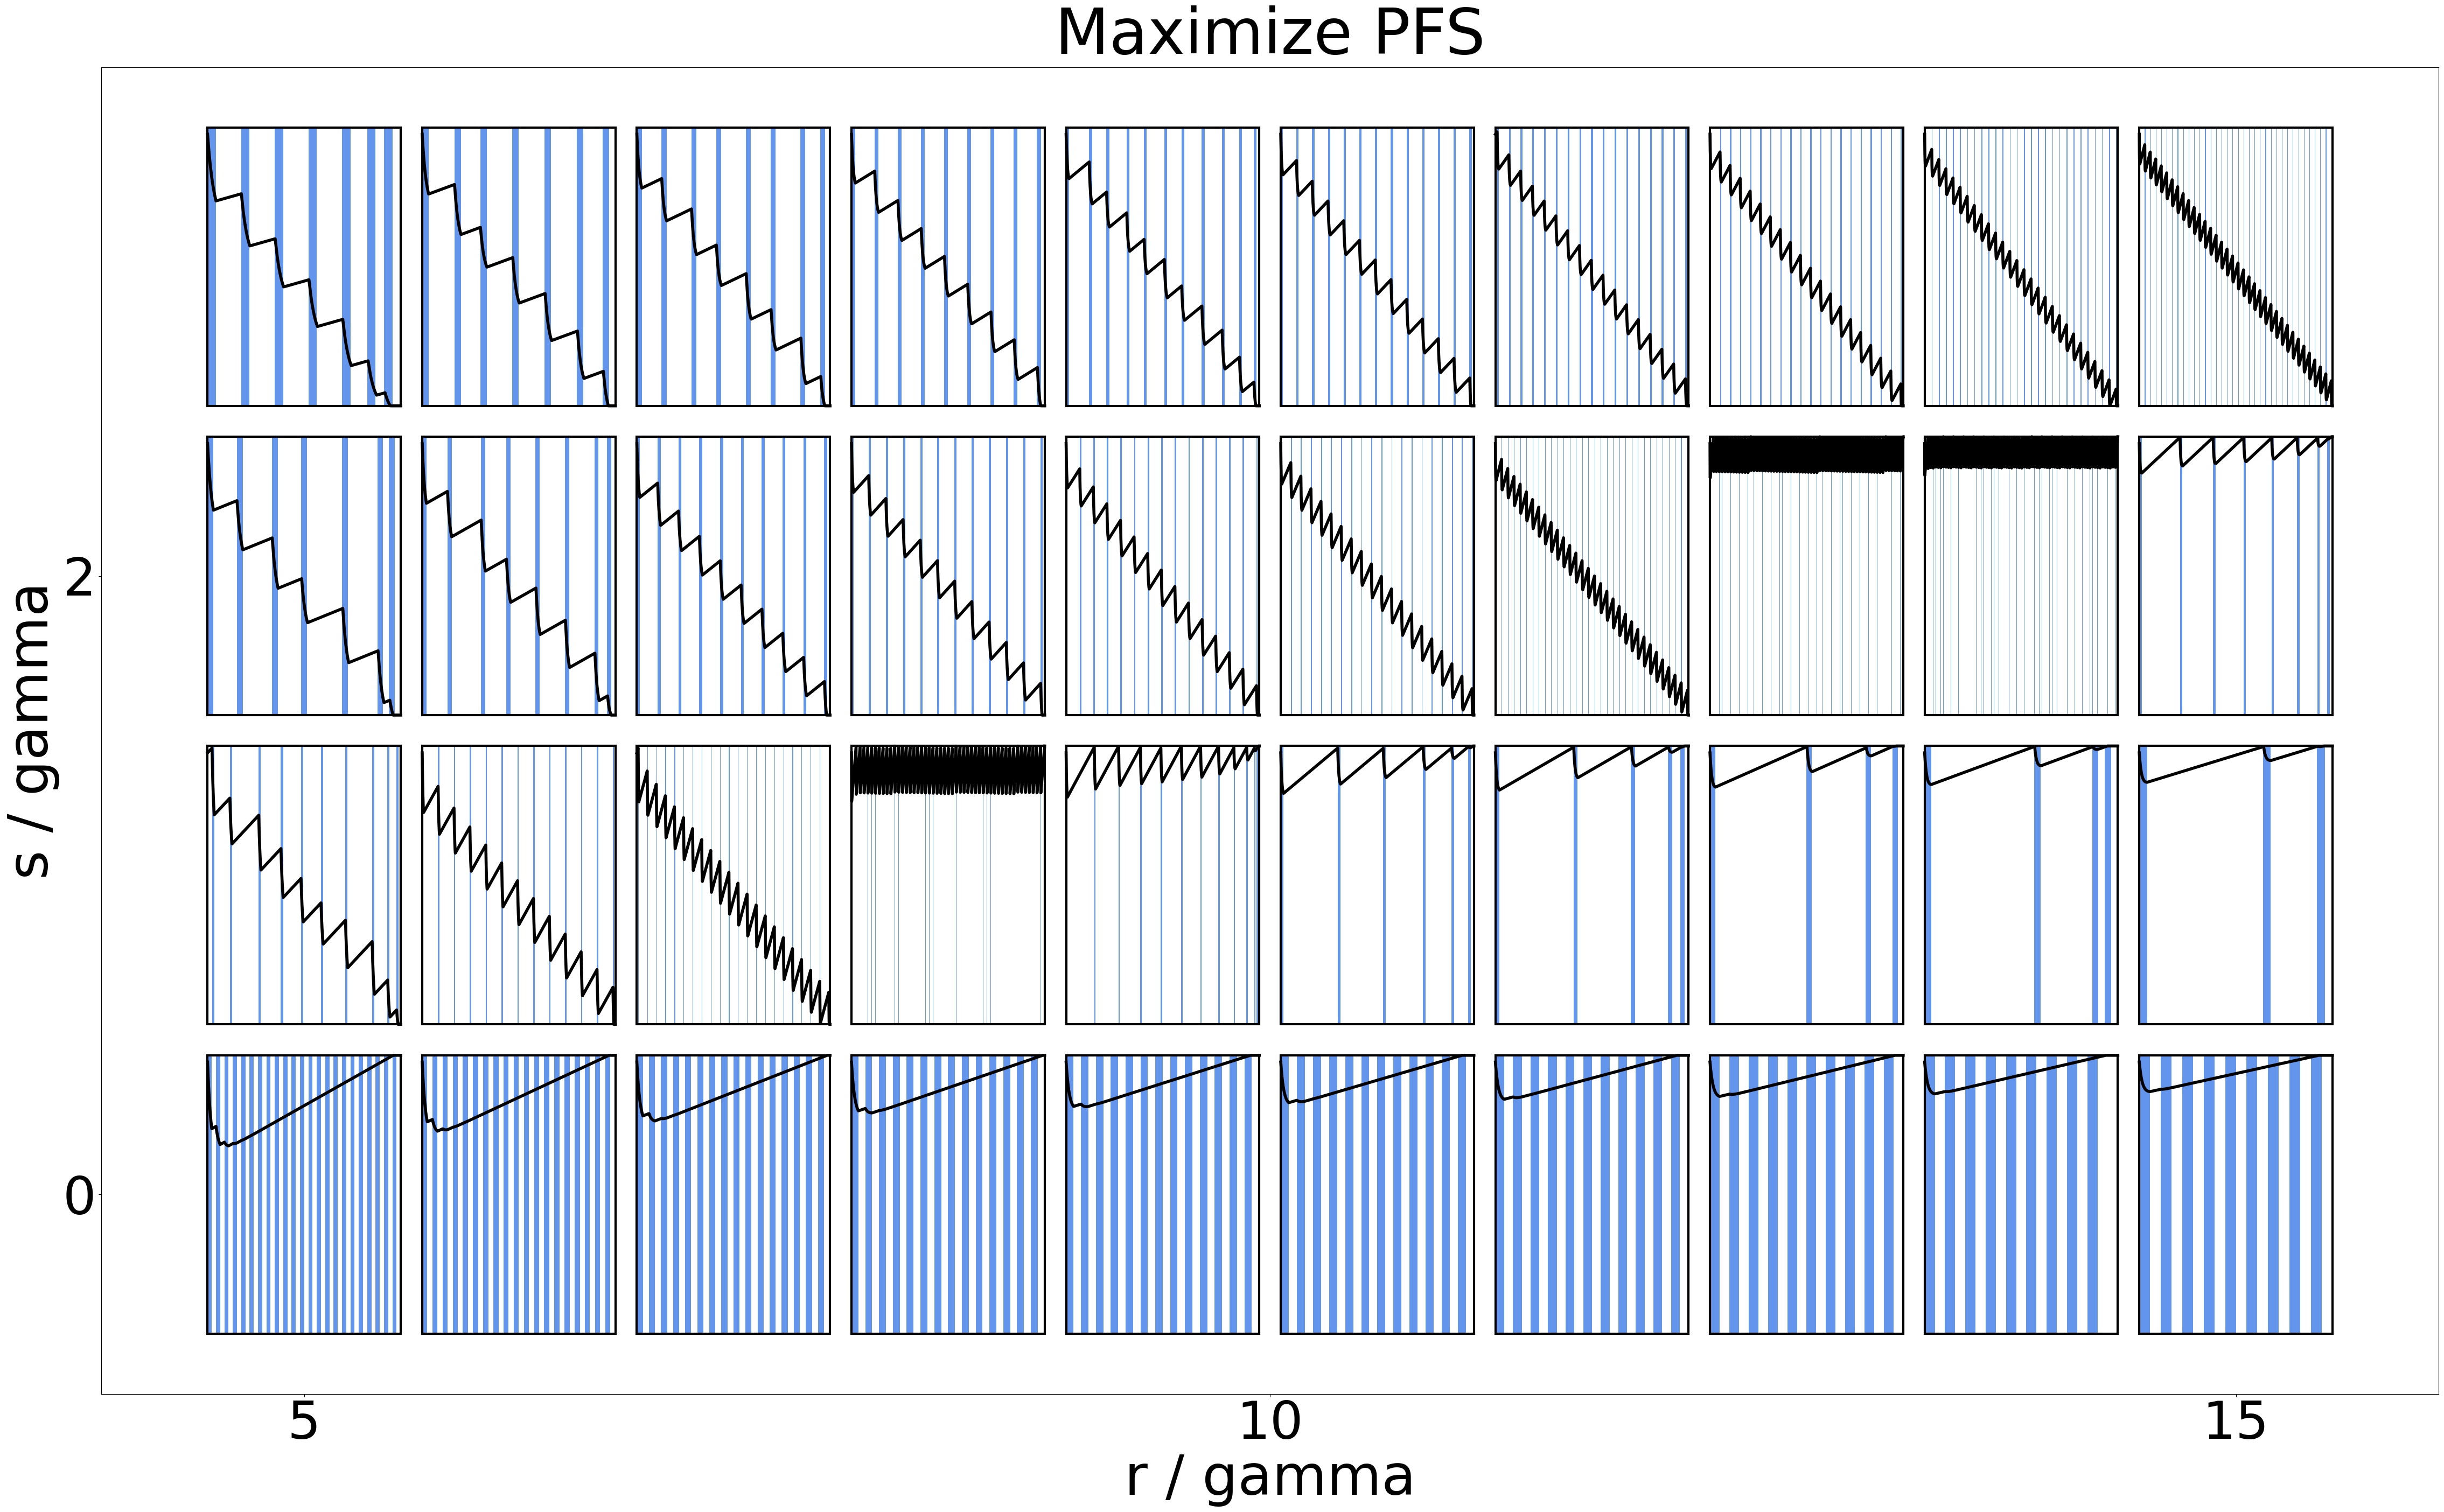

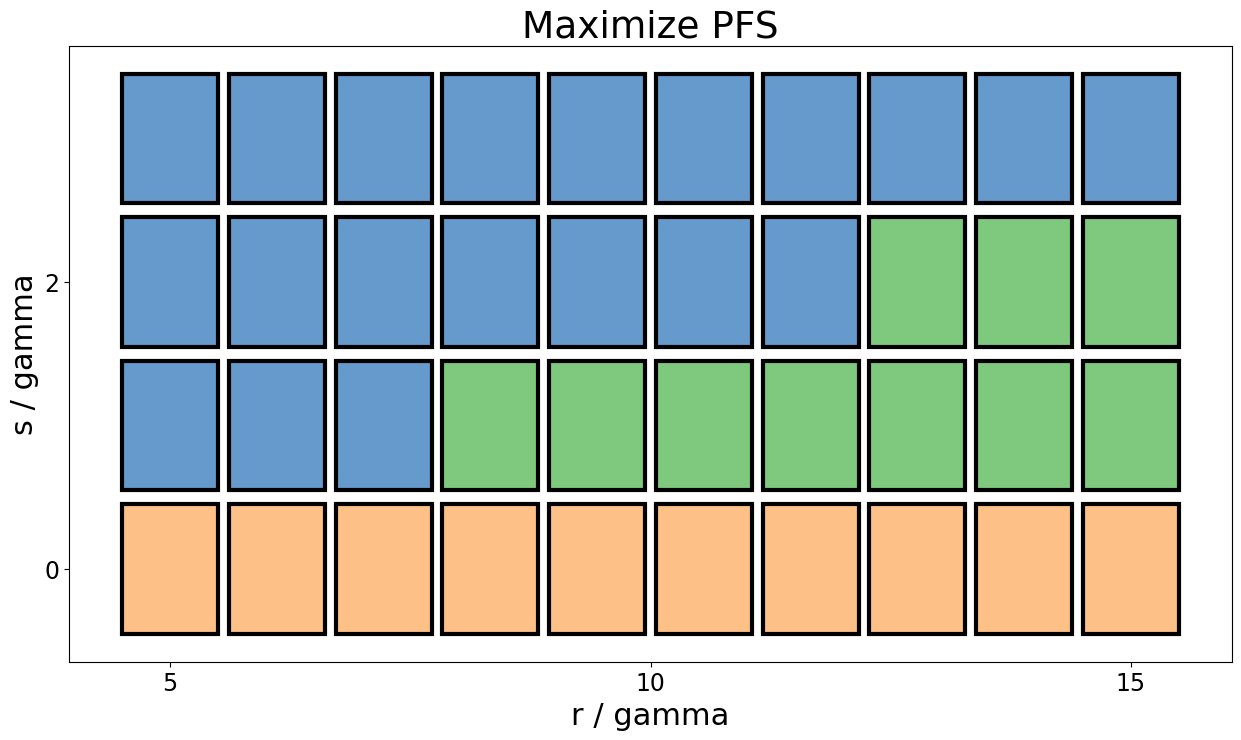

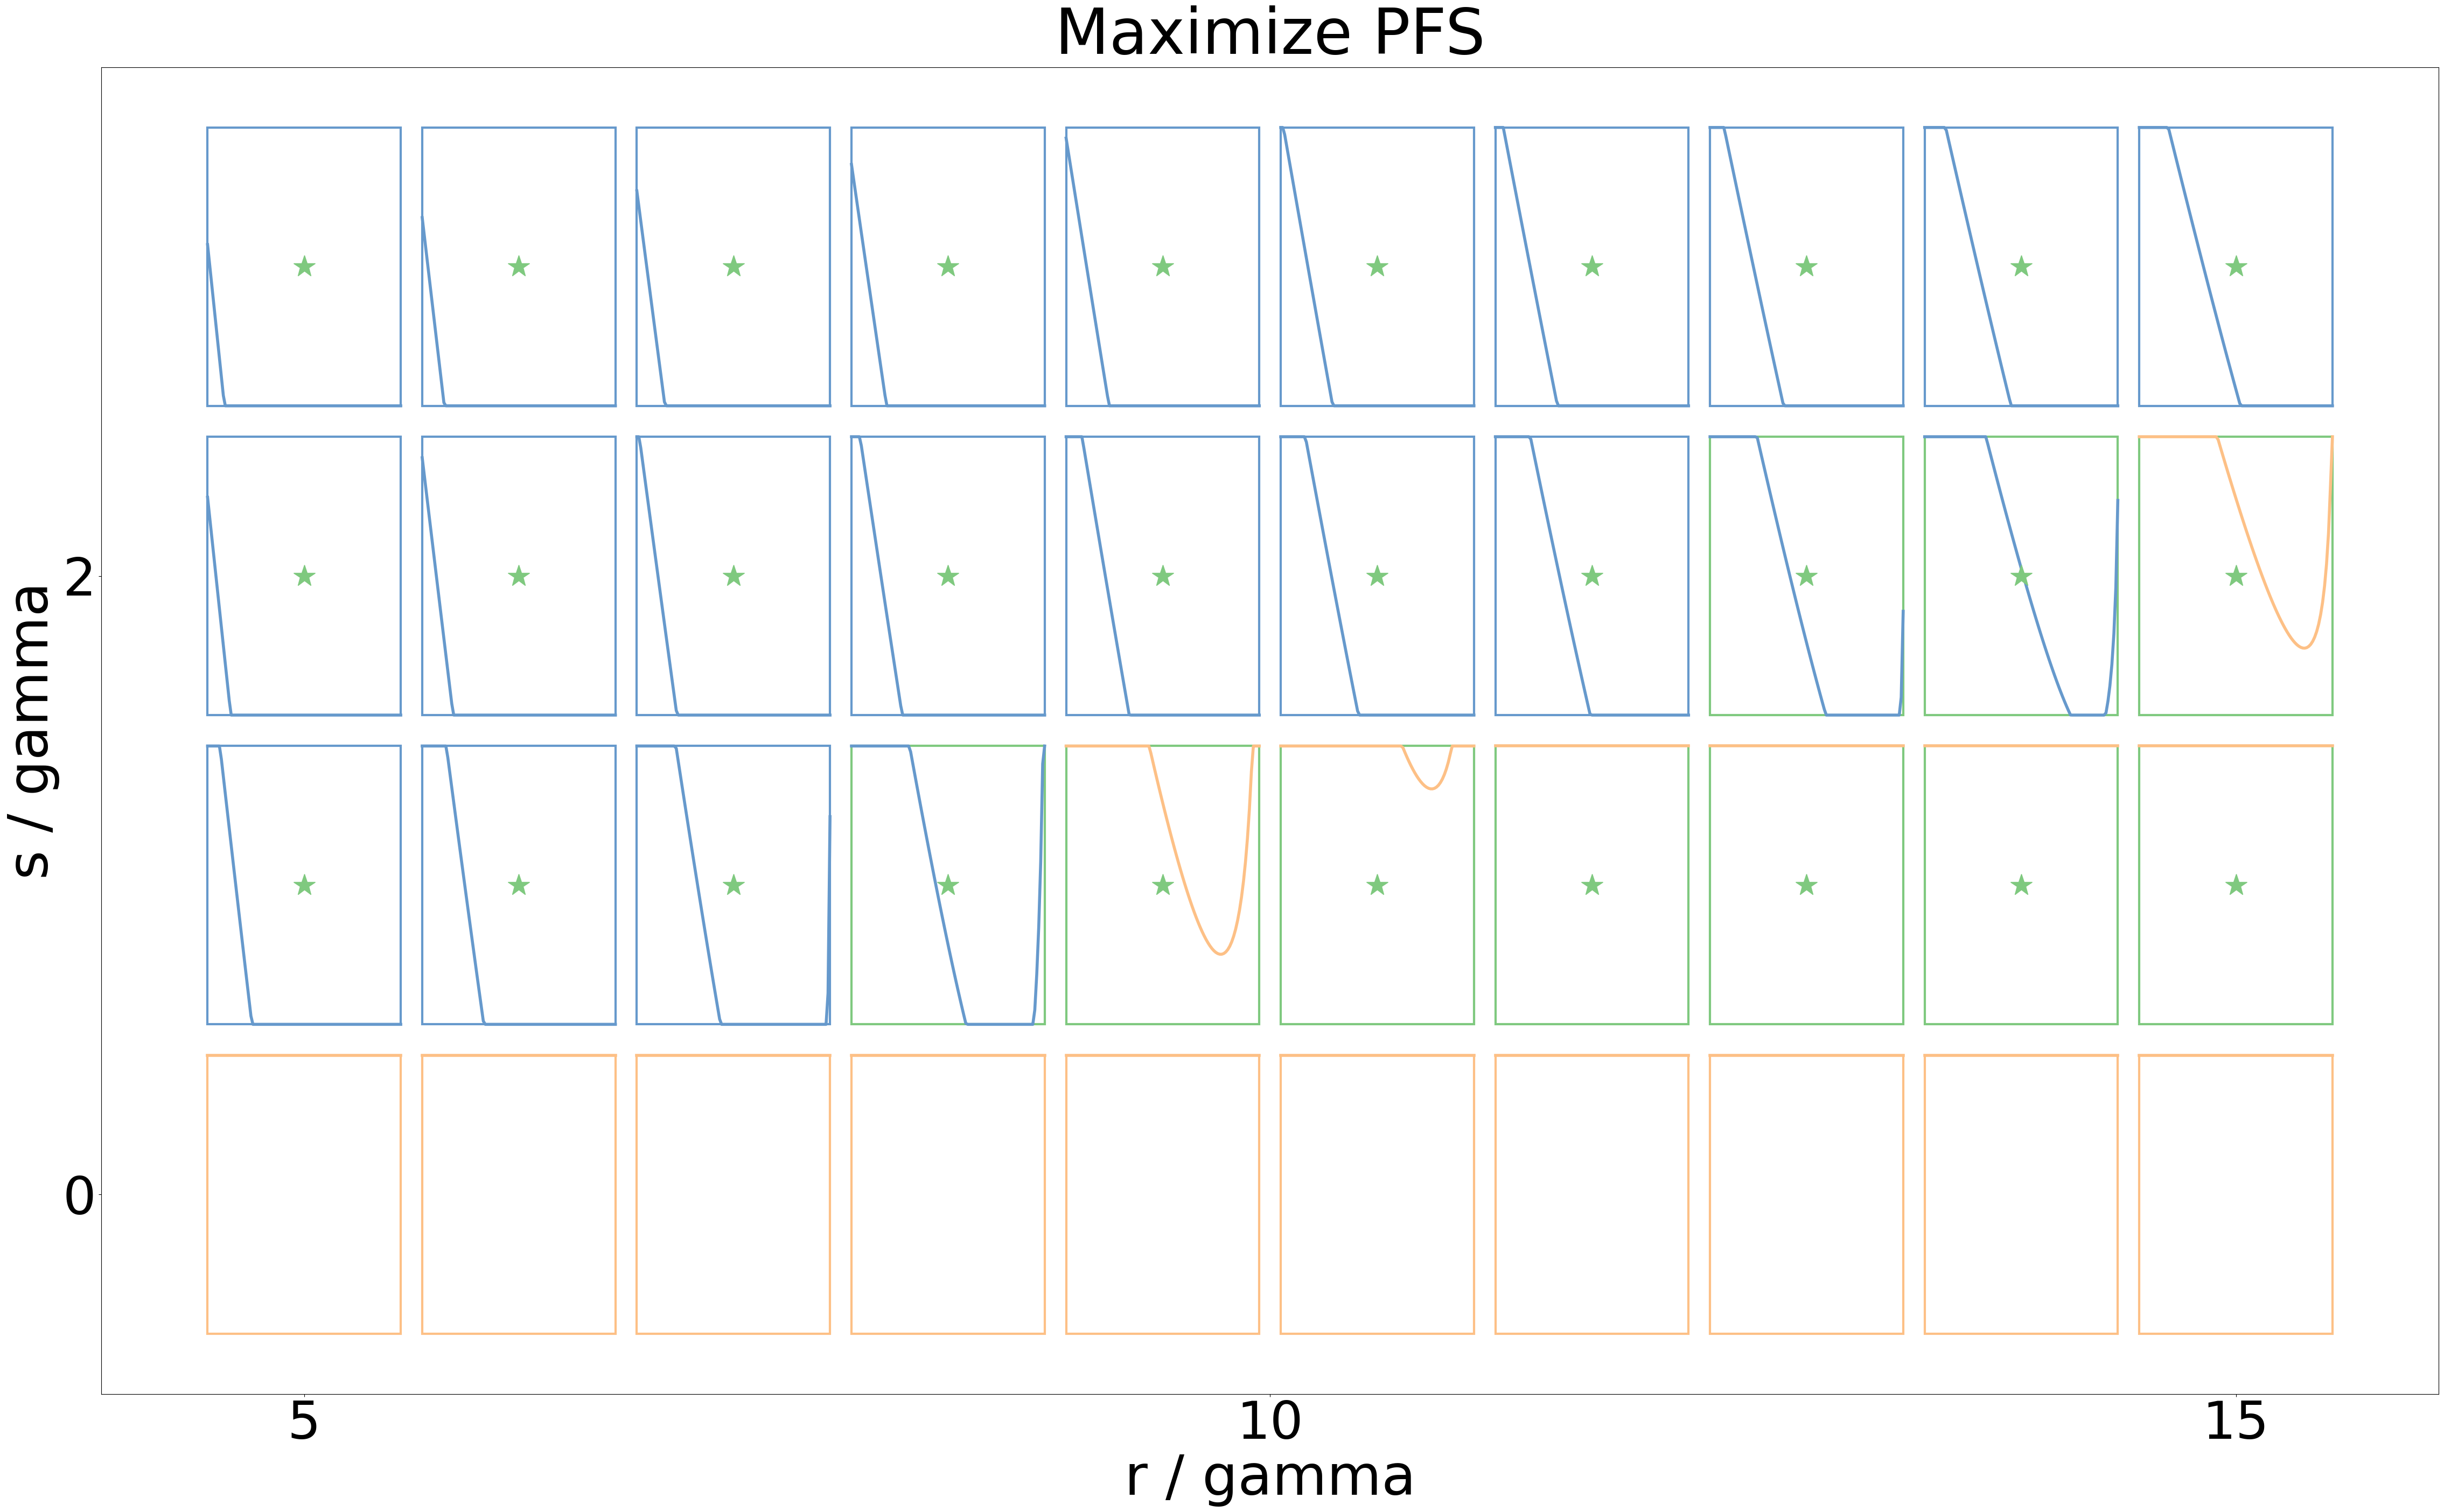

In [7]:
SU.plotphasediagram(storage,phasespace,storagereport,timepercycle,rvals,svals,rvalsX,svalsY,gamma,delta,metric)

## Fig S7. Putting the phase boundary from infinitesimal cycling on the previous phase diagram.

/Users/kocherc/Documents/GitHub/code/python/optimal-drug-switching/code-for-paper/schedule_utils.py:1638: RuntimeWarning: divide by zero encountered in scalar divide
  fxntoeval = lambda x: gamma * dt1 + delta * x / rr * (np.exp(-rr * dt1) - 1) + gamma / ss * np.log((1 - x * np.exp(-rr * dt1)) / ((1 - x) * np.exp(-rr * dt1)))


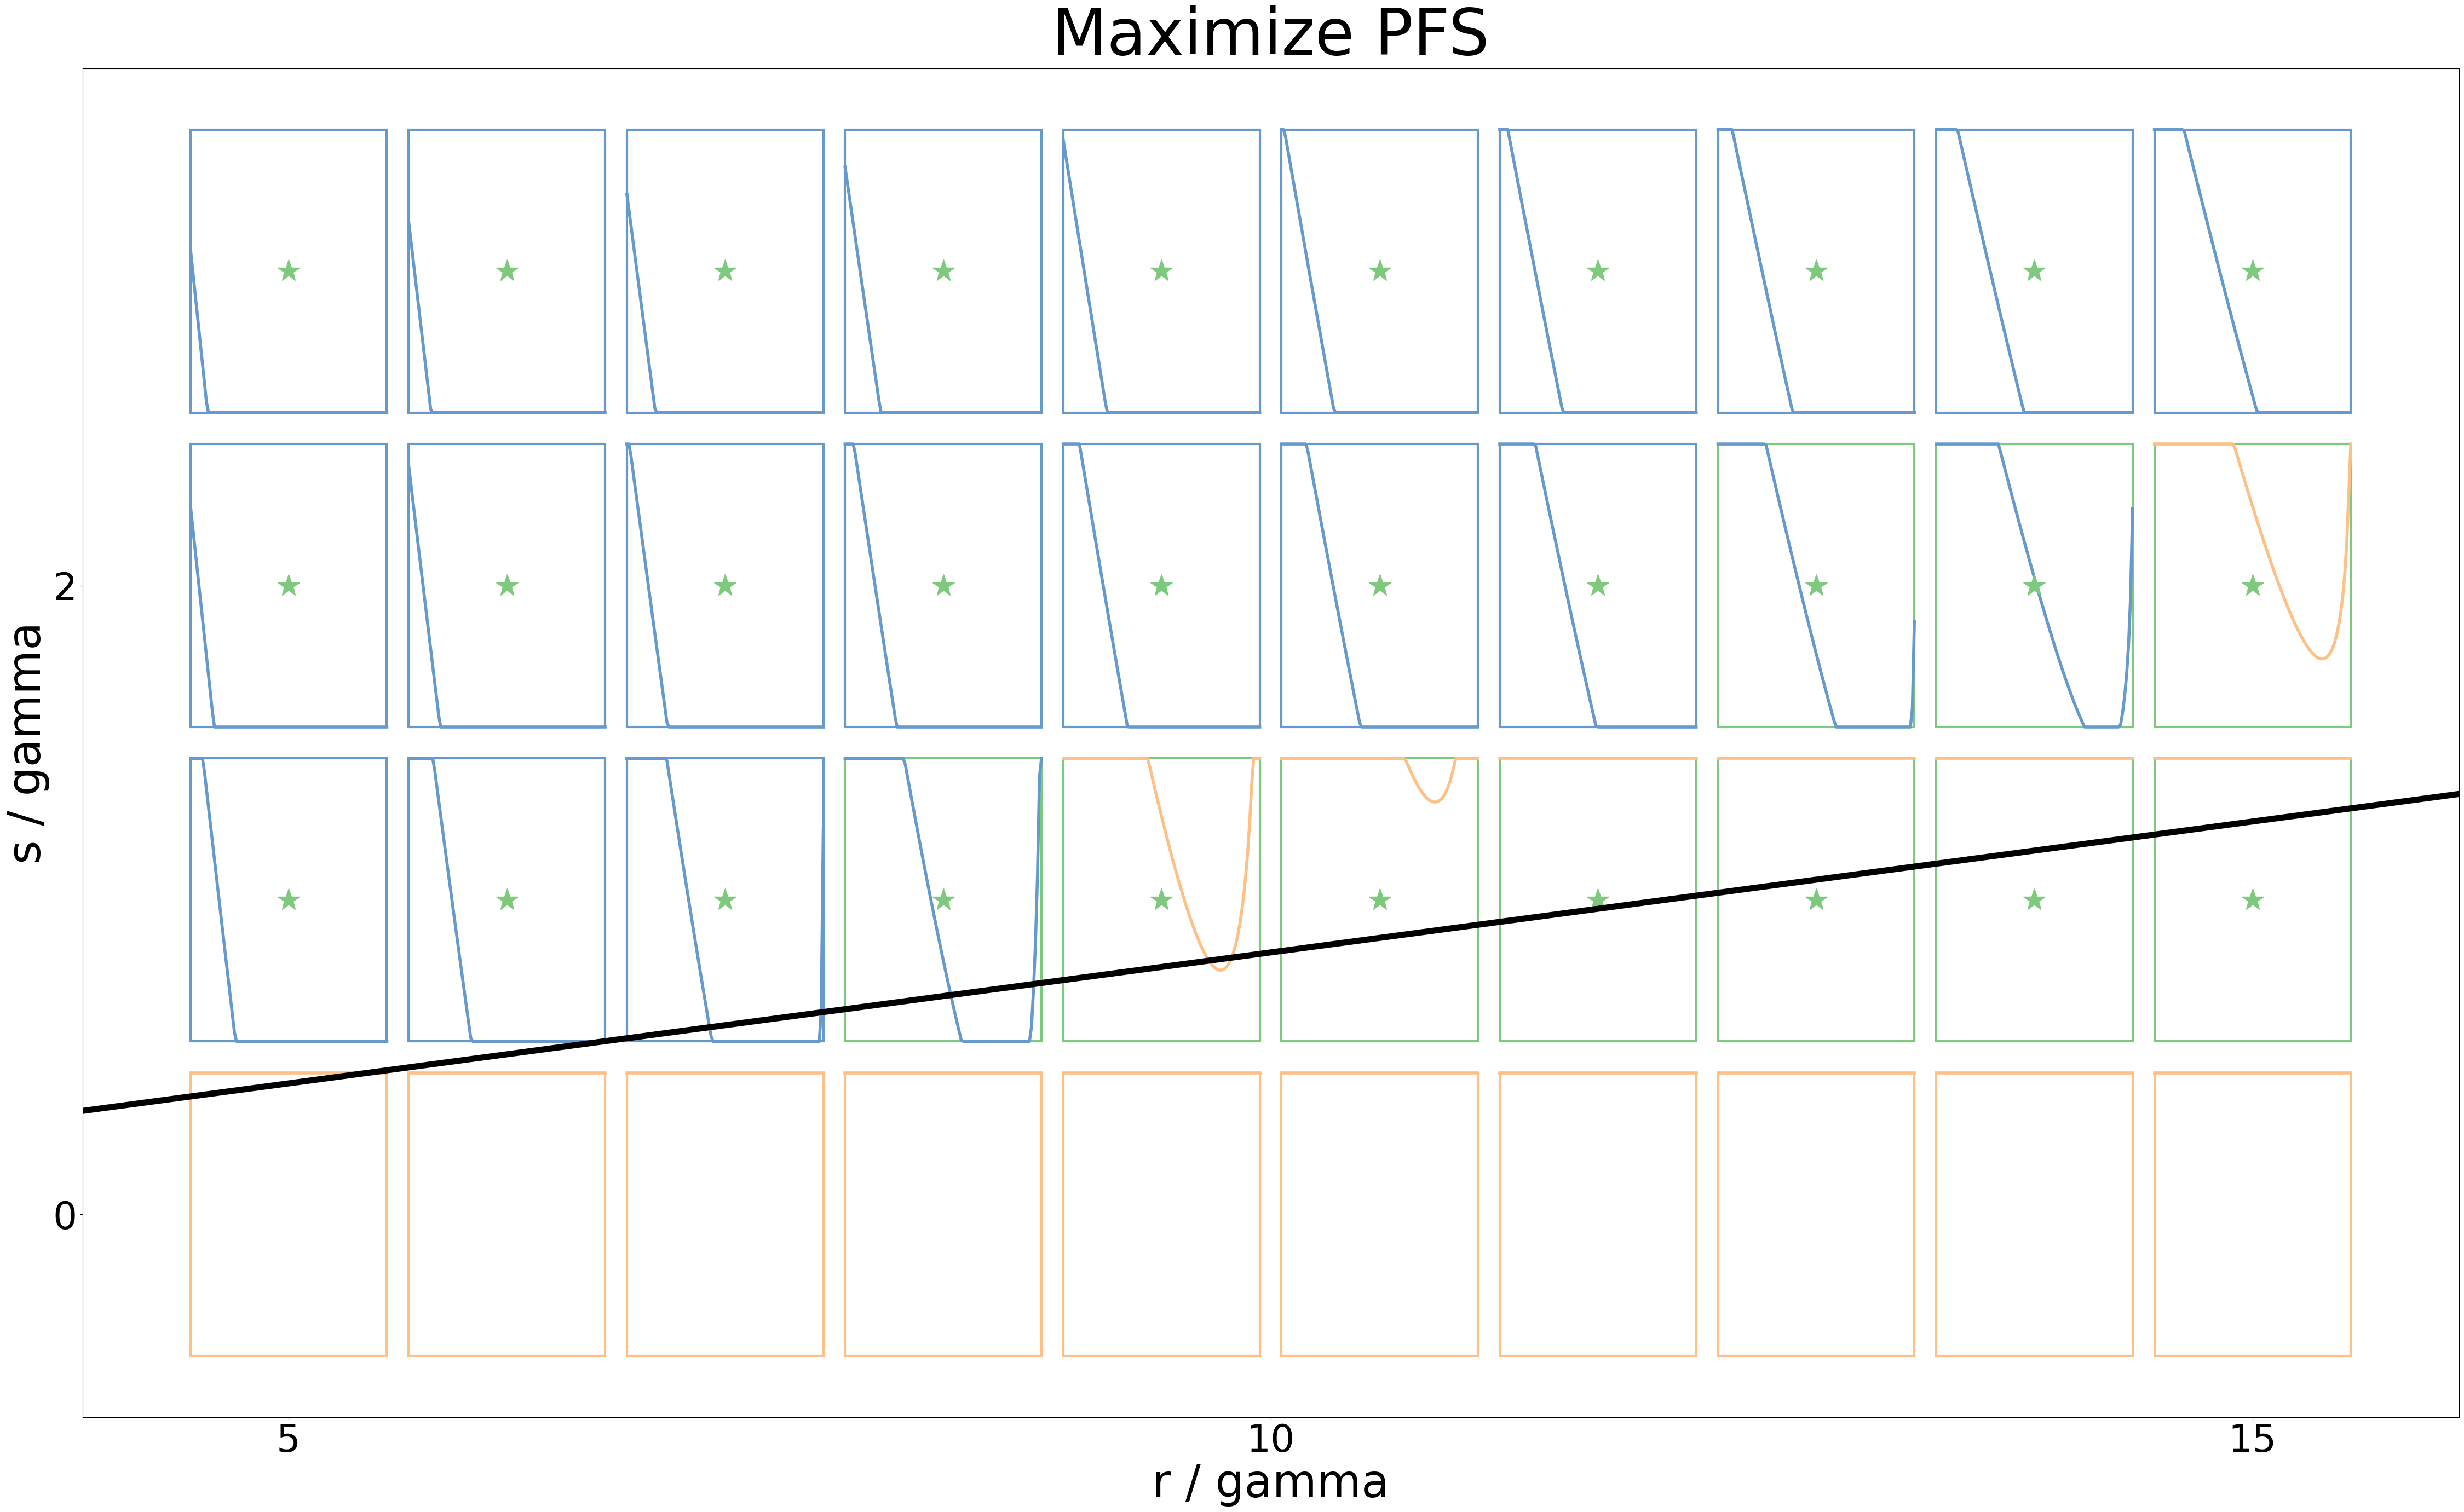

In [8]:
# this is to be run directly after the Fig 3 PFS phase diagram is created, which is why it is out of order.
SU.infinitesimalphaseboundaryplot(storage,phasespace,storagereport,timepercycle,rvals,svals,rvalsX,svalsY,gamma,delta,metric,smin,smax)

## Fig 4. Various two drug optimal schedules.

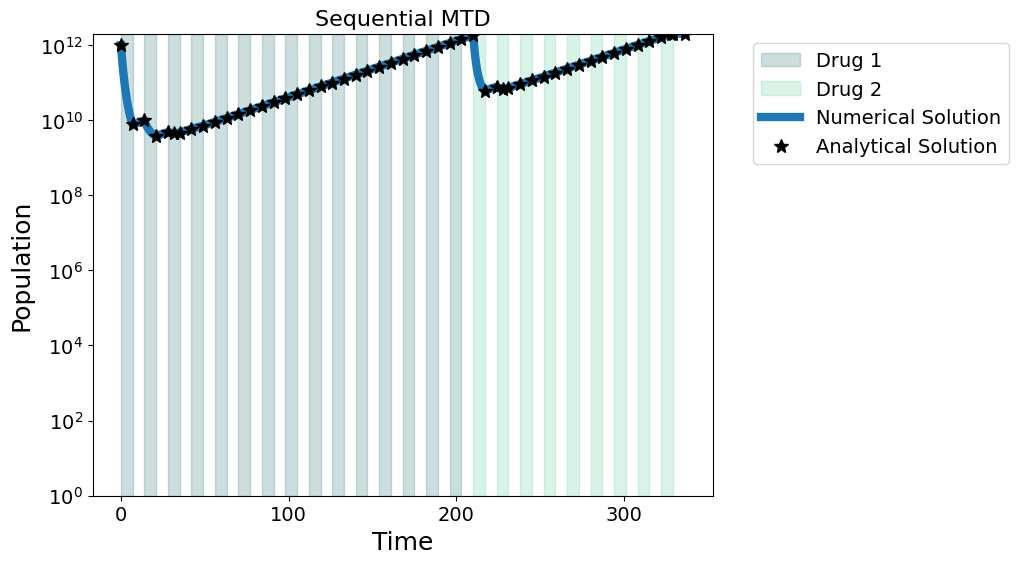

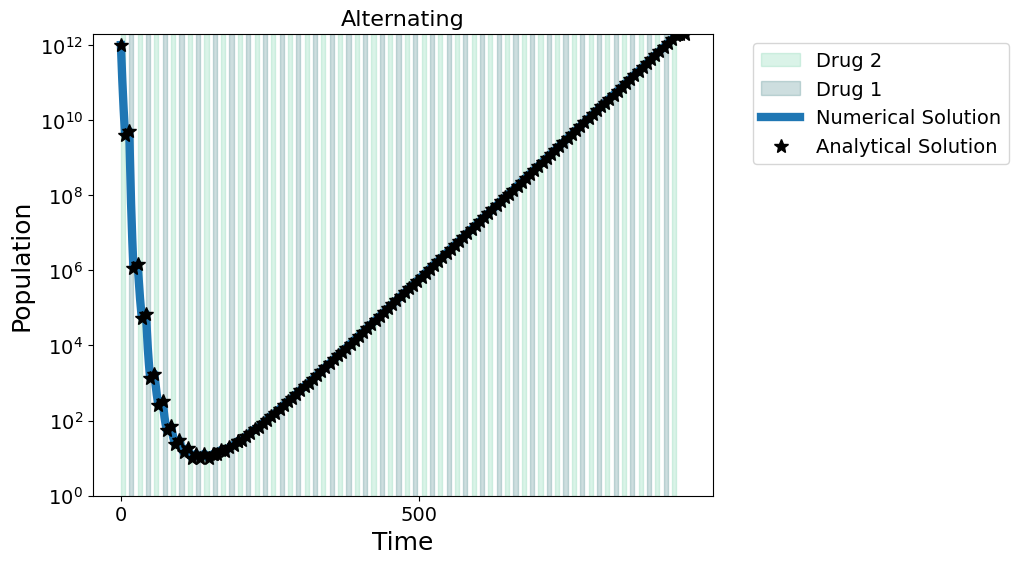

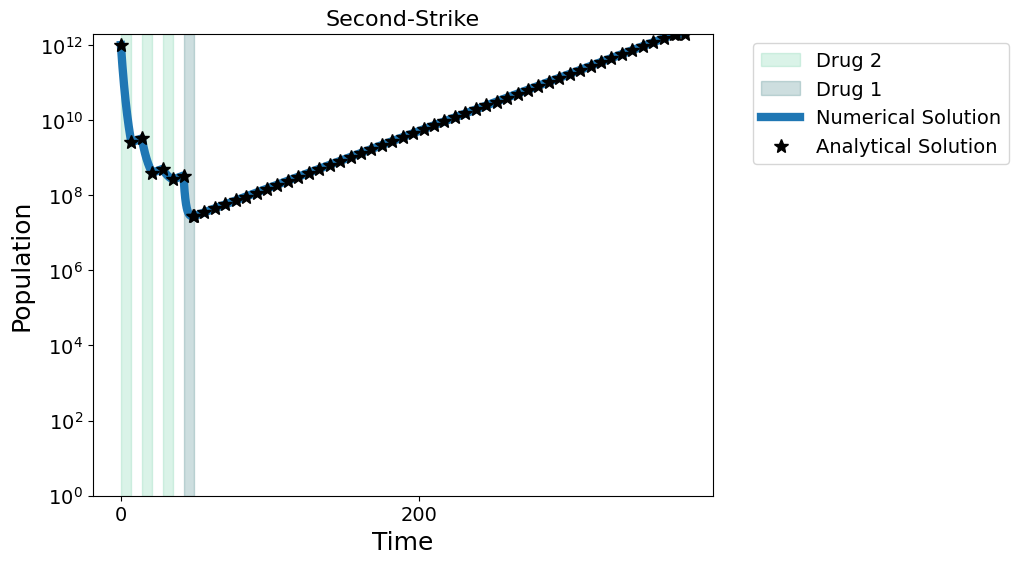

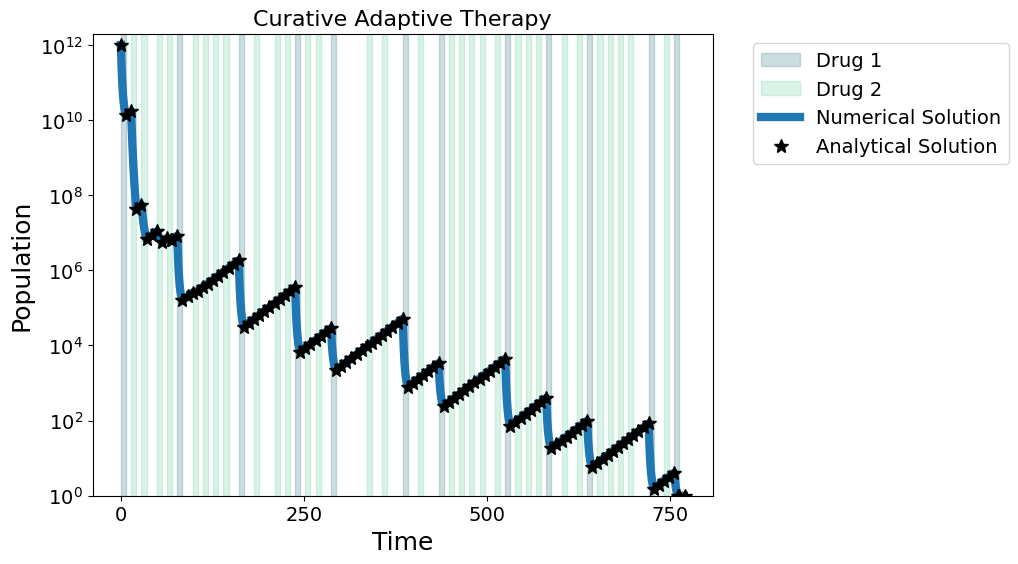

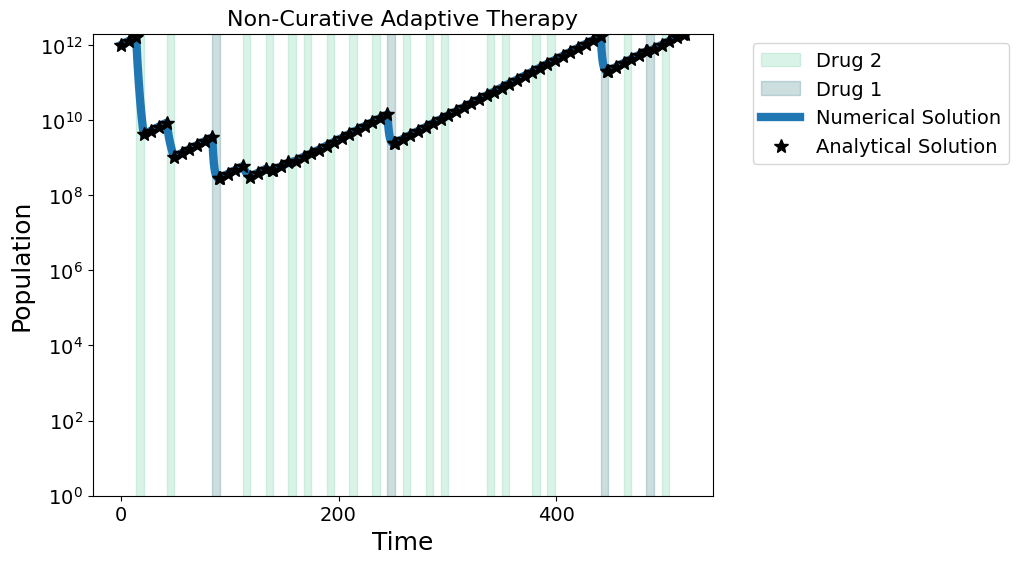

In [9]:
# set the seed here because the AT strategies are noisy
np.random.seed(1001)

######## Sequential MTD ##########
gamma = np.log(2)/20
deltamult1 = 40
rmult1 = 6
smult1 = 0
deltamult2 = 40
rmult2 = 10
smult2 = 0
params = [gamma, [deltamult1 * gamma, deltamult2 * gamma], [rmult1 * gamma, rmult2 * gamma], [smult1 * gamma, smult2 * gamma]]
metric = 'PFS'
timepercycle = 7
ncycles = 10000
beta0 = 0.01
optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, beta0=beta0)
overalloptimalstrategy = SU.get_final_optimum2(optimalstrategy,metric,params,timepercycle)

# plot the solution
fig = SU.full_sim(params,overalloptimalstrategy,timepercycle=timepercycle)
analyticalt,analyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],overalloptimalstrategy,timepercycle, *params)
plt.plot(analyticalt,[yy[0] for yy in analyticaly],'k*',markersize=10,label='Analytical Solution')
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Sequential MTD',fontsize=16)
plt.ylim([1,2e12])
plt.show()

######## Alternating ##########
gamma = np.log(2)/20
deltamult1 = 50
rmult1 = 3
smult1 = 0
deltamult2 = 30
rmult2 = 2
smult2 = 0
params = [gamma, [deltamult1 * gamma, deltamult2 * gamma], [rmult1 * gamma, rmult2 * gamma], [smult1 * gamma, smult2 * gamma]]
metric = 'PFS'
timepercycle = 7
ncycles = 10000
beta0 = 0.01
optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, beta0=beta0)
overalloptimalstrategy = SU.get_final_optimum2(optimalstrategy,metric,params,timepercycle)

# plot the solution
fig = SU.full_sim(params,overalloptimalstrategy,timepercycle=timepercycle)
analyticalt,analyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],overalloptimalstrategy,timepercycle, *params)
plt.plot(analyticalt,[yy[0] for yy in analyticaly],'k*',markersize=10,label='Analytical Solution')
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Alternating',fontsize=16)
plt.ylim([1,2e12])
plt.show()

######## Second-Strike ##########
gamma = np.log(2)/20
deltamult1 = 50
rmult1 = 18
smult1 = 1
deltamult2 = 40
rmult2 = 4
smult2 = 0
params = [gamma, [deltamult1 * gamma, deltamult2 * gamma], [rmult1 * gamma, rmult2 * gamma], [smult1 * gamma, smult2 * gamma]]
metric = 'CURE'
timepercycle = 7
ncycles = 10000
beta0 = 0.01
optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, beta0=beta0)
overalloptimalstrategy = SU.get_final_optimum2(optimalstrategy,metric,params,timepercycle)

# plot the solution
fig = SU.full_sim(params,overalloptimalstrategy,timepercycle=timepercycle)
analyticalt,analyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],overalloptimalstrategy,timepercycle, *params)
plt.plot(analyticalt,[yy[0] for yy in analyticaly],'k*',markersize=10,label='Analytical Solution')
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Second-Strike',fontsize=16)
plt.ylim([1,2e12])
plt.show()

######## Curative AT ##########
gamma = np.log(2)/20
deltamult1 = 50
rmult1 = 10
smult1 = 2
deltamult2 = 40
rmult2 = 4
smult2 = 0
params = [gamma, [deltamult1 * gamma, deltamult2 * gamma], [rmult1 * gamma, rmult2 * gamma], [smult1 * gamma, smult2 * gamma]]
metric = 'CURE'
timepercycle = 7
ncycles = 10000
beta0 = 0.01
optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, beta0=beta0)
overalloptimalstrategy = SU.get_final_optimum2(optimalstrategy,metric,params,timepercycle)

# plot the solution
fig = SU.full_sim(params,overalloptimalstrategy,timepercycle=timepercycle)
analyticalt,analyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],overalloptimalstrategy,timepercycle, *params)
plt.plot(analyticalt,[yy[0] for yy in analyticaly],'k*',markersize=10,label='Analytical Solution')
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Curative Adaptive Therapy',fontsize=16)
plt.ylim([1,2e12])
plt.show()

######## Non-Curative AT ##########
gamma = np.log(2)/20
deltamult1 = 50
rmult1 = 18
smult1 = 1
deltamult2 = 40
rmult2 = 4
smult2 = 0
params = [gamma, [deltamult1 * gamma, deltamult2 * gamma], [rmult1 * gamma, rmult2 * gamma], [smult1 * gamma, smult2 * gamma]]
metric = 'PFS'
timepercycle = 7
ncycles = 10000
beta0 = 0.01
optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, beta0=beta0)
overalloptimalstrategy = SU.get_final_optimum2(optimalstrategy,metric,params,timepercycle)

# plot the solution
fig = SU.full_sim(params,overalloptimalstrategy,timepercycle=timepercycle)
analyticalt,analyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],overalloptimalstrategy,timepercycle, *params)
plt.plot(analyticalt,[yy[0] for yy in analyticaly],'k*',markersize=10,label='Analytical Solution')
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Non-Curative Adaptive Therapy',fontsize=16)
plt.ylim([1,2e12])
plt.show()

## Fig 4. Sweep of phase space for 2 drugs. Cure and PFS

In [10]:
# Do the phase space calculation with the simulated annealing algorithm

# first make all possible param values
gamma = np.log(2) / 20
delta1 = 50 * gamma
delta2 = 40 * gamma
r2 = 7 * gamma
s2 = 0 * gamma
rmin = 10 * gamma 
rmax = 20 * gamma
smin = 0 
smax = 3 * gamma
linsamplenr = 9
linsamplens = 3
nwindows = 16
timepercycle = 7
rvals = [rmin + kk * (rmax - rmin) / linsamplenr for kk in range(linsamplenr+1)]
svals = [smin + kk * (smax - smin) / linsamplens for kk in range(linsamplens+1)]
phasespace = [[gamma, [delta1, delta2], [rr,r2], [ss,s2]] for rr in rvals for ss in svals]
rvalsX = [ps[2][0] / ps[0] for ps in phasespace]
svalsY = [ps[3][0] / ps[0] for ps in phasespace]

# set up other parameters and stuff for the loop
metric = 'CURE' 
storage = []
storageE = []
storagereport = []
ncycles = 10000

# additional variables
curethresh = 1
progthresh = 2e12
print('Searching {} points in phase space'.format(len(phasespace)))

# time it
start_time = time.time()

for psindx,params in enumerate(phasespace):
    strategystart = None  
    optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, strategystart=strategystart)
    overalloptimalstrategy,report = SU.get_final_optimum2(optimalstrategy,metric,params,timepercycle,reporting=True)
    storage.append(overalloptimalstrategy)
    storageE.append(energies)
    storagereport.append(report)

end_time = time.time()
print('Done!')
elapsed_time = end_time - start_time
print("Elapsed time: {:.4f} seconds, {:.4f} seconds per parameter set".format(elapsed_time,elapsed_time / len(phasespace)))

# store all the cure schedules to use as the starting point for the PFS run
if metric == 'CURE':
    curestorage = copy.deepcopy(storage)
    

Searching 40 points in phase space
Done!
Elapsed time: 278.4749 seconds, 6.9619 seconds per parameter set


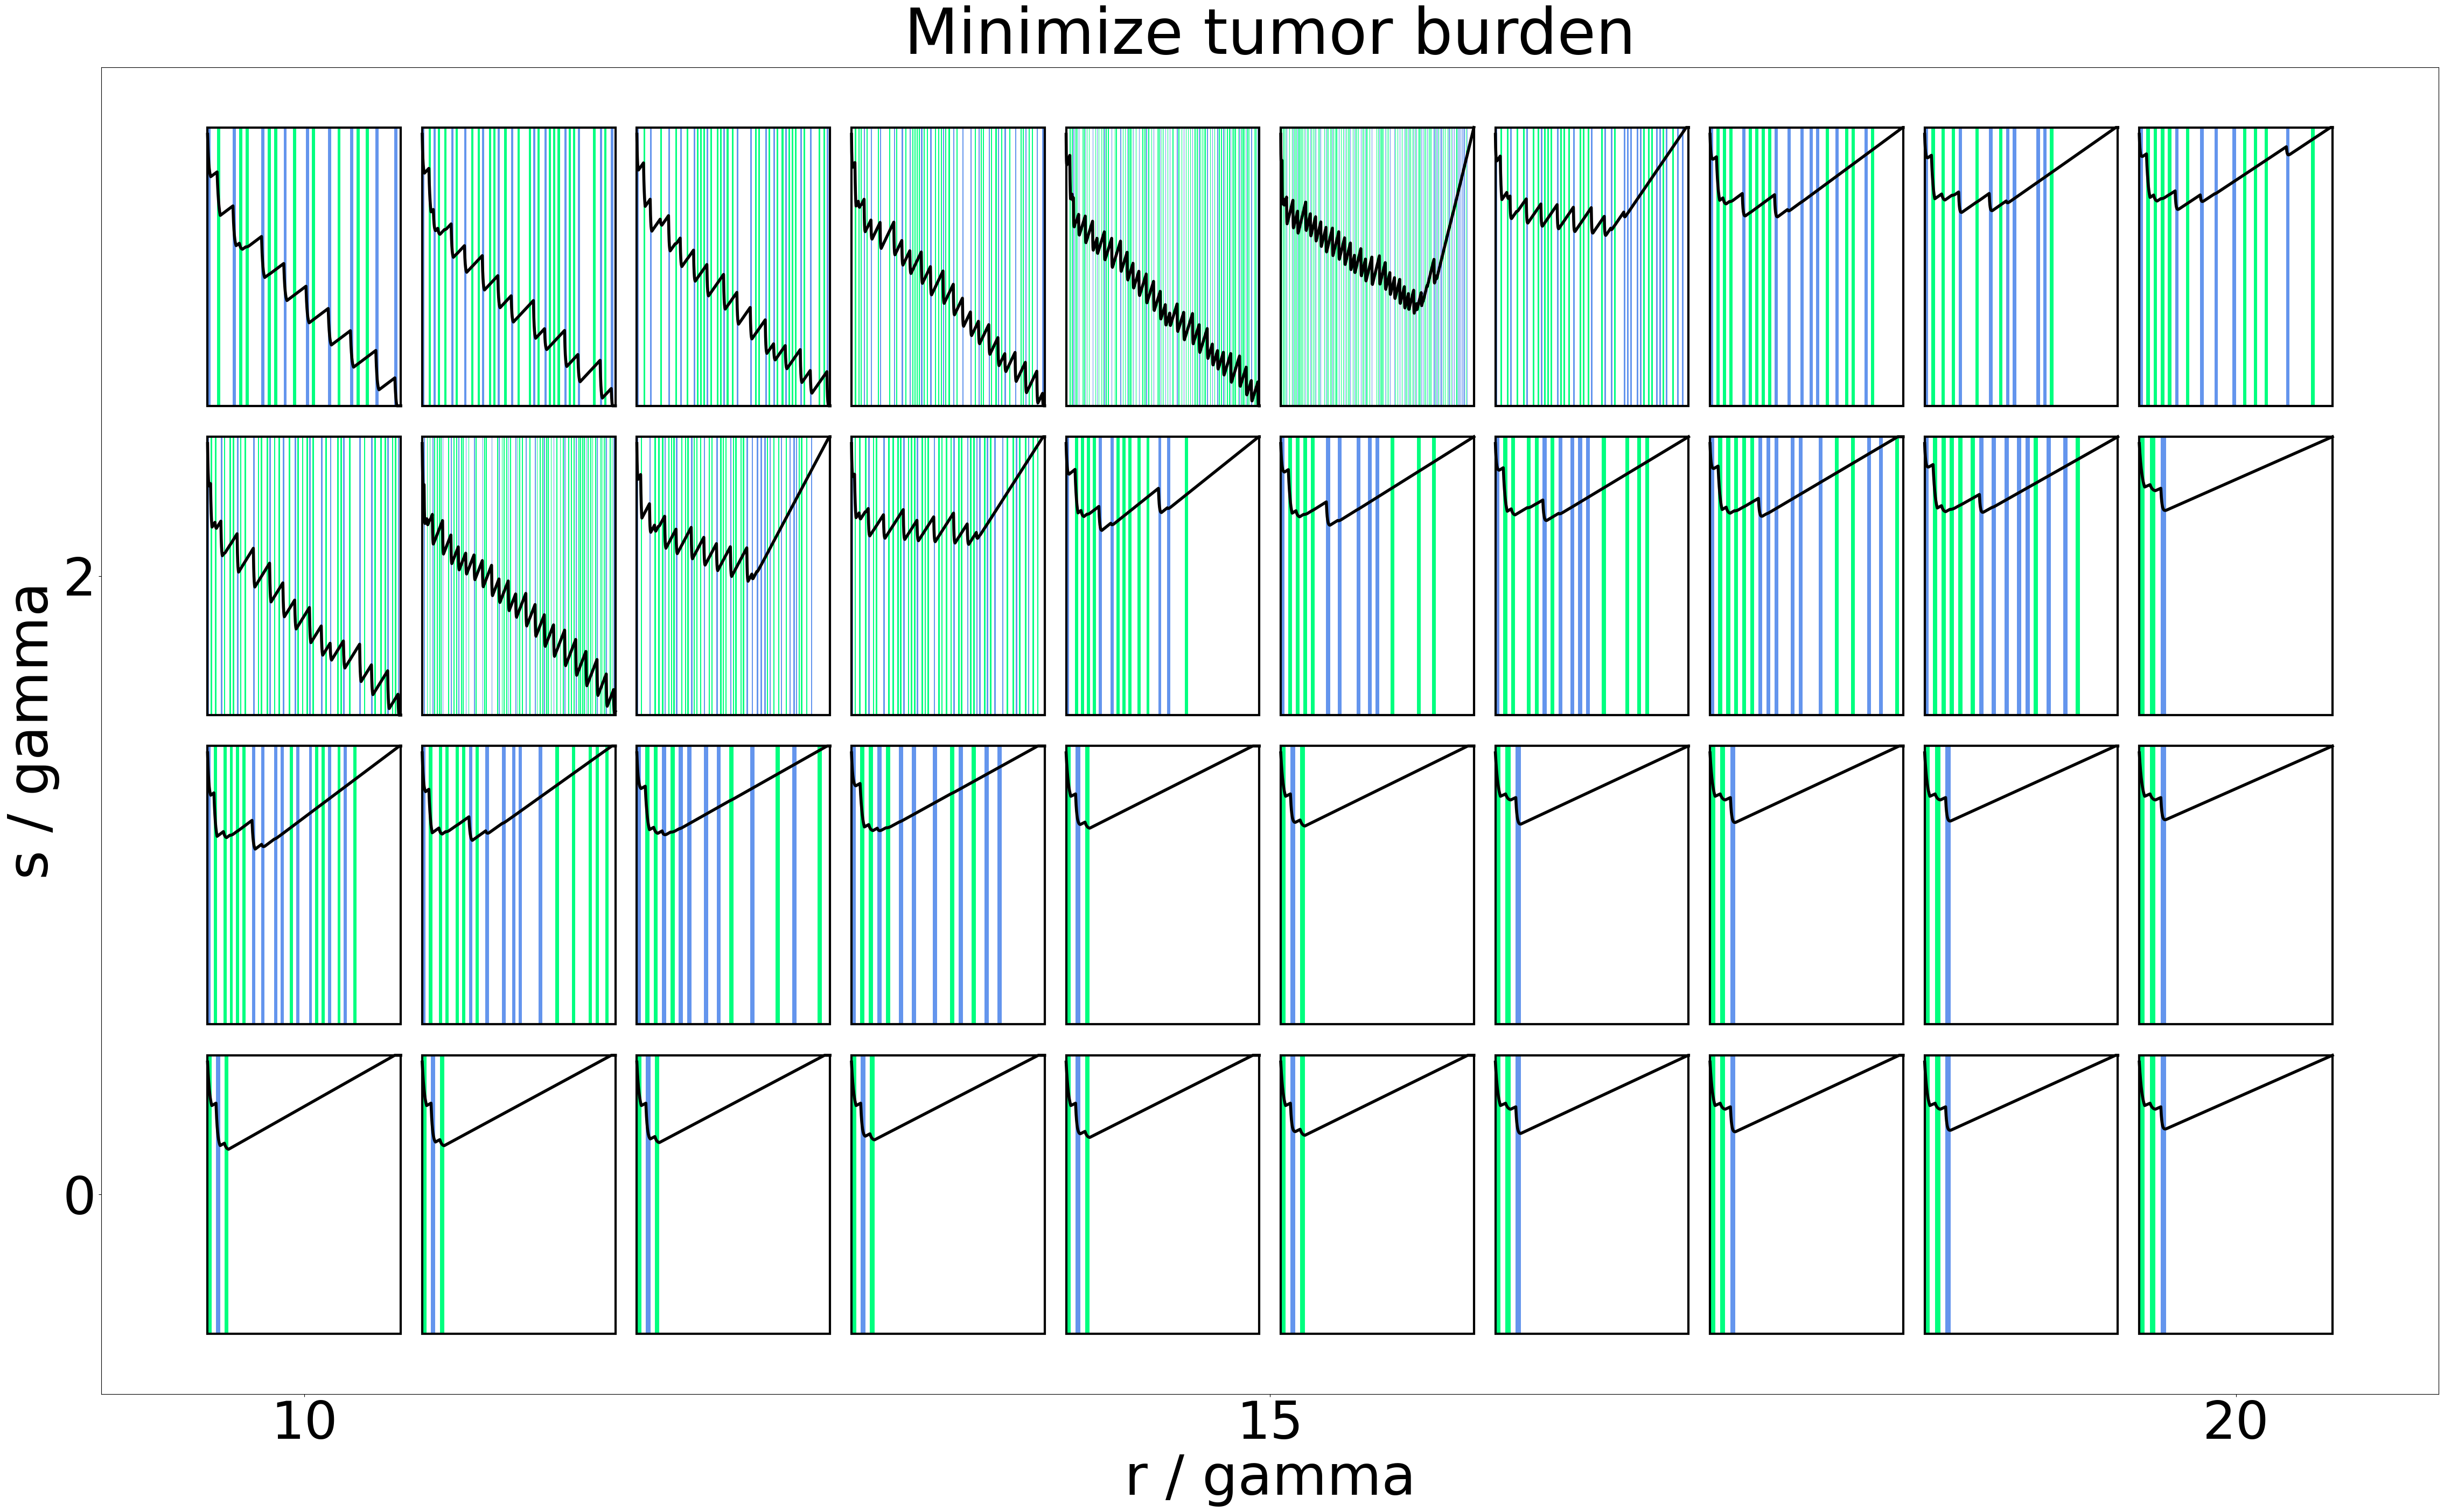

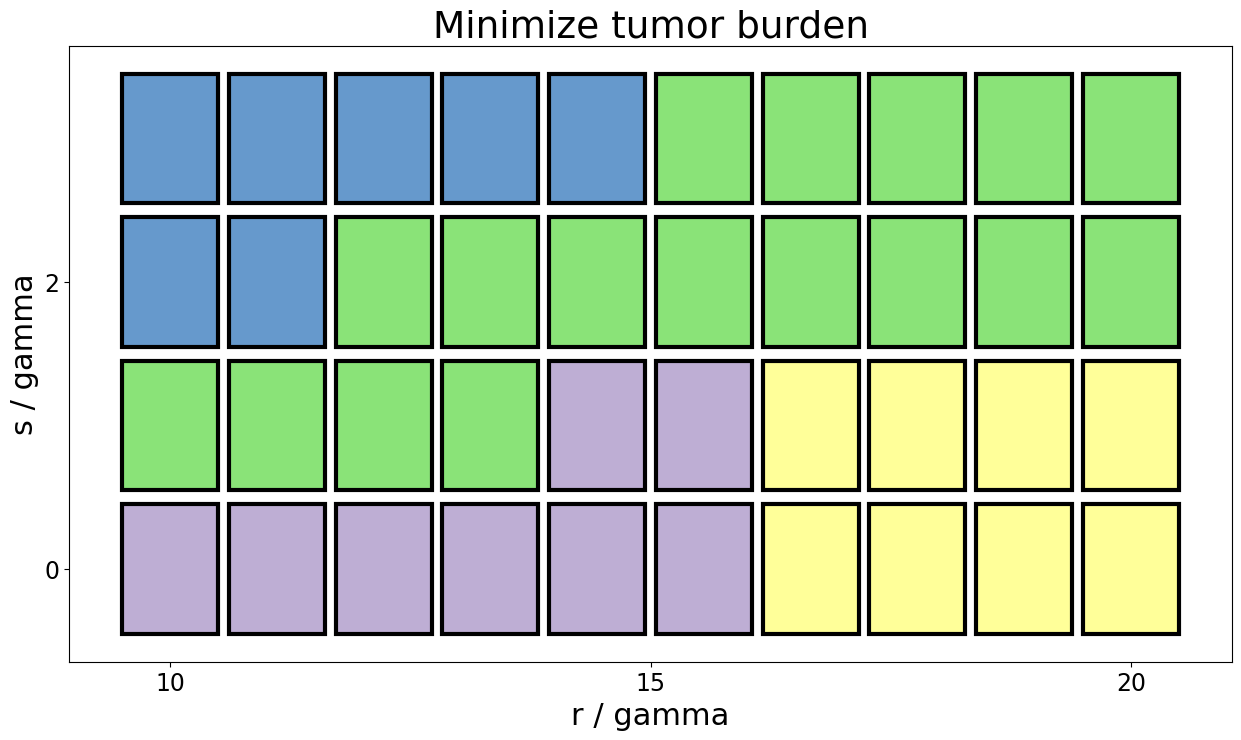

In [11]:
SU.plotphasediagram2(storage,phasespace,storagereport,timepercycle,rvals,svals,rvalsX,svalsY,gamma,metric)

In [12]:
# Do the phase space calculation with the simulated annealing algorithm

np.random.seed(0) # Note that there can be some variability in this phase diagram if you change the seed. 
# On investigating it, this happens because the energies for the simulated annealing and sequential schedules differ in the 12th digit. 
# therefore, there is a machine precision issue. We know this because sequential can be analytically shown to be the optimal schedule
# For actual implementations, this does not matter, as both schedules give the same PFS outcome. But for the theory and phase diagram interpretation, it does. Therefore, we set the seed to reproduce the figure in the paper, which reflects the underlying analytical result.

# first make all possible param values
gamma = np.log(2) / 20
delta1 = 50 * gamma
delta2 = 40 * gamma
r2 = 7 * gamma
s2 = 0 * gamma
rmin = 10 * gamma 
rmax = 20 * gamma
smin = 0 
smax = 3 * gamma
linsamplenr = 9
linsamplens = 3
nwindows = 16
timepercycle = 7
rvals = [rmin + kk * (rmax - rmin) / linsamplenr for kk in range(linsamplenr+1)]
svals = [smin + kk * (smax - smin) / linsamplens for kk in range(linsamplens+1)]
phasespace = [[gamma, [delta1, delta2], [rr,r2], [ss,s2]] for rr in rvals for ss in svals]
rvalsX = [ps[2][0] / ps[0] for ps in phasespace]
svalsY = [ps[3][0] / ps[0] for ps in phasespace]

# set up other parameters and stuff for the loop
metric = 'PFS' 
storage = []
storageE = []
storagereport = []
ncycles = 10000

# additional variables
curethresh = 1
progthresh = 2e12
print('Searching {} points in phase space'.format(len(phasespace)))

# time it
start_time = time.time()

for psindx,params in enumerate(phasespace):
    strategystart = None  
    if metric == 'PFS' and 'curestorage' in locals():
        strategystart = curestorage[psindx]
        
    optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, strategystart=strategystart)
    overalloptimalstrategy,report = SU.get_final_optimum2(optimalstrategy,metric,params,timepercycle,reporting=True)
    storage.append(overalloptimalstrategy)
    storageE.append(energies)
    storagereport.append(report)

end_time = time.time()
print('Done!')
elapsed_time = end_time - start_time
print("Elapsed time: {:.4f} seconds, {:.4f} seconds per parameter set".format(elapsed_time,elapsed_time / len(phasespace)))

# store all the cure schedules to use as the starting point for the PFS run
if metric == 'CURE':
    curestorage = copy.deepcopy(storage)
    

Searching 40 points in phase space
Done!
Elapsed time: 277.2321 seconds, 6.9308 seconds per parameter set


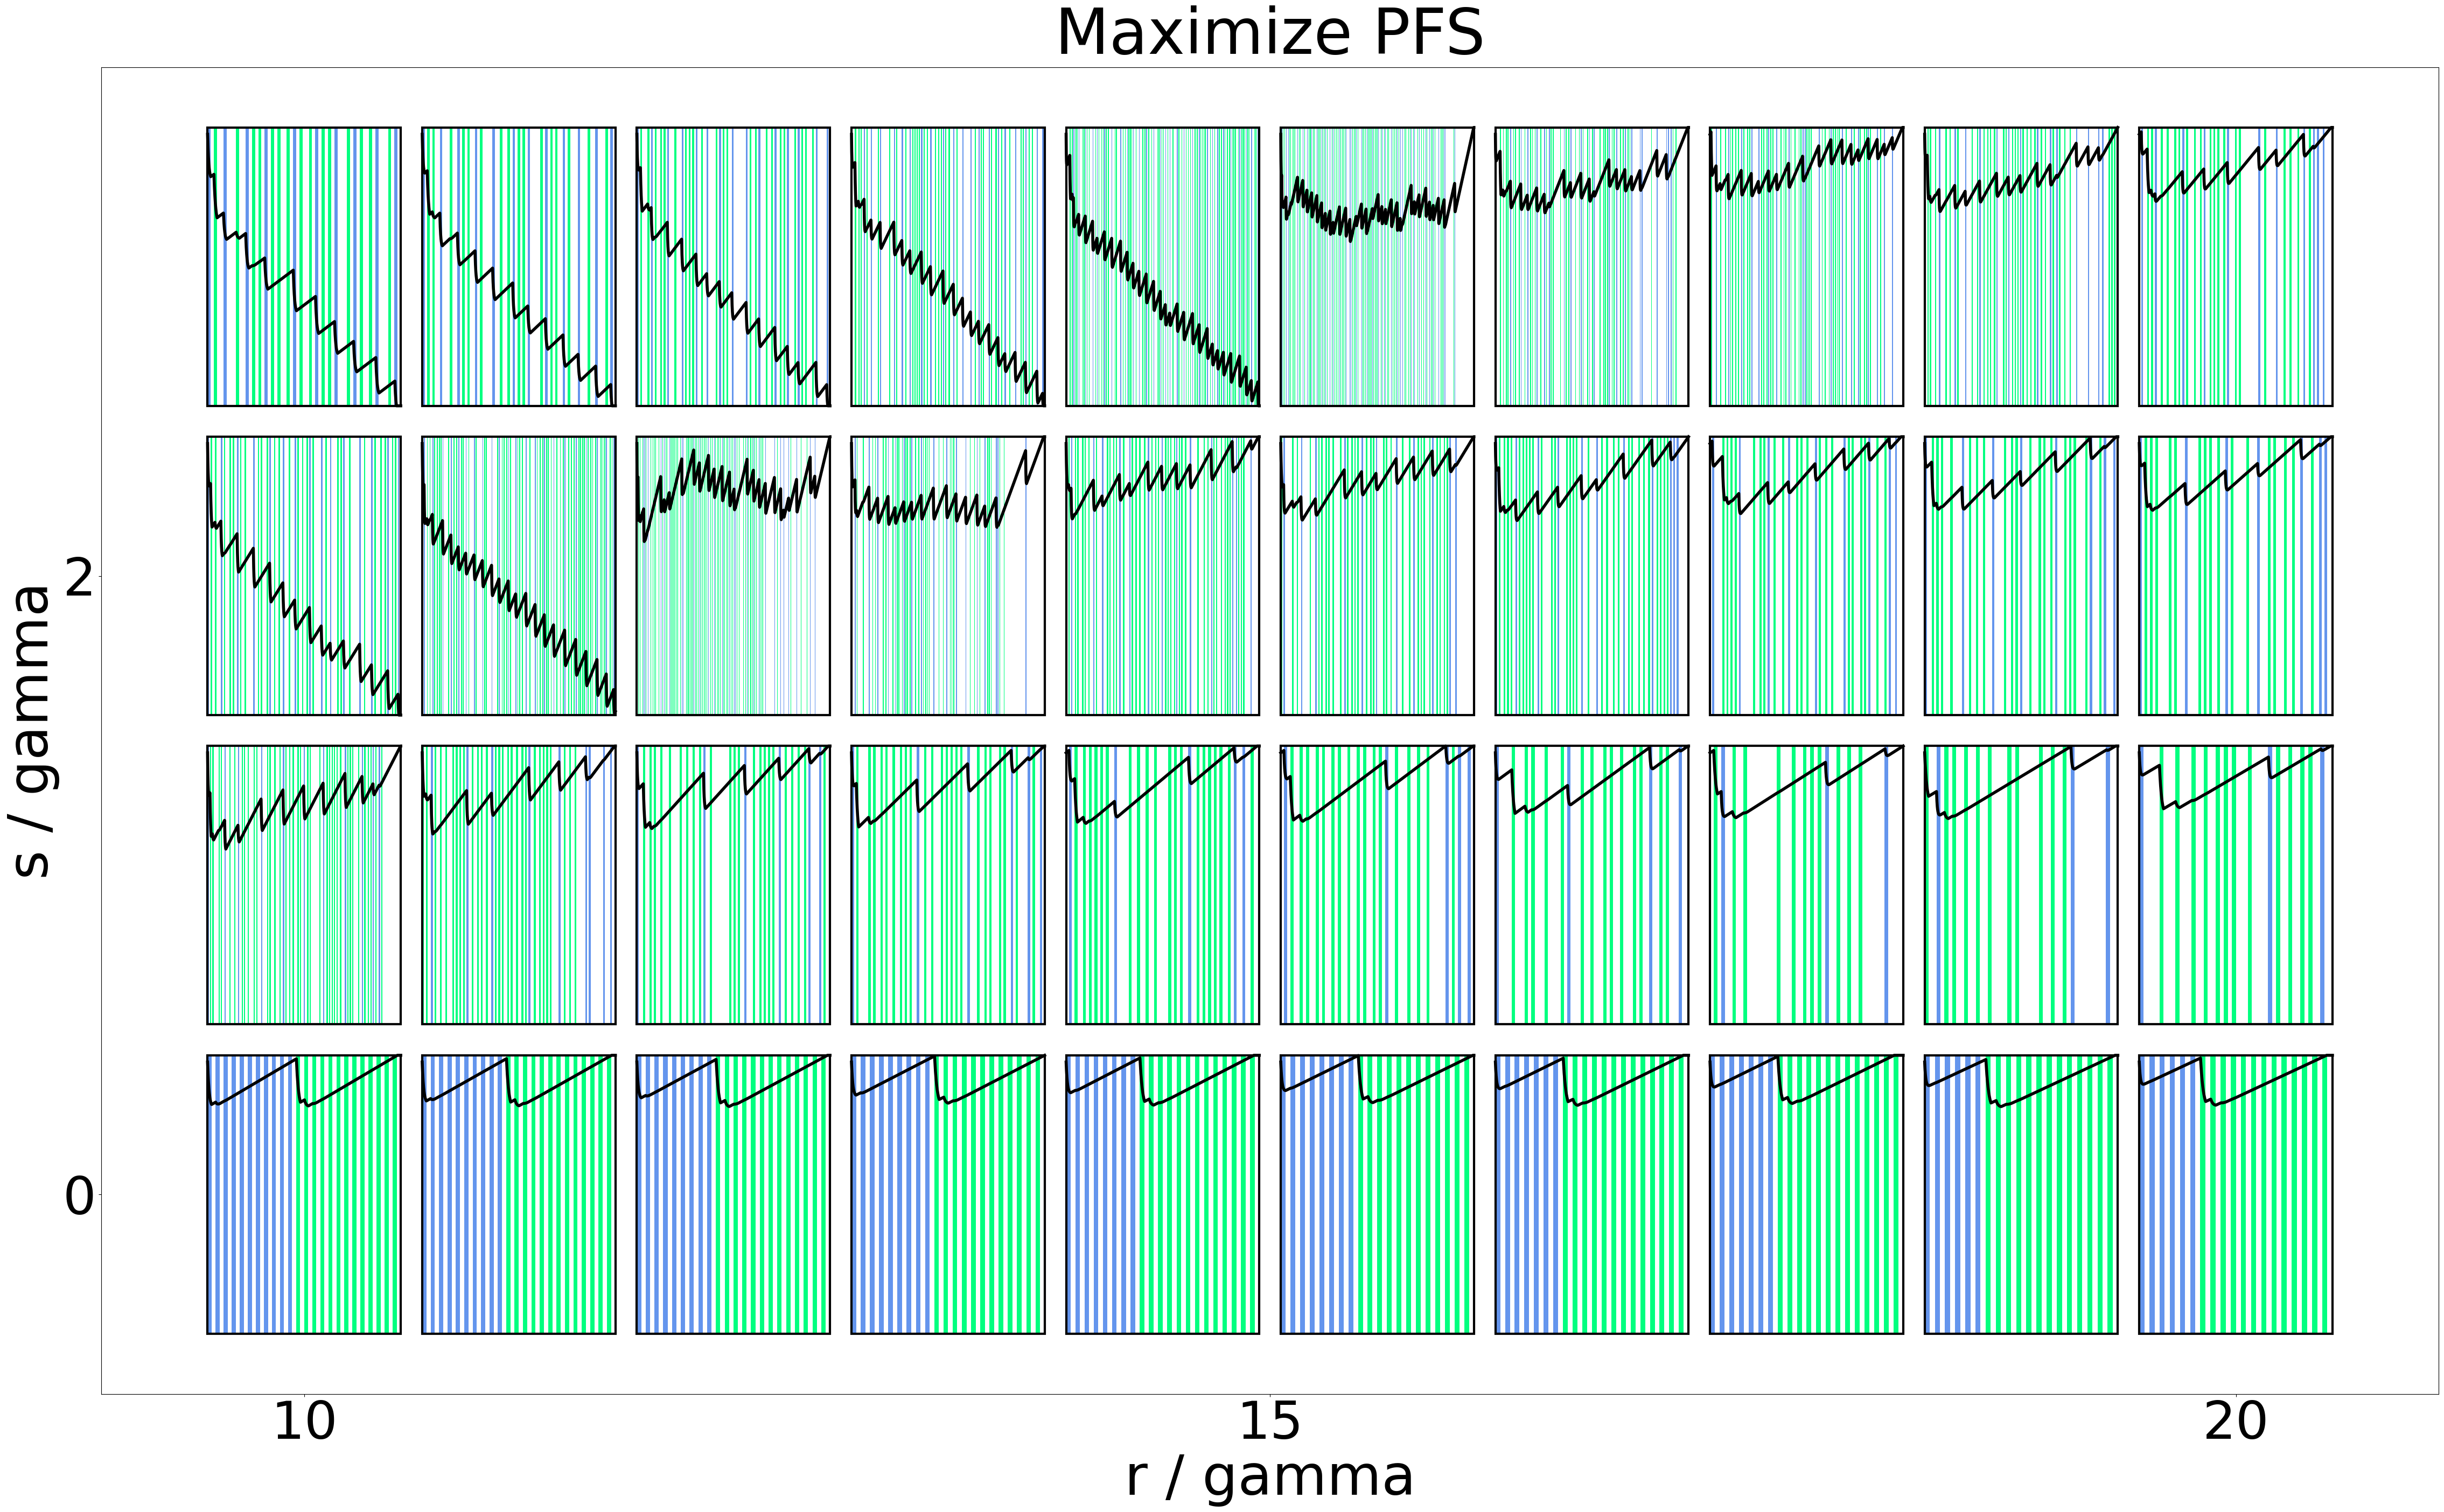

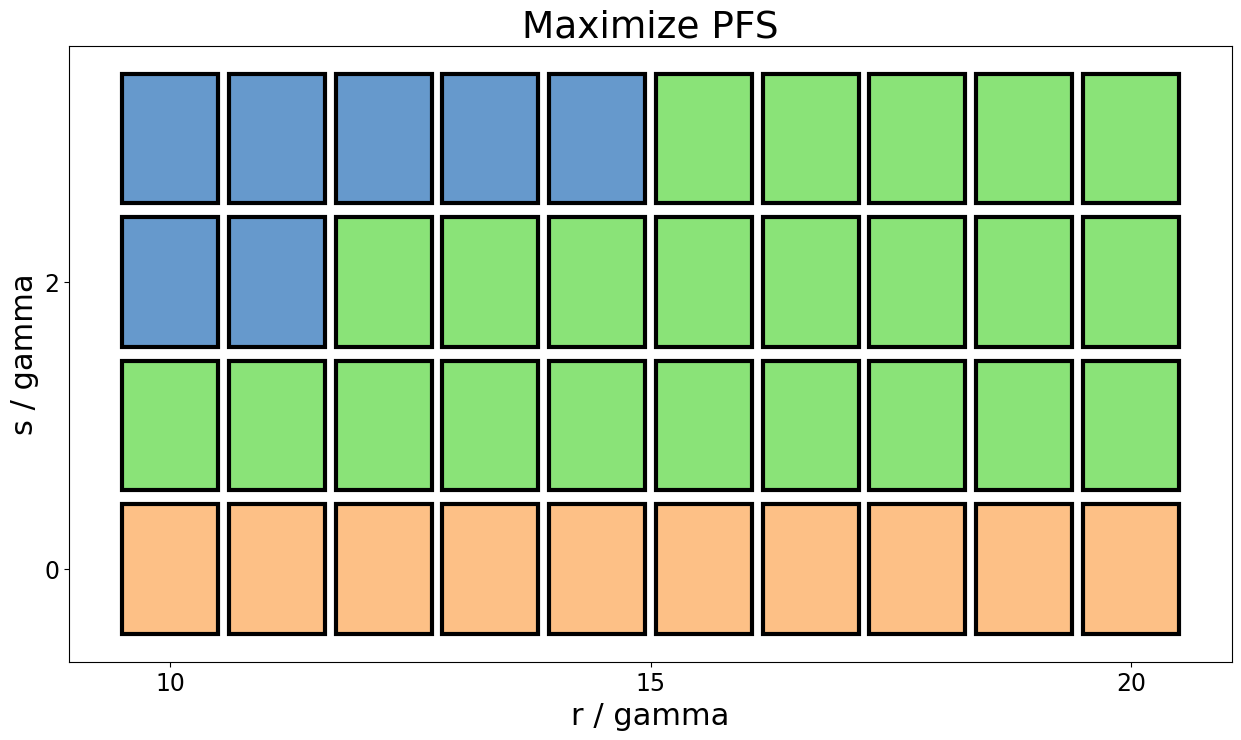

In [13]:
SU.plotphasediagram2(storage,phasespace,storagereport,timepercycle,rvals,svals,rvalsX,svalsY,gamma,metric)

## Fig S1. Load in and plot the data from MSK-CHORD. 

Pre-requisite: Visit https://www.cbioportal.org/study/summary?id=msk_chord_2024 and click the download button near the study name to download all clinical and genomic data. 

In [14]:
# static data directory, the one that contains all the files listed below. Replace the ... with the location of your download
filedir = '/Users/kocherc/Documents/data/MSK-CHORD/msk_chord_2024/' # '.../msk_chord_2024/'

# load in the patient data
ptdetails = CU.load_CHORD_data(filedir)

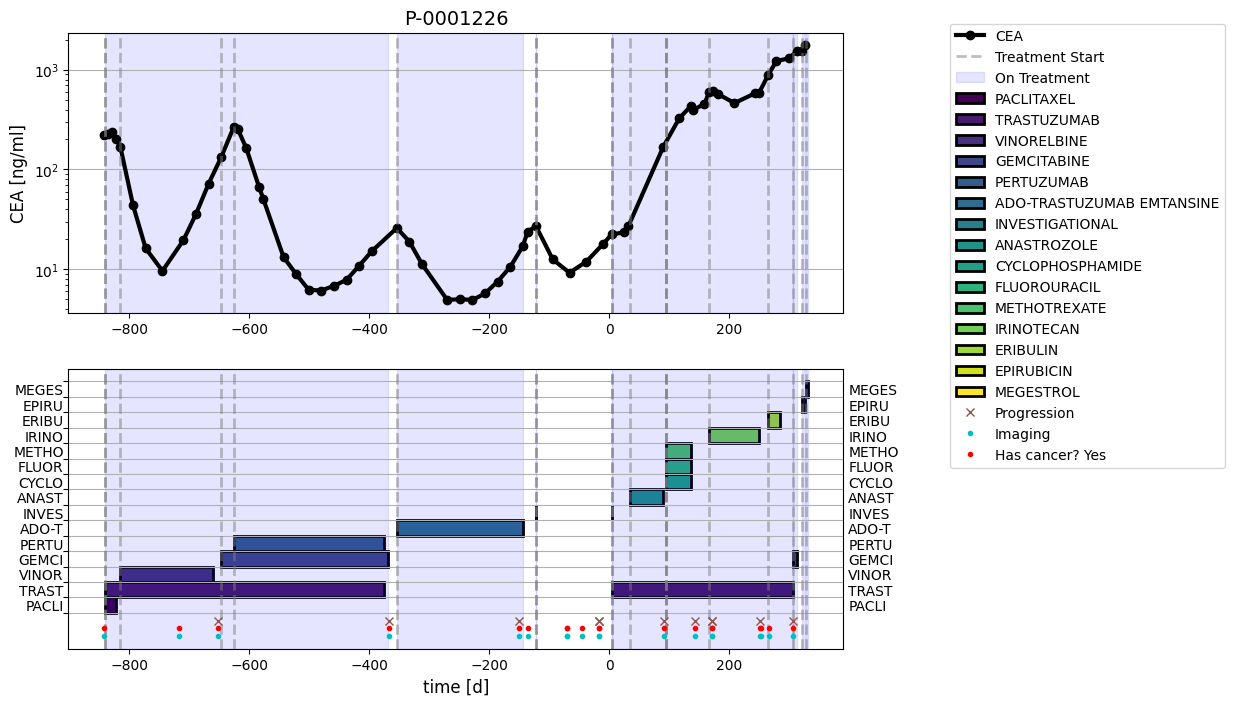

Summary for patient P-0001226, DECEASED (day 334).
Diagnosed at -3665.0 with Breast Cancer. Specifically, Breast Invasive Ductal Carcinoma.
HR+
HER2+
Histology description: Infiltrating Duct Carcinoma.
Diagnosis description: INFILTRATING DUCT CARCINOMA | BREAST, NOS (M8500/3 | C509). Stage 1-3. Localized.
Other staging information: AJCC = I. Clinical group = 1. Path group = 1.



In [15]:
# pick out patient and test
patient = 'P-0001226'
test = 'CEA'

# plot it nicely
fig = CU.plotfull(patient,test,ptdetails,minorgridlines=False)
plt.show(fig)

# print a short summary about this patient
CU.printpatientsummary(patient,ptdetails[patient])

## Fig S2. Fit the GDR model to P-0001226's data

In [16]:
# pick out patient and test
patient = 'P-0001226'
test = 'CEA'

# get test and treatment in a form we can manipulate for fitting
(sampletimes,samplevalues,units,treatments,startdates,stopdates) = CU.get_test_treatment(ptdetails[patient],test)

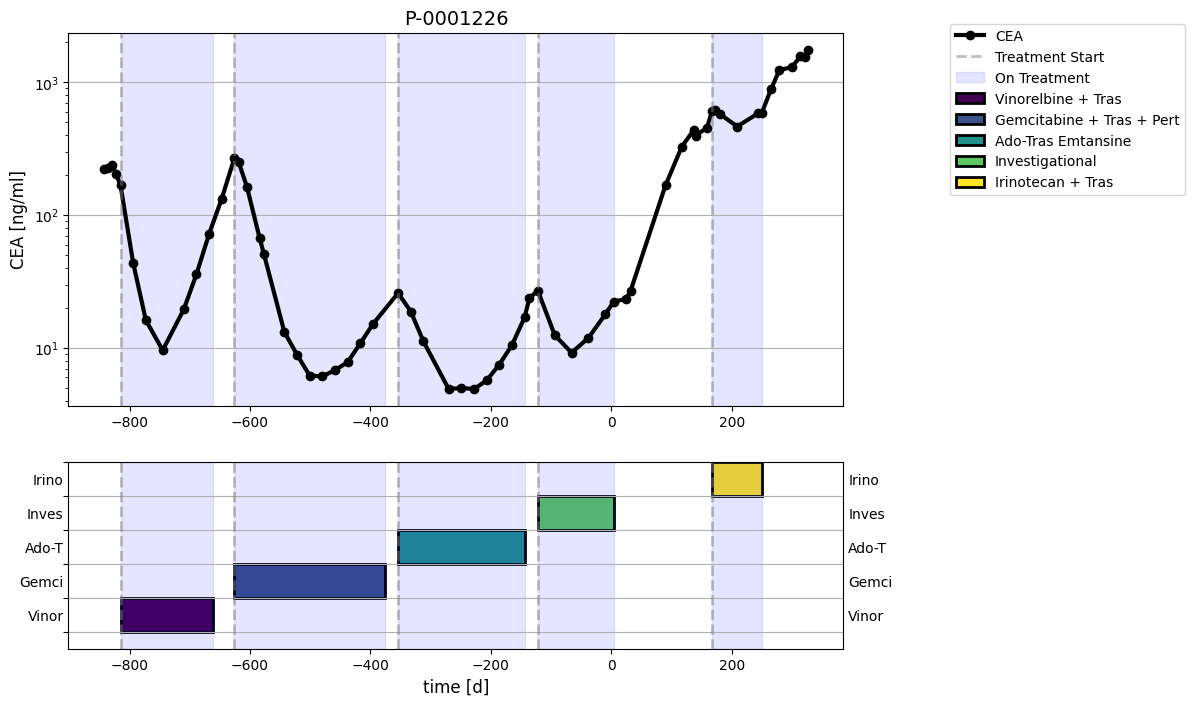

In [17]:
# visualize the treatment areas to be fit within the context of the full trajectory

# pick out the areas to fit
newtreats = ['Vinorelbine + Tras','Gemcitabine + Tras + Pert','Ado-Tras Emtansine','Investigational','Irinotecan + Tras'] # label them for concreteness
newstartdates = [startdates[2],startdates[4],startdates[5],startdates[6],startdates[14]]
newstopdates = [stopdates[2],stopdates[4],stopdates[5],startdates[8],stopdates[14]]

# show them on the full plot
slimfig = CU.plotdata(patient,test,sampletimes,samplevalues,units,newtreats,newstartdates,newstopdates,logflag=True)
plt.show(slimfig)

Estimate of untreated CEA doubling time = 16.6892 days
gamma = 0.04153271301060867 / day.


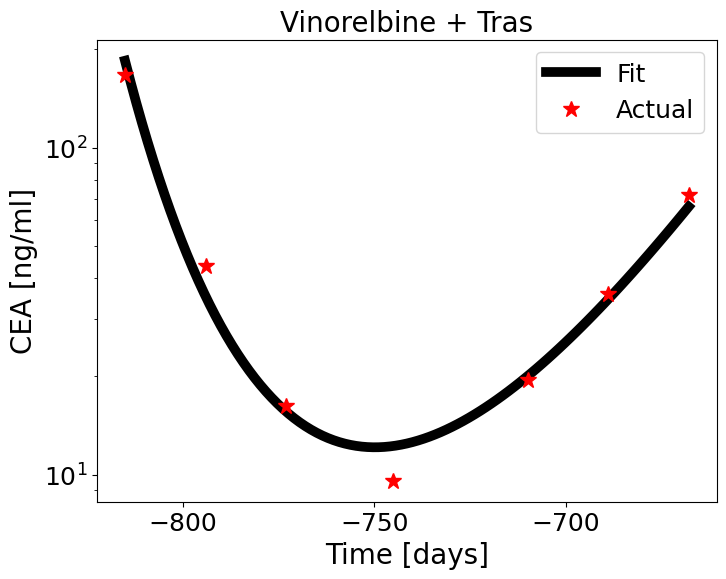

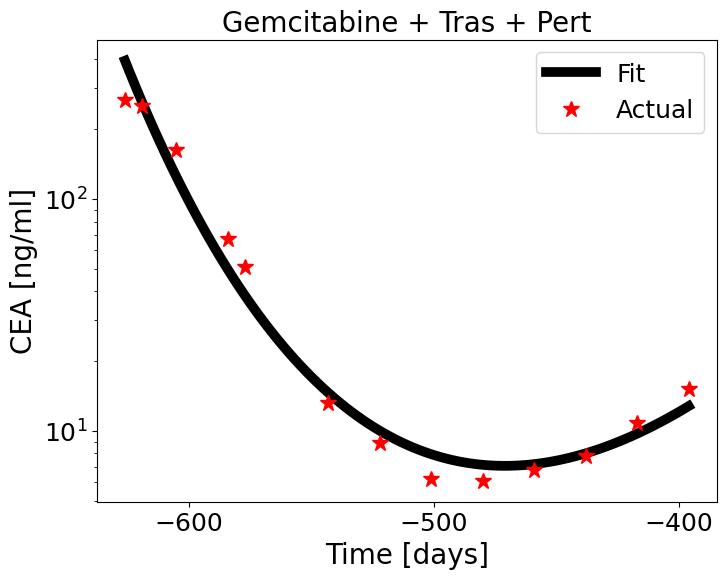

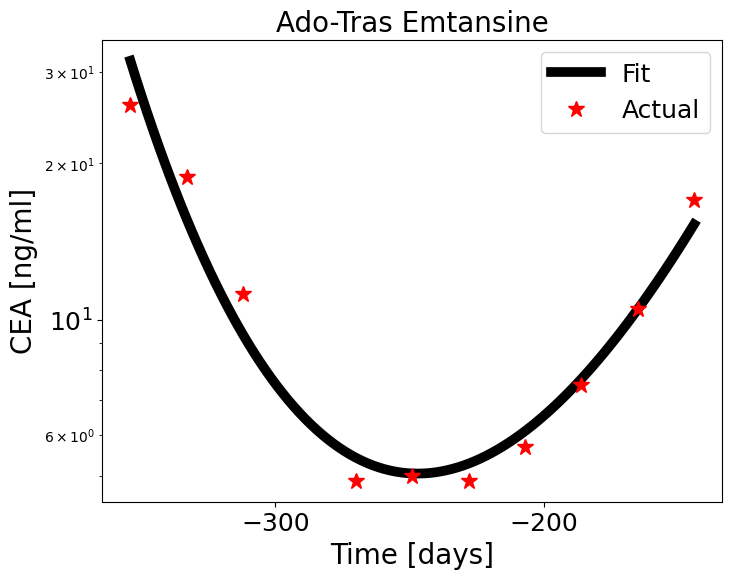

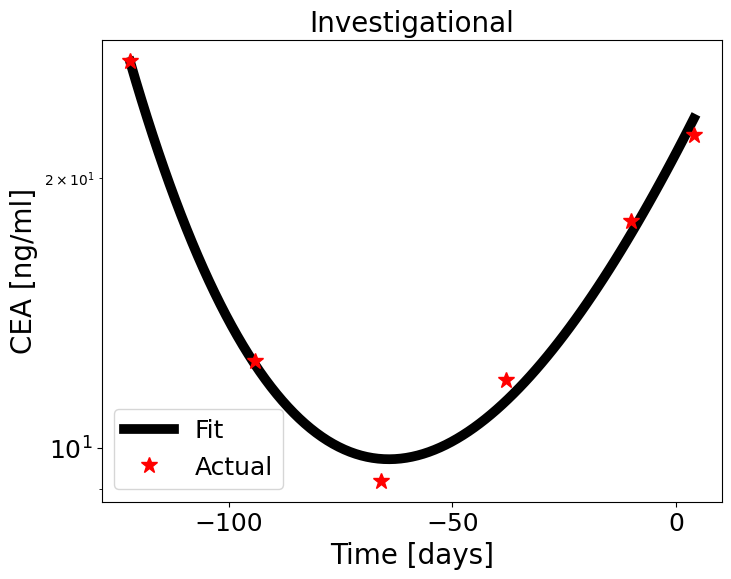

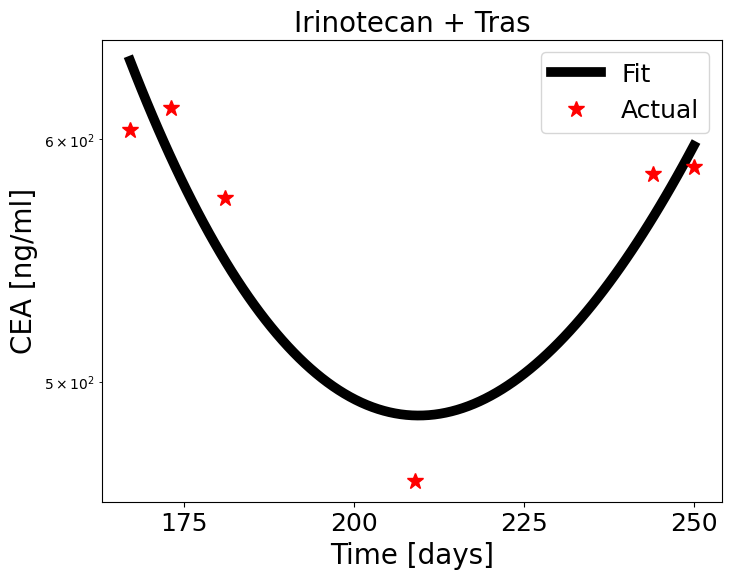

In [18]:
# now do the fitting

# first, we need an estimate of gamma (as discussed in Robertson-Tessi et al. medRxiv 2023)
# here, just approximate it as the max exponential increase rate between two consecutive points
expincreases = [np.log(samplevalues[kk+1]/samplevalues[kk]) / (sampletimes[kk+1] - sampletimes[kk]) for kk in range(len(samplevalues) - 1)]
gamma = max(expincreases) # per day
print('Estimate of untreated CEA doubling time = {:0.4f} days'.format(np.log(2) / gamma))
print('gamma = {} / day.'.format(gamma))
(T0s,rs,deltas) = CU.dofitslog(sampletimes,samplevalues,units,newtreats,newstartdates,newstopdates,gamma,test)

## Fig S3. Total number of strategies for a given number of weeks (with a rest week enforced).

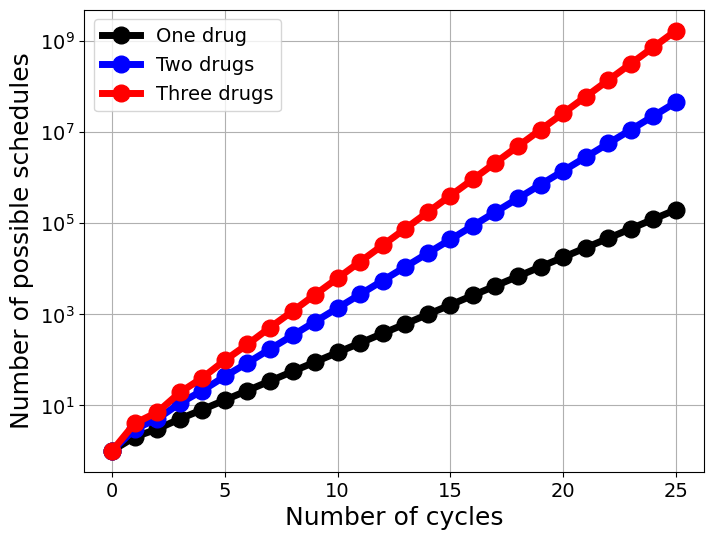

For 41 cycles, there are 4.334944e+08 schedules


In [19]:
# make some plots for scaling
xx = range(26)
onedrugschedules = [SU.num_schedules(1,kk) for kk in xx]
twodrugschedules = [SU.num_schedules(2,kk) for kk in xx]
threedrugschedules = [SU.num_schedules(3,kk) for kk in xx]

fig = plt.figure(1998,figsize=(8,6))
axs = plt.gca()
axs.plot(xx,onedrugschedules,'ko-',label='One drug',linewidth=5,markersize=12)
axs.plot(xx,twodrugschedules,'bo-',label='Two drugs',linewidth=5,markersize=12)
axs.plot(xx,threedrugschedules,'ro-',label='Three drugs',linewidth=5,markersize=12)
axs.set_ylabel('Number of possible schedules',fontsize=18)
axs.set_xlabel('Number of cycles',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.legend(fontsize=14)#,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid('on')
plt.show()

print('For 41 cycles, there are {:e} schedules'.format(SU.num_schedules(1,41)))

## Fig S4. Initialize the parameters to test for the brute force method.

In [20]:
# Initialize the GDRS parameter values to be tested. Sampling 13 different values across parameter space
gamma = np.log(2) / 20
timepercycle = 7
deltahighmult = 50
deltamidmult = 25
deltalowmult = 3/4
rlowmult = 6
rhighmult = 15
szeromult = 0
slowmult = rlowmult / 12
shighmult = rhighmult * 3 / 4
# Name the combos by which mult was used
deltanames = {deltahighmult:'H',deltamidmult:'M',deltalowmult:'L'}
rnames = {rhighmult:'H',rlowmult:'L'}
snames = {shighmult:'H',slowmult:'L',szeromult:'0'}

# generate the parameter combinations to be tested
combos = SU.generate_combos(gamma,1,deltahighmult=deltahighmult,deltamidmult=deltamidmult,deltalowmult=deltalowmult,rhighmult=rhighmult,rlowmult=rlowmult,shighmult=shighmult,slowmult=slowmult,szeromult=szeromult)

## Fig S4. Brute force PFS example.

2584 total schedules tested. 0 resulted in CURE. 2584 resulted in PROG. 0 resulted in NONE.


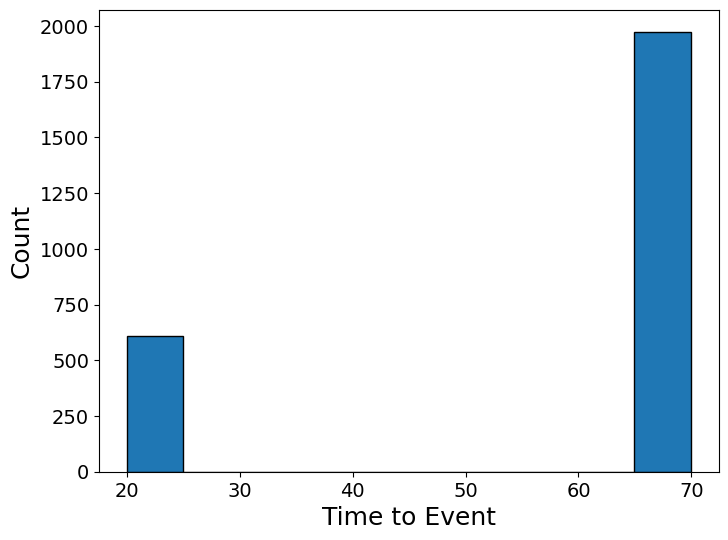

PFS Optimal Schedule is [{0}, set(), set(), set(), set(), set(), set(), set(), set(), {0}, set(), set(), set(), set(), set(), set()], with event PROG, with population 2.000E+12 at 69.93652709827575.


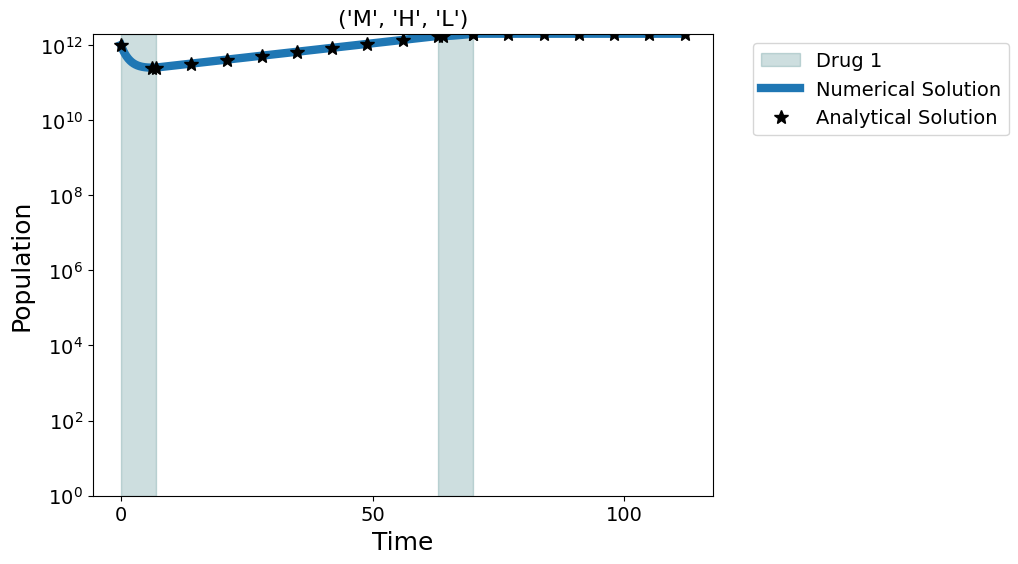

In [21]:
# pick out MHL and brute force it
params = combos[7]
metric = 'PFS'
scheduleevals = SU.strategy_eval_full_sim(params,gamma,16,metric=metric)

# plot the results
optimalschedule = SU.print_stats(scheduleevals,metric)
fig = SU.full_sim(params,optimalschedule,timepercycle=7)
analyticalt,analyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],optimalschedule,timepercycle, *params)
plt.plot(analyticalt,[yy[0] for yy in analyticaly],'k*',markersize=10,label='Analytical Solution')
comboname = (deltanames[np.round(params[1][0] / params[0],2)],rnames[params[2][0] / params[0]],snames[params[3][0] / params[0]])
plt.title('{}'.format(comboname),fontsize=16)
plt.ylim([1,2e12])
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Fig S4. Brute force CURE example

2584 total schedules tested. 617 resulted in CURE. 1967 resulted in MIN.


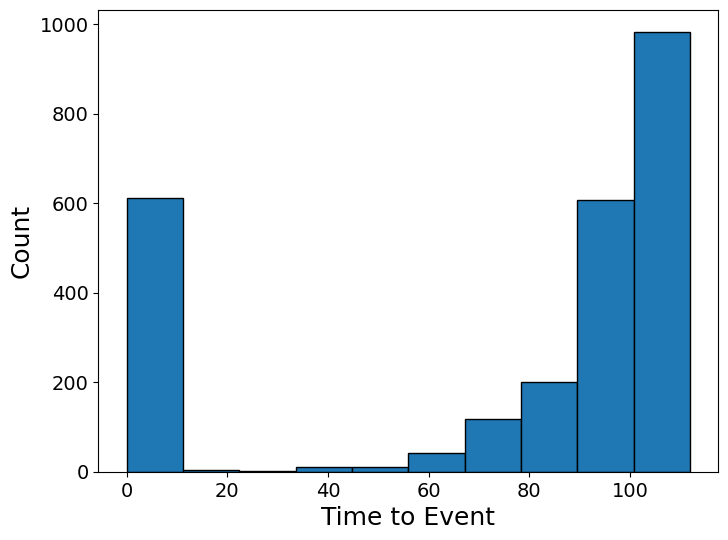

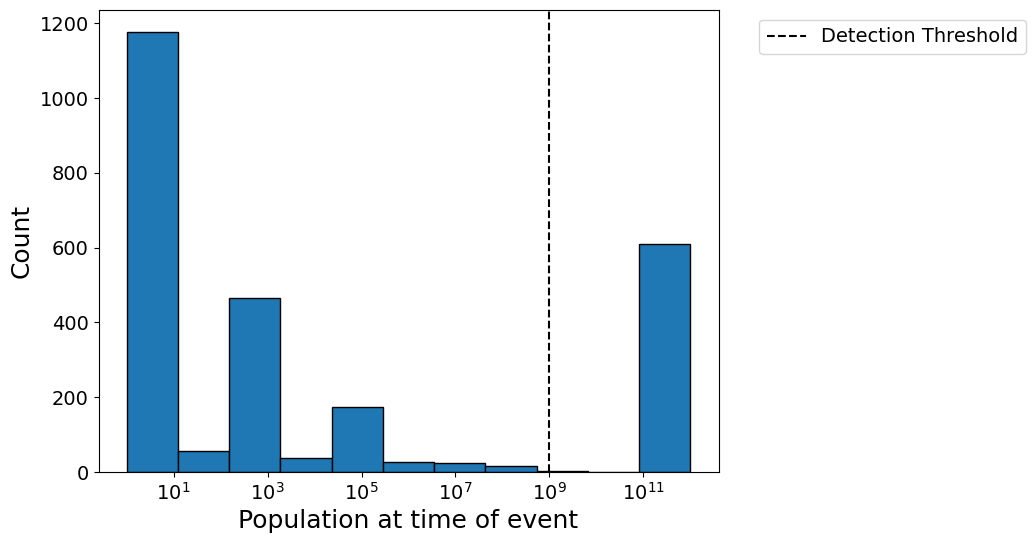

CURE Optimal Schedule is [{0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), set(), set(), set(), set()], with event CURE, with population 1.000E+00 at 74.04977475379724.


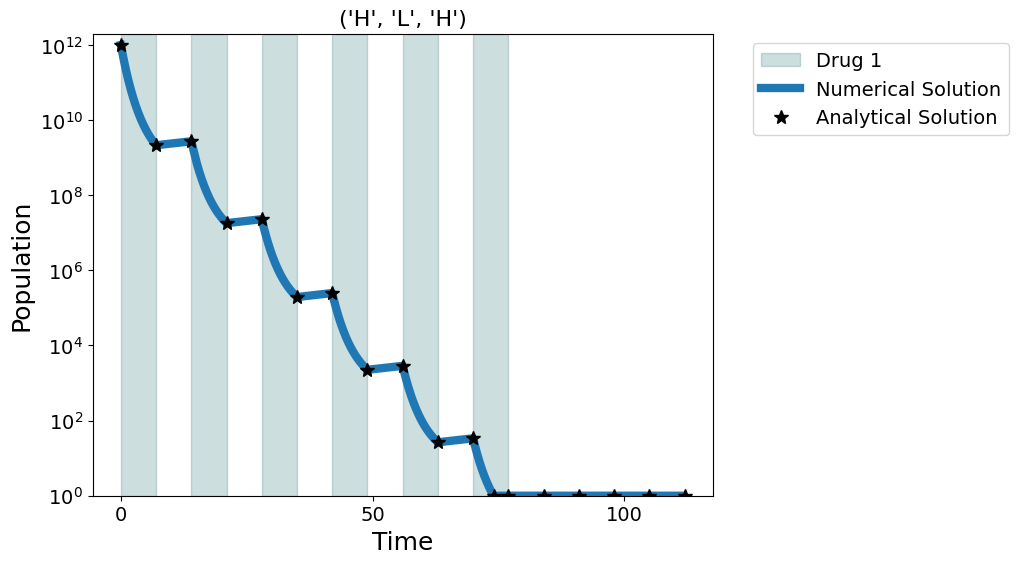

In [22]:
# pick out HLH and brute force it
params = combos[3]
metric = 'CURE'
scheduleevals = SU.strategy_eval_full_sim(params,gamma,16,metric=metric)

# plot the results
optimalschedule = SU.print_stats(scheduleevals,metric)
fig = SU.full_sim(params,optimalschedule,timepercycle=7)
analyticalt,analyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],optimalschedule,timepercycle, *params)
plt.plot(analyticalt,[yy[0] for yy in analyticaly],'k*',markersize=10,label='Analytical Solution')
comboname = (deltanames[np.round(params[1][0] / params[0],2)],rnames[params[2][0] / params[0]],snames[params[3][0] / params[0]])
plt.title('{}'.format(comboname),fontsize=16)
plt.ylim([1,2e12])
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Fig S4. Simulated annealing PFS comparison

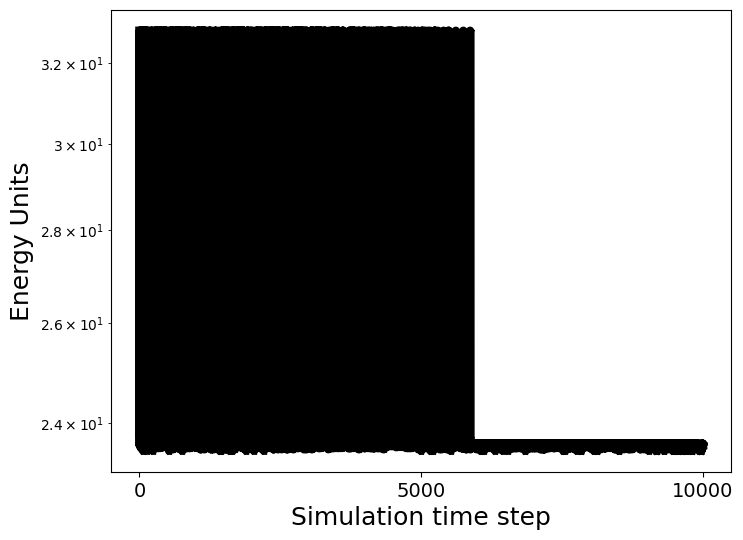

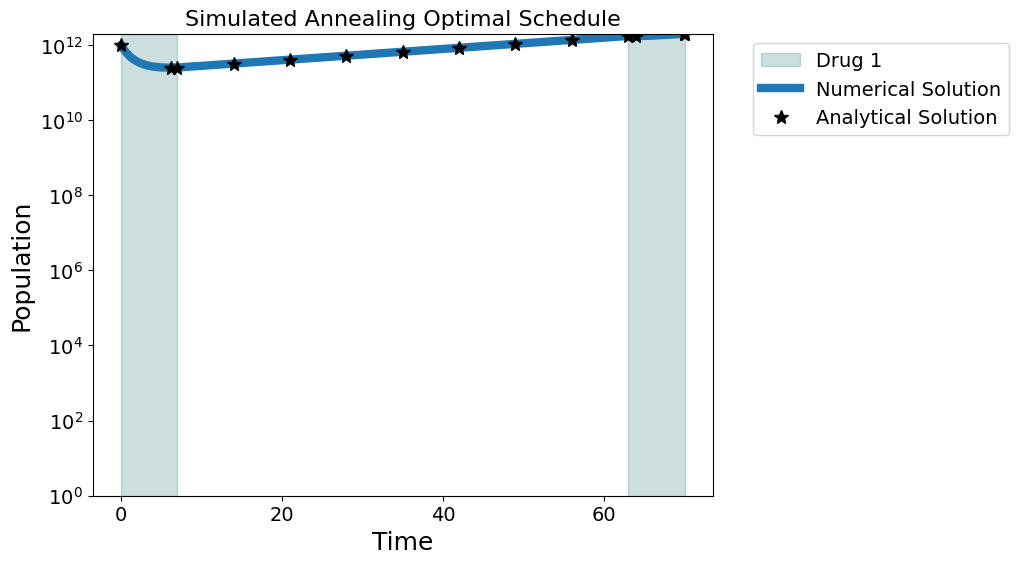

PFS optimal schedule is [{0}, set(), set(), set(), set(), set(), set(), set(), set(), {0}] with PFS time 69.93652709827575.


In [23]:
# pick out MHL again
params = combos[7]
metric = 'PFS'
timepercycle = 7
ncycles = 10000
beta0 = 0.01
optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, beta0=beta0)

# plot the energy as a function of iteration
fig = plt.figure(1,figsize=(8,6))
axs = plt.gca()
axs.plot(energies,'k*-',linewidth=6)
#plt.plot([1/betafxn(beta0,tt,ncycles) for tt in range(ncycles)],'r-',linewidth=6)
axs.set_ylabel('Energy Units',fontsize=18)
axs.set_xlabel('Simulation time step',fontsize=18)
plt.locator_params(nbins=4)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
axs.set_yscale('log')
plt.show()

#optimalstrategy = [{0}, set(), set(), set(), set(), set(), set(), set(), set(), {0}, set()]

# plot the SA optimal schedule
fig = SU.full_sim(params,optimalstrategy,timepercycle=timepercycle,legendon=False)
analyticalt,analyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],optimalstrategy,timepercycle, *params)
plt.plot(analyticalt,[yy[0] for yy in analyticaly],'k*',markersize=10,label='Analytical Solution')
plt.title('Simulated Annealing Optimal Schedule',fontsize=16)
plt.ylim([1,2e12])
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print(metric + ' optimal schedule is {} with PFS time {}.'.format(optimalstrategy,min([tt for tt,yy in zip(analyticalt,analyticaly) if yy[0] >= 2e12])))

## Fig S4. Simulated annealing CURE comparison

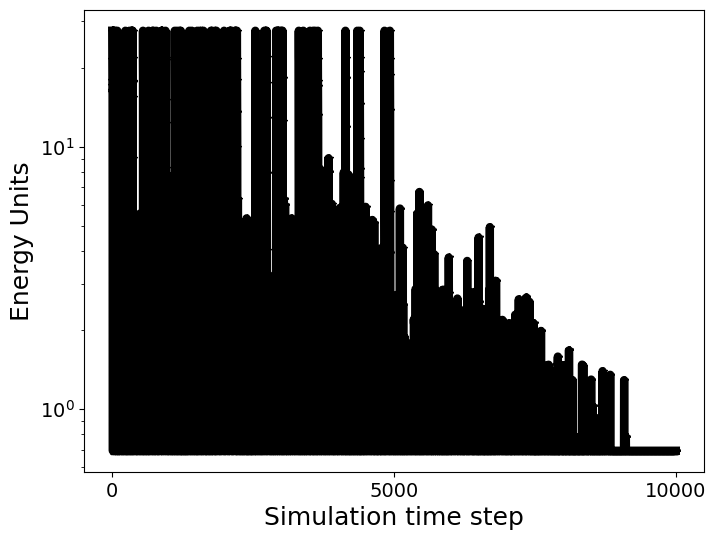

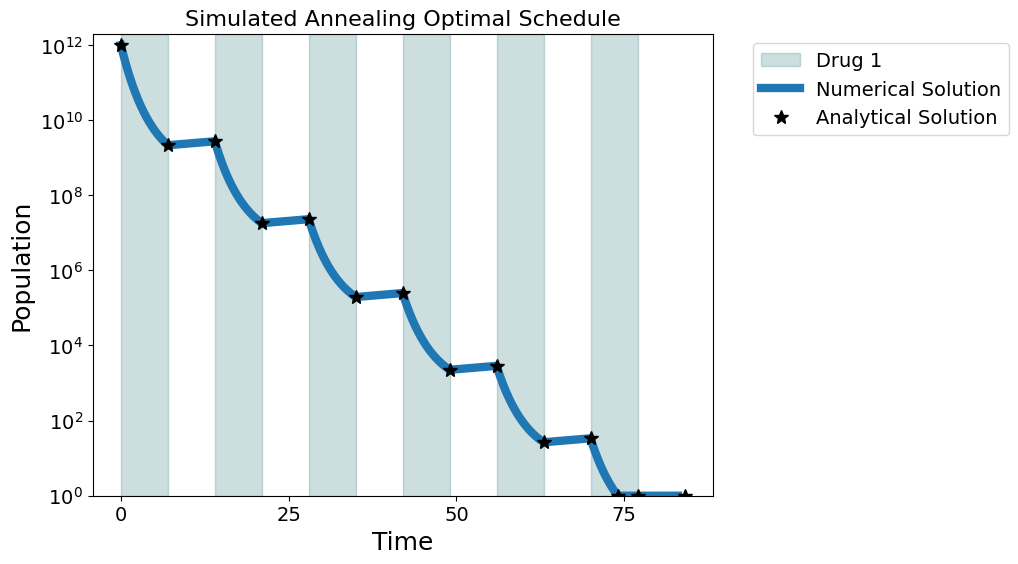

CURE optimal schedule is [{0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set()] with CURE time 74.04977475379724.


In [24]:
# pick out HLH again
params = combos[3]
metric = 'CURE'
timepercycle = 7
ncycles = 10000
beta0 = 0.01
optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, beta0=beta0)

# plot the energy as a function of ireteration
fig = plt.figure(1,figsize=(8,6))
axs = plt.gca()
axs.plot(energies,'k*-',linewidth=6)
#plt.plot([1/betafxn(beta0,tt,ncycles) for tt in range(ncycles)],'r-',linewidth=6)
axs.set_ylabel('Energy Units',fontsize=18)
axs.set_xlabel('Simulation time step',fontsize=18)
plt.locator_params(nbins=4)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
axs.set_yscale('log')
plt.show()

# plot the SA optimal schedule
fig = SU.full_sim(params,optimalstrategy,timepercycle=timepercycle,legendon=False)
analyticalt,analyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],optimalstrategy,timepercycle, *params)
plt.plot(analyticalt,[yy[0] for yy in analyticaly],'k*',markersize=10,label='Analytical Solution')
plt.title('Simulated Annealing Optimal Schedule',fontsize=16)
plt.ylim([1,2e12])
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print(metric + ' optimal schedule is {} with CURE time {}.'.format(optimalstrategy,min([tt for tt,yy in zip(analyticalt,analyticaly) if yy[0] <= 1])))

## Run the previous PFS optimization 100 times and see how often it gets exactly the right optimal schedule

In [25]:
# set the seed so the stats are as quoted in the paper
np.random.seed(0)

correctoptimum = [{0}, set(), set(), set(), set(), set(), set(), set(), set(), {0}]
params = combos[7]
metric = 'PFS'
timepercycle = 7
ncycles = 10000
beta0 = 0.01
correctcount = 0
Nruns = 100

# time it
start_time = time.time()

for kk in range(Nruns):
    optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, beta0=beta0)
    if optimalstrategy == correctoptimum:
        correctcount += 1

print('Found correct optimum {}/{} times'.format(correctcount,Nruns))
end_time = time.time()
elapsed_time = end_time - start_time
print("Elapsed time: {:.4f} seconds, {:.4f} seconds per trial".format(elapsed_time,elapsed_time / Nruns))

Found correct optimum 100/100 times
Elapsed time: 157.5562 seconds, 1.5756 seconds per trial


## Run the previous CURE optimization 100 times and see how often it gets exactly the right optimal schedule

In [26]:
# set the seed so the stats are as quoted in the paper
np.random.seed(0)

correctoptimum = [{0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set()]
params = combos[3]
metric = 'CURE'
timepercycle = 7
ncycles = 10000
beta0 = 0.01
correctcount = 0
Nruns = 100

# time it
start_time = time.time()

for kk in range(Nruns):
    optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, beta0=beta0)
    if optimalstrategy == correctoptimum:
        correctcount += 1

print('Found correct optimum {}/{} times'.format(correctcount,Nruns))
end_time = time.time()
elapsed_time = end_time - start_time
print("Elapsed time: {:.4f} seconds, {:.4f} seconds per trial".format(elapsed_time,elapsed_time / Nruns))

Found correct optimum 100/100 times
Elapsed time: 677.4775 seconds, 6.7748 seconds per trial


## Fig S5. Fixing an optimal schedule by standardization.

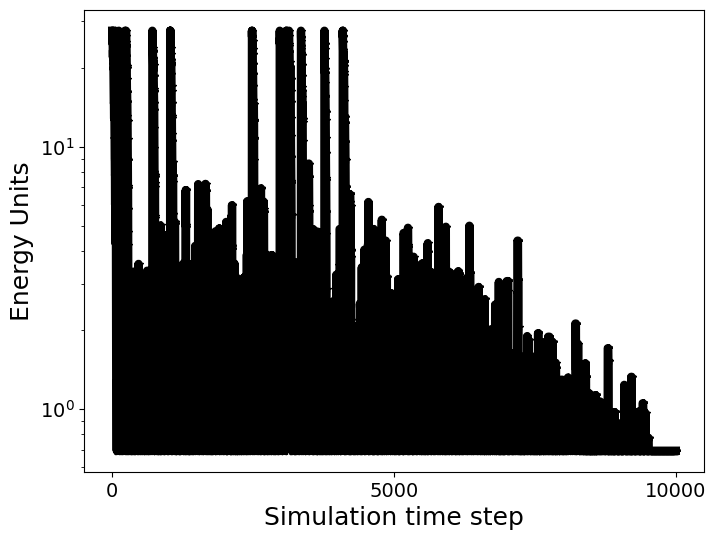

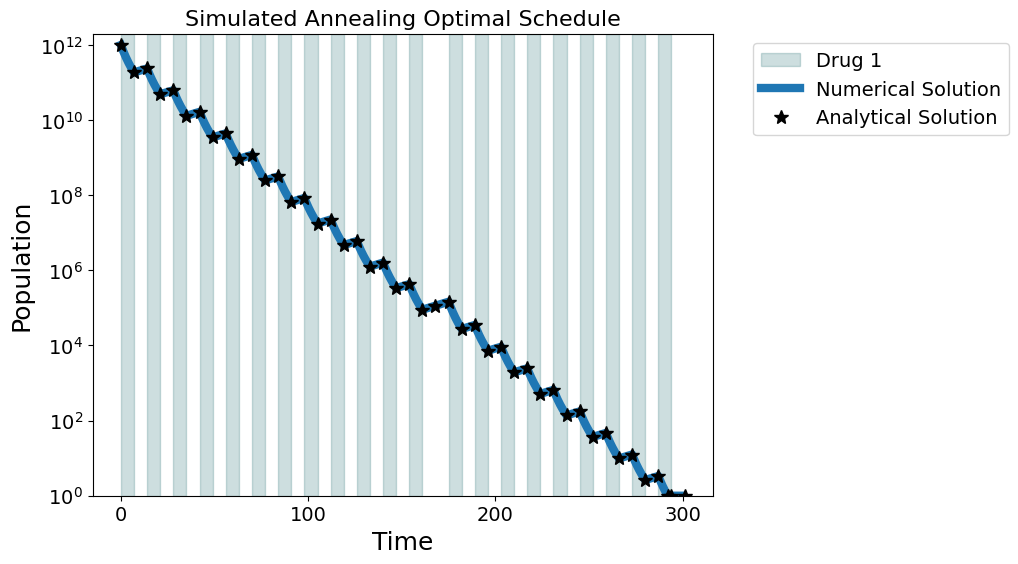

CURE optimal schedule is [{0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set()] with CURE time 292.0151368255503.


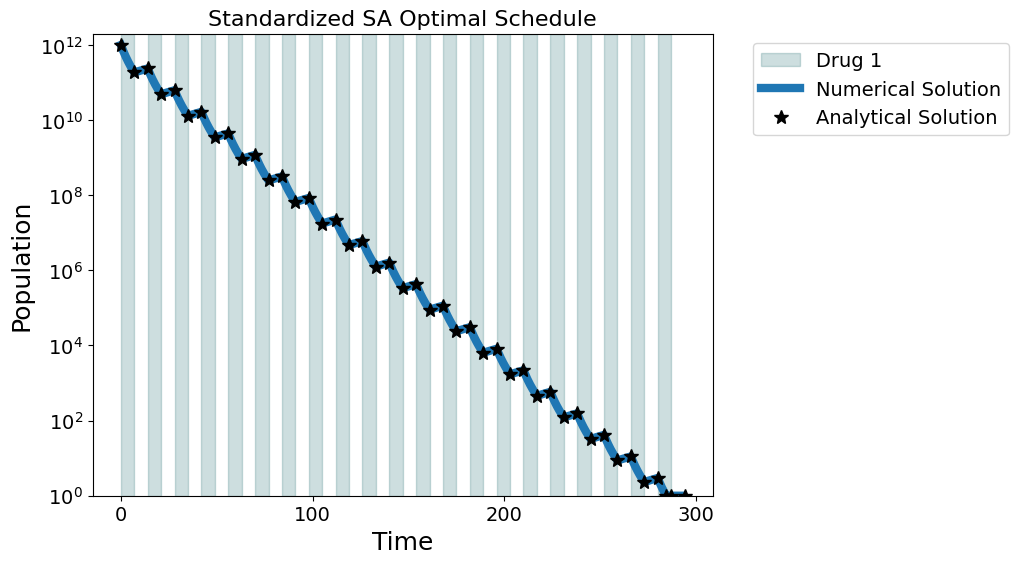

CURE standardized optimal schedule is [{0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set()] with CURE time 284.4143163599771.


In [27]:
# set the seed so you get one of the incorrect predictions
np.random.seed(11)

# New parameters
gamma = np.log(2)/20
deltamult = 10
rmult = 2
smult = 10
params = [gamma, [deltamult * gamma], [rmult * gamma], [smult * gamma]]
metric = 'CURE'
timepercycle = 7
ncycles = 10000
beta0 = 0.01
optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, beta0=beta0)

# plot the energy as a function of ireteration
fig = plt.figure(1,figsize=(8,6))
axs = plt.gca()
axs.plot(energies,'k*-',linewidth=6)
#plt.plot([1/betafxn(beta0,tt,ncycles) for tt in range(ncycles)],'r-',linewidth=6)
axs.set_ylabel('Energy Units',fontsize=18)
axs.set_xlabel('Simulation time step',fontsize=18)
plt.locator_params(nbins=4)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
axs.set_yscale('log')
plt.show()

# plot the SA optimal schedule
fig = SU.full_sim(params,optimalstrategy,timepercycle=timepercycle,legendon=False)
analyticalt,analyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],optimalstrategy,timepercycle, *params)
plt.plot(analyticalt,[yy[0] for yy in analyticaly],'k*',markersize=10,label='Analytical Solution')
plt.title('Simulated Annealing Optimal Schedule',fontsize=16)
plt.ylim([1,2e12])
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print(metric + ' optimal schedule is {} with CURE time {}.'.format(optimalstrategy,min([tt for tt,yy in zip(analyticalt,analyticaly) if yy[0] <= 1])))

# Plot the standardized version of the optimal schedule
standardstrategy = SU.standardize_optimum(optimalstrategy,metric,params,timepercycle)
fig2 = SU.full_sim(params,standardstrategy,timepercycle=7)
sanalyticalt,sanalyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],standardstrategy,timepercycle, *params)
plt.plot(sanalyticalt,[yy[0] for yy in sanalyticaly],'k*',markersize=10,label='Analytical Solution')
plt.title('Standardized SA Optimal Schedule',fontsize=16)
plt.ylim([1,2e12])
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print(metric + ' standardized optimal schedule is {} with CURE time {}.'.format(standardstrategy,min([tt for tt,yy in zip(sanalyticalt,sanalyticaly) if yy[0] <= 1])))

## Run the previous CURE optimization 100 times and see how often it gets exactly the right optimal schedule

In [28]:
# set the seed so the stats match the paper
np.random.seed(1001)

# Same parameters as last code cell
gamma = np.log(2)/20
deltamult = 10
rmult = 2
smult = 10
params = [gamma, [deltamult * gamma], [rmult * gamma], [smult * gamma]]
metric = 'CURE'
timepercycle = 7
ncycles = 10000
beta0 = 0.01
strategystorage = []

correctoptimum1 = [{0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set()]
correctoptimum2 = [{0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}, set(), {0}] # should always have the last set(), but check against this one anyway
correctcount = 0
correctcountstandardized = 0
Nruns = 100

# time it
start_time = time.time()

for kk in range(Nruns):
    optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, beta0=beta0)
    standardstrategy = SU.standardize_optimum(optimalstrategy,metric,params,timepercycle)
    strategystorage.append(optimalstrategy)
    if optimalstrategy == correctoptimum1 or optimalstrategy == correctoptimum2:
        correctcount += 1

    if standardstrategy == correctoptimum1 or standardstrategy == correctoptimum2:
        correctcountstandardized += 1

print('Simulated Annealing found the correct optimum {}/{} times'.format(correctcount,Nruns))
print('Adding standardization, the correct optimum was found {}/{} times'.format(correctcountstandardized,Nruns))
end_time = time.time()
elapsed_time = end_time - start_time
print("Elapsed time: {:.4f} seconds, {:.4f} seconds per trial".format(elapsed_time,elapsed_time / Nruns))

Simulated Annealing found the correct optimum 31/100 times
Adding standardization, the correct optimum was found 99/100 times
Elapsed time: 1433.7428 seconds, 14.3374 seconds per trial


## Fig S6. Demonstrating the 4 schedules tested for optimality in the one drug case.

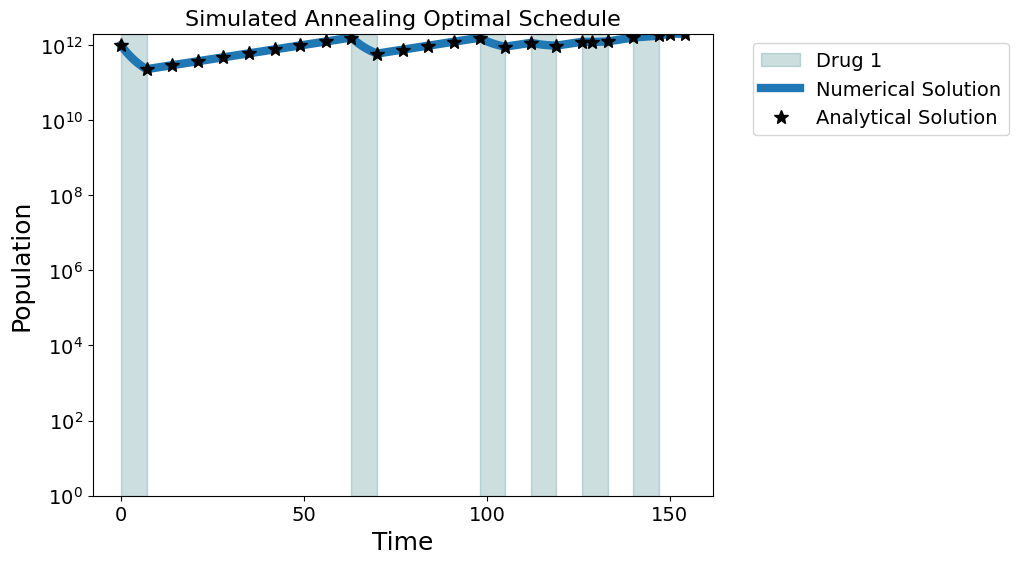

Simulated annealing PFS time = 150.09682303064096 days


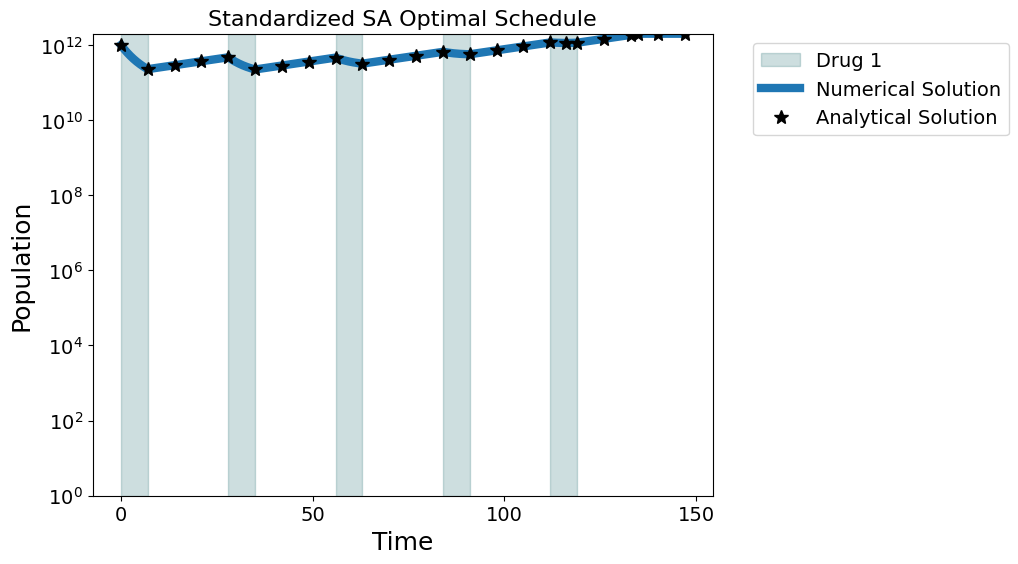

Standardized simulated annealing PFS time = 134.89656918860643 days


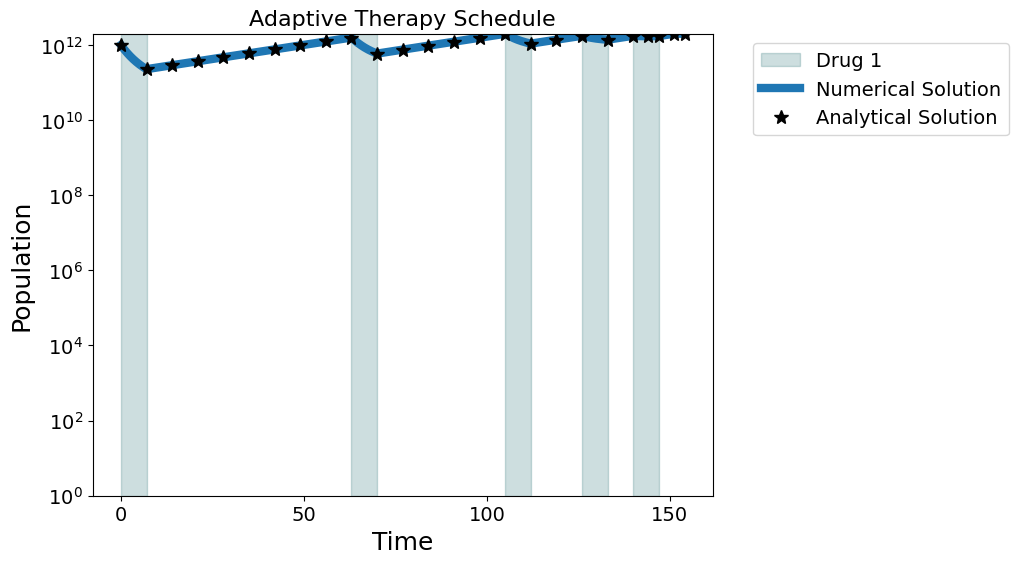

Adaptive therapy PFS time = 151.08357653339945 days


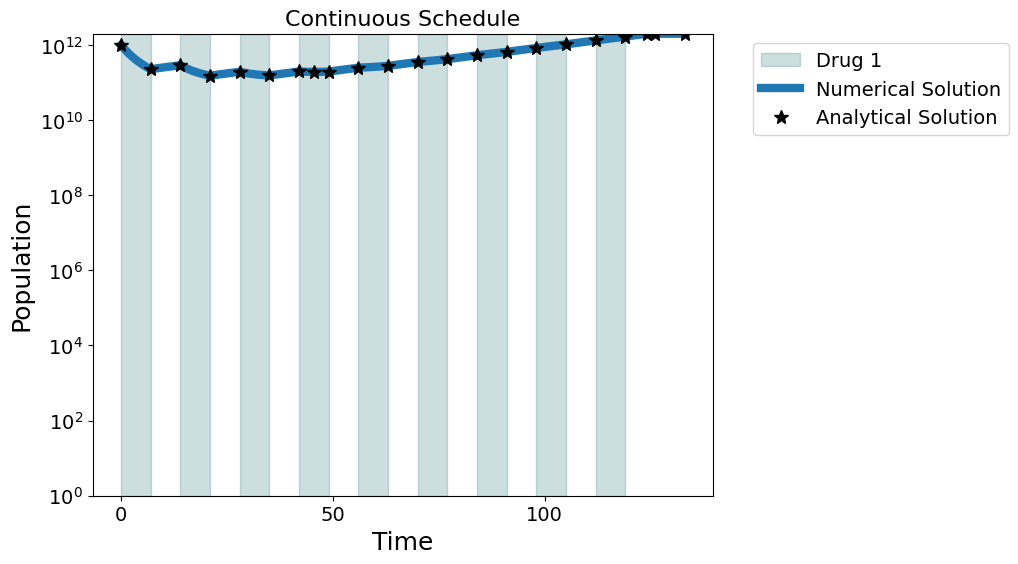

Continuous therapy PFS time = 124.12037427750774 days


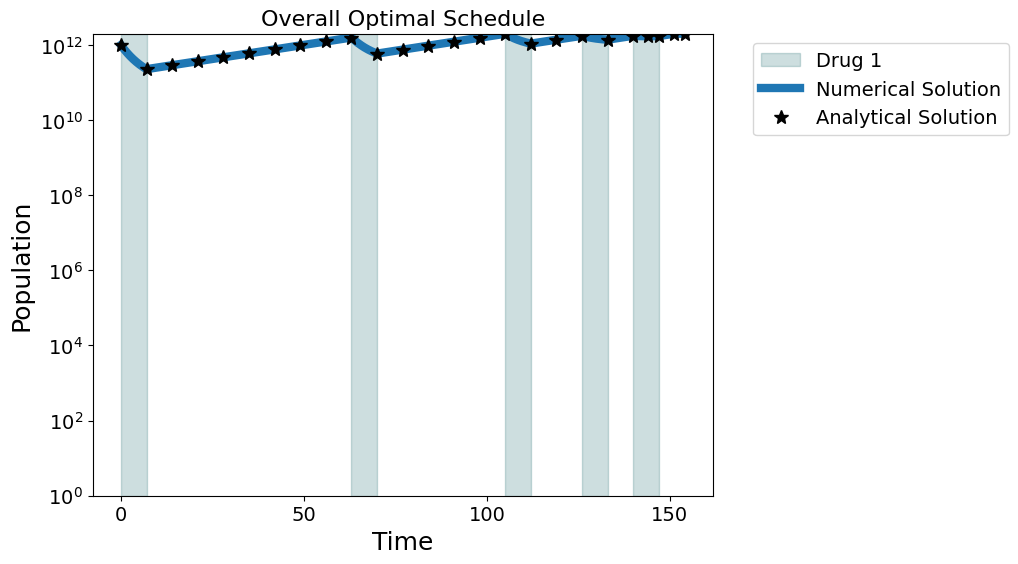

Overall optimum schedule PFS time = 151.08357653339945 days


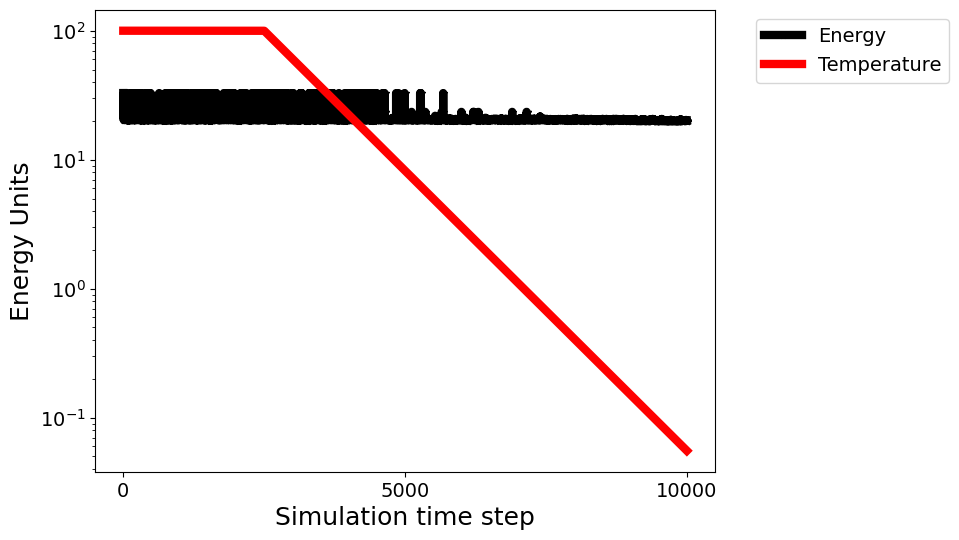

In [29]:
# set the seed so you get exactly the plots from the paper
np.random.seed(3)

gamma = np.log(2)/20
deltamult = 10
rmult = 3
smult = 1/2
params = [gamma, [deltamult * gamma], [rmult * gamma], [smult * gamma]]
metric = 'PFS'
timepercycle = 7
ncycles = 10000
beta0 = 0.01
optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, beta0=beta0)

# plot the SA optimal schedule
fig = SU.full_sim(params,optimalstrategy,timepercycle=timepercycle)
analyticalt,analyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],optimalstrategy,timepercycle, *params)
plt.plot(analyticalt,[yy[0] for yy in analyticaly],'k*',markersize=10,label='Analytical Solution')
plt.title('Simulated Annealing Optimal Schedule',fontsize=16)
plt.ylim([1,2e12])
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

pfstimeSA = SU.PFStime(analyticalt,analyticaly)
print('Simulated annealing PFS time = {} days'.format(pfstimeSA))

# standardized
standardstrategy = SU.standardize_optimum(optimalstrategy,metric,params,timepercycle)
fig2 = SU.full_sim(params,standardstrategy,timepercycle=7)
sanalyticalt,sanalyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],standardstrategy,timepercycle, *params)
plt.plot(sanalyticalt,[yy[0] for yy in sanalyticaly],'k*',markersize=10,label='Analytical Solution')
plt.ylim([1,2e12])
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Standardized SA Optimal Schedule',fontsize=16)
plt.show()

pfstimeSAstandardized = SU.PFStime(sanalyticalt,sanalyticaly)
print('Standardized simulated annealing PFS time = {} days'.format(pfstimeSAstandardized))

# AT
ATstrategy = SU.getATstrategy(metric,params,timepercycle)
fig9 = SU.full_sim(params,ATstrategy,timepercycle=7)
ATanalyticalt,ATanalyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],ATstrategy,timepercycle, *params)
plt.plot(ATanalyticalt,[yy[0] for yy in ATanalyticaly],'k*',markersize=10,label='Analytical Solution')
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Adaptive Therapy Schedule',fontsize=16)
plt.ylim([1,2e12])
plt.show()

pfstimeAT = SU.PFStime(ATanalyticalt,ATanalyticaly)
print('Adaptive therapy PFS time = {} days'.format(pfstimeAT))

# continuous
ctsstrategy = SU.regularize([1e12,1],sum([[{0},set()] for kk in range(int(len(optimalstrategy)/2))],[]),timepercycle,*params)
fig10 = SU.full_sim(params,ctsstrategy,timepercycle=7)
ctsanalyticalt,ctsanalyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],ctsstrategy,timepercycle, *params)
plt.plot(ctsanalyticalt,[yy[0] for yy in ctsanalyticaly],'k*',markersize=10,label='Analytical Solution')
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Continuous Schedule',fontsize=16)
plt.ylim([1,2e12])
plt.show()

pfstimects = SU.PFStime(ctsanalyticalt,ctsanalyticaly)
print('Continuous therapy PFS time = {} days'.format(pfstimects))

# overall
overalloptimalstrategy = SU.get_final_optimum(optimalstrategy,metric,params,timepercycle)
fig = SU.full_sim(params,overalloptimalstrategy,timepercycle=timepercycle)
analyticalt,analyticaly = SU.GDRSanalytical([1e12] + [1 for kk in params[1]],overalloptimalstrategy,timepercycle, *params)
plt.plot(analyticalt,[yy[0] for yy in analyticaly],'k*',markersize=10,label='Analytical Solution')
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Overall Optimal Schedule',fontsize=16)
plt.ylim([1,2e12])
plt.show()

pfstimeoverall = SU.PFStime(analyticalt,analyticaly)
print('Overall optimum schedule PFS time = {} days'.format(pfstimeoverall))

fig = plt.figure(6,figsize=(8,6))
plt.plot(energies,'k*-',linewidth=6, label='Energy')
plt.plot([1/SU.betafxn(beta0,tt,ncycles) for tt in range(ncycles)],'r-',linewidth=6,label='Temperature')
plt.ylabel('Energy Units',fontsize=18)
plt.xlabel('Simulation time step',fontsize=18)
plt.locator_params(nbins=4)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.yscale('log')
plt.show()

## Fig S8. The effect of varying gamma and delta on the curative cycle boundary

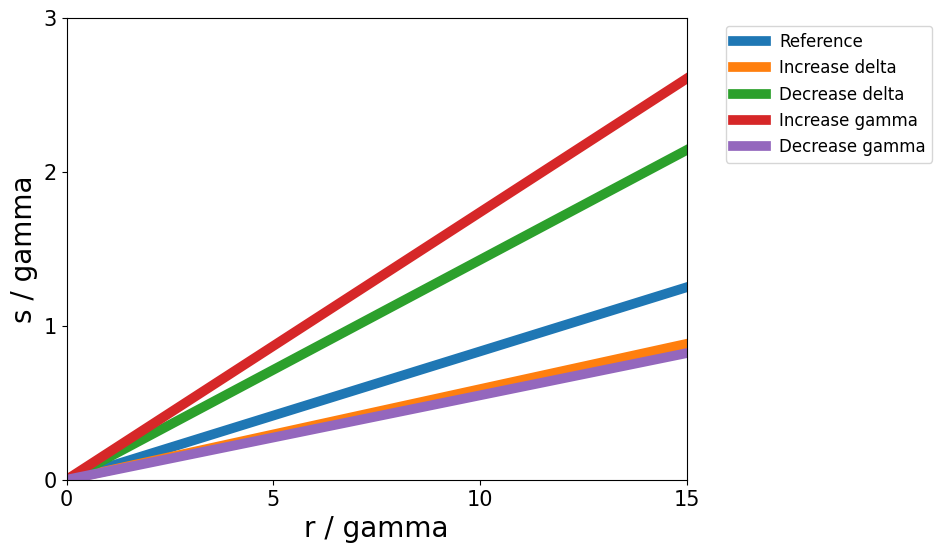

In [30]:
smin = 0 
smax = 3 * np.log(2) / 20
gammasweep = [np.log(2) / 20, np.log(2) / 20, np.log(2) / 20, np.log(2) / 10, np.log(2) / 30]
deltasweep = [5 * np.log(2) / 2, 7 * np.log(2) / 2, 3 * np.log(2) / 2, 5 * np.log(2) / 2, 5 * np.log(2) / 2]
labels = ['Reference', 'Increase delta', 'Decrease delta', 'Increase gamma', 'Decrease gamma']
plt.figure(329847,figsize=(8,6))
for gg,dd,ll in zip(gammasweep,deltasweep,labels):
    svalsboundary = [(smin + kk/100 *(smax - smin))for kk in range(1001)]
    rvalsboundary = [(ssval * (dd * (1 + gg / dd)**2 / (4 * gg) - 1)) / gg  for ssval in svalsboundary]
    svalsboundary = [ssval / gg for ssval in svalsboundary]
    # get the bounds for x and y so we can keep the plot the same
    plt.plot(rvalsboundary,svalsboundary,linewidth=7,label=ll)#'gamma = {:.3f}, delta = {:.3f}'.format(gg,dd))

plt.legend(fontsize=12,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.locator_params(nbins=4)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('r / gamma',fontsize=20)
plt.ylabel('s / gamma',fontsize=20)
plt.xlim([0,15])
plt.ylim([0,3])
plt.show()

## Fig S9. Alternative schedule labeling for the 2 drug PFS phase diagram

In [31]:
# Do the phase space calculation with the simulated annealing algorithm, but this time use the alternate optimum schedule sorting algorithm

# this calculation is quite stochastic. That's because the classification system isn't perfect, so the results are more prone to the simulated annealing variance
np.random.seed(329847)

# first make all possible param values
gamma = np.log(2) / 20
delta1 = 50 * gamma
delta2 = 40 * gamma
r2 = 7 * gamma
s2 = 0 * gamma
rmin = 10 * gamma 
rmax = 20 * gamma
smin = 0 
smax = 3 * gamma
linsamplenr = 9
linsamplens = 3
nwindows = 16
timepercycle = 7
rvals = [rmin + kk * (rmax - rmin) / linsamplenr for kk in range(linsamplenr+1)]
svals = [smin + kk * (smax - smin) / linsamplens for kk in range(linsamplens+1)]
phasespace = [[gamma, [delta1, delta2], [rr,r2], [ss,s2]] for rr in rvals for ss in svals]
rvalsX = [ps[2][0] / ps[0] for ps in phasespace]
svalsY = [ps[3][0] / ps[0] for ps in phasespace]

# set up other parameters and stuff for the loop
metric = 'PFS' 
storage = []
storageE = []
storagereport = []
ncycles = 10000

# additional variables
curethresh = 1
progthresh = 2e12
print('Searching {} points in phase space'.format(len(phasespace)))

# time it
start_time = time.time()

for psindx,params in enumerate(phasespace):
    strategystart = None  
    if metric == 'PFS' and 'curestorage' in locals():
        strategystart = curestorage[psindx]
        
    optimalstrategy,energies = SU.optimize(params, metric=metric, ncycles=ncycles, timepercycle=timepercycle, storeallschedules=False, waitperiod=True, strategystart=strategystart)
    overalloptimalstrategy,report = SU.get_final_optimum2_alternate(optimalstrategy,metric,params,timepercycle,reporting=True)
    storage.append(overalloptimalstrategy)
    storageE.append(energies)
    storagereport.append(report)

end_time = time.time()
print('Done!')
elapsed_time = end_time - start_time
print("Elapsed time: {:.4f} seconds, {:.4f} seconds per parameter set".format(elapsed_time,elapsed_time / len(phasespace)))

# store all the cure schedules to use as the starting point for the PFS run
if metric == 'CURE':
    curestorage = copy.deepcopy(storage)
    

Searching 40 points in phase space
Done!
Elapsed time: 282.3945 seconds, 7.0599 seconds per parameter set


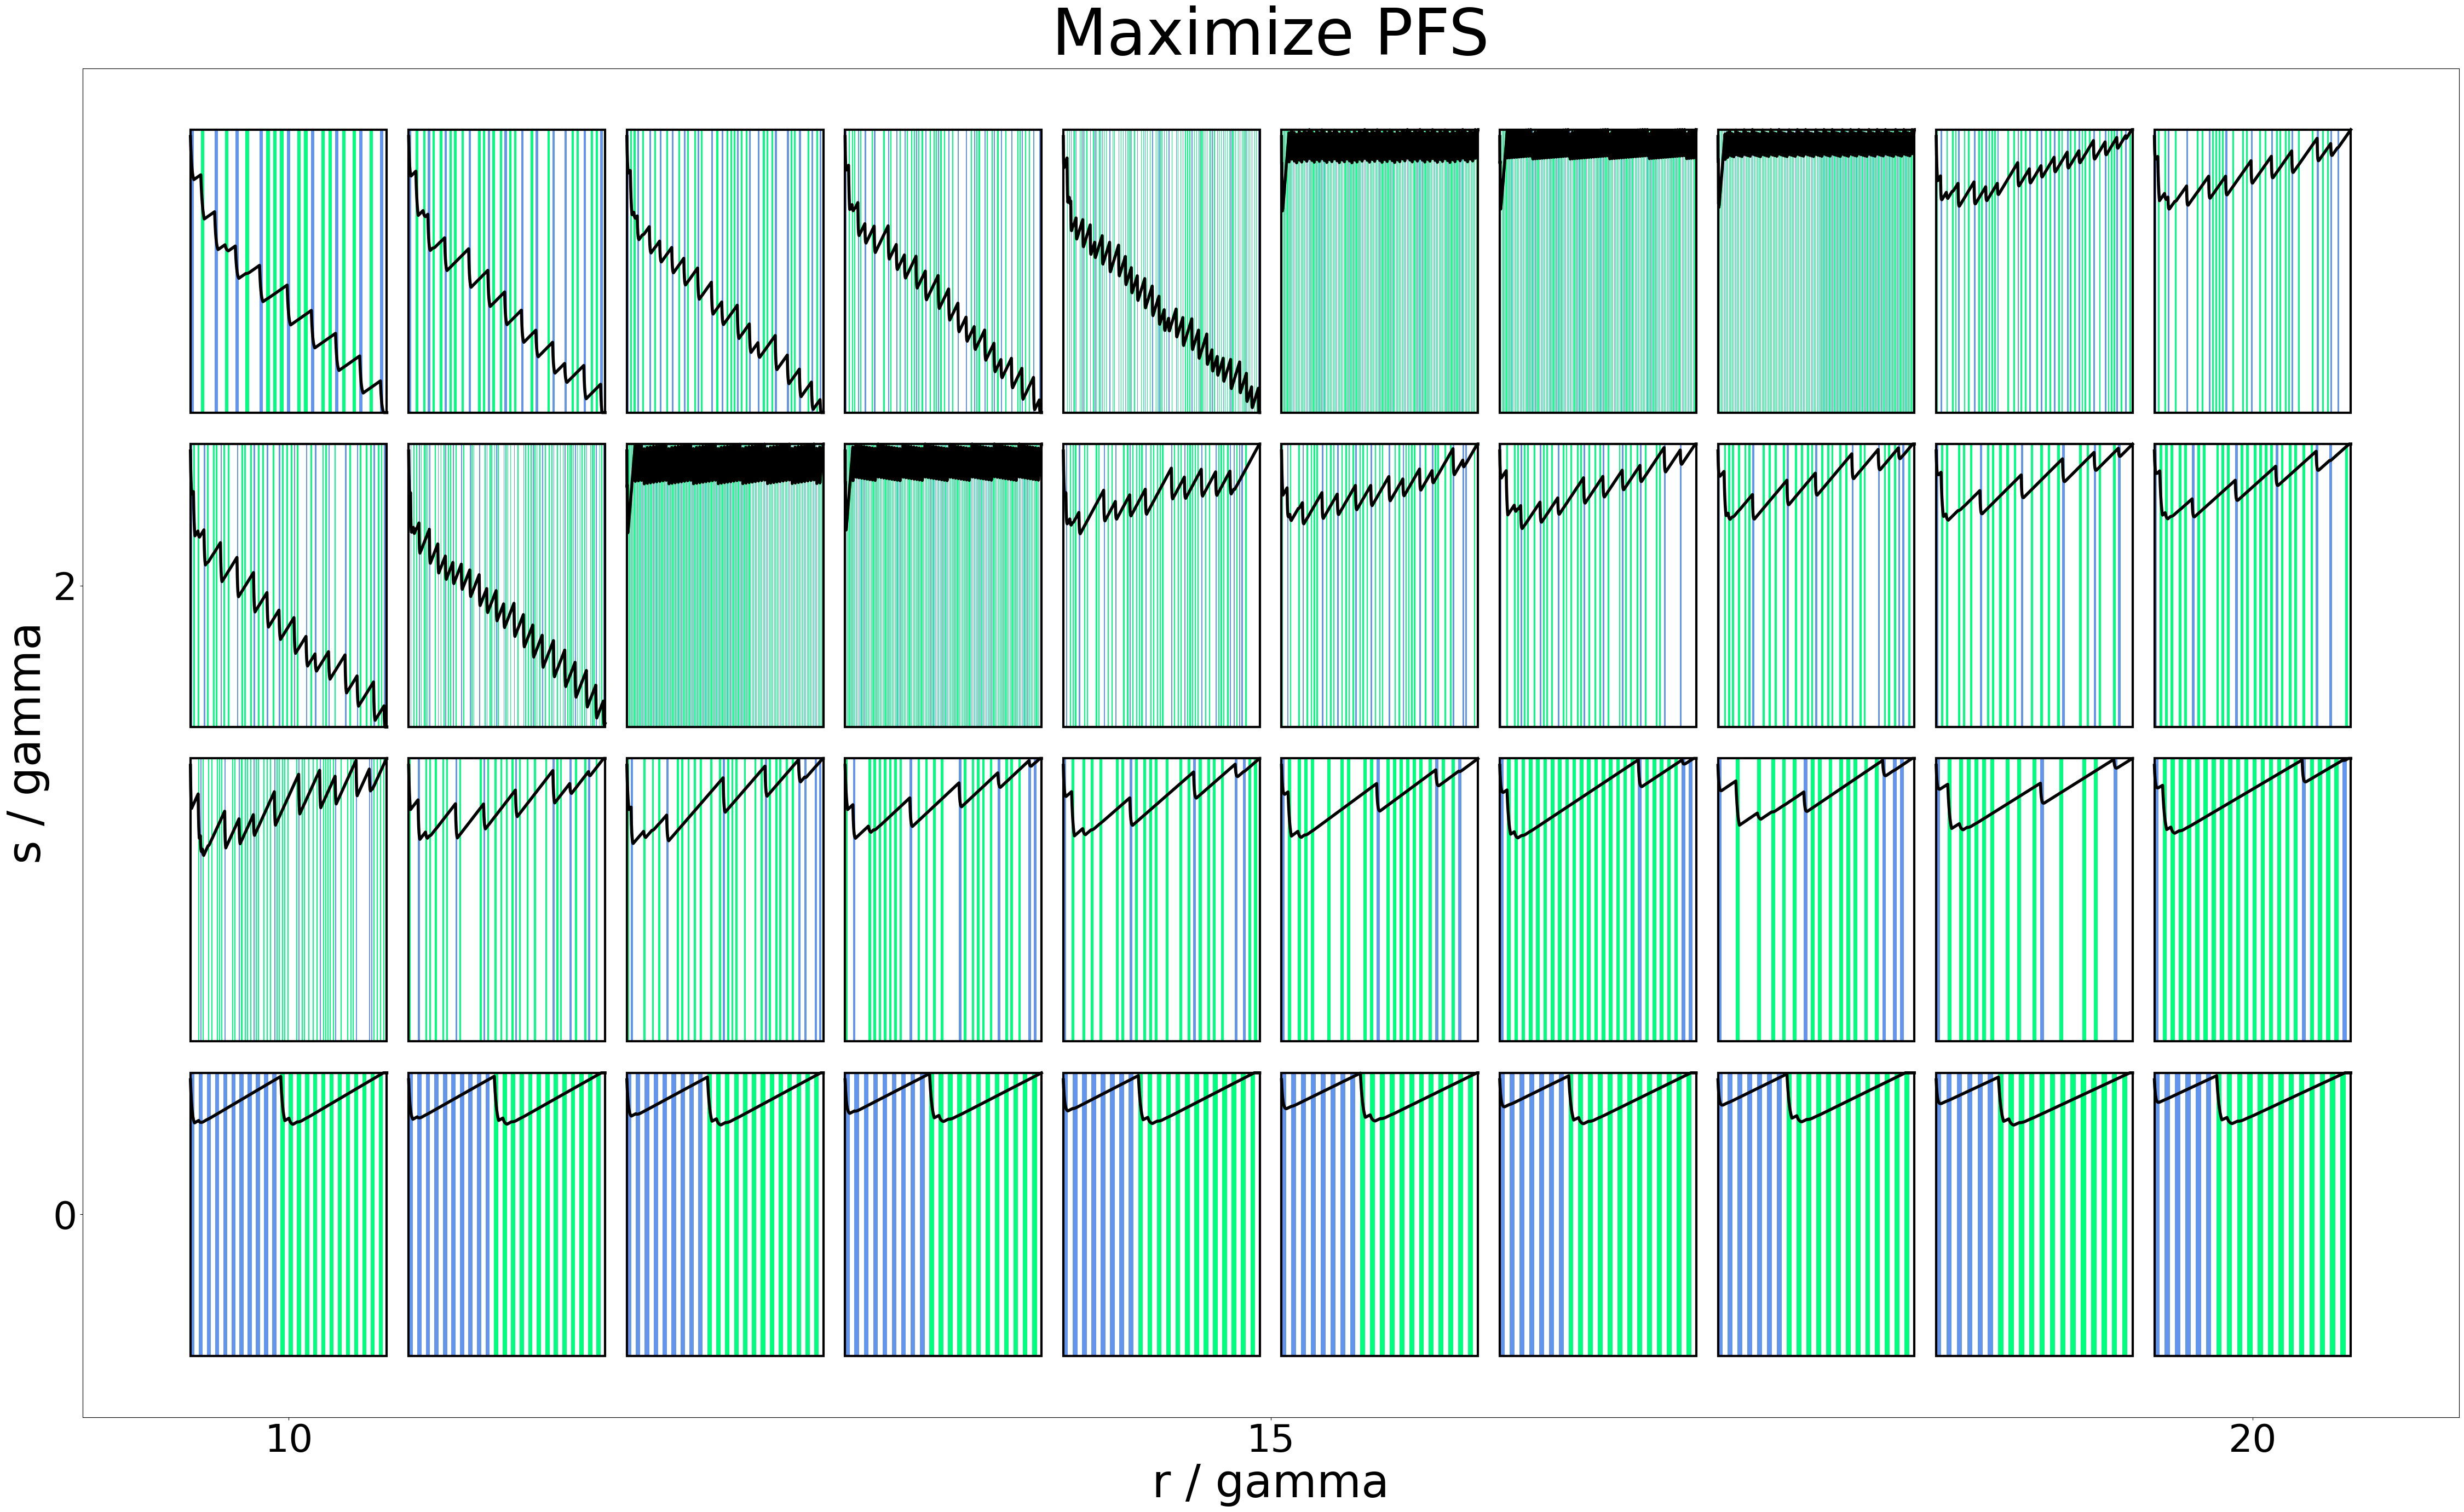

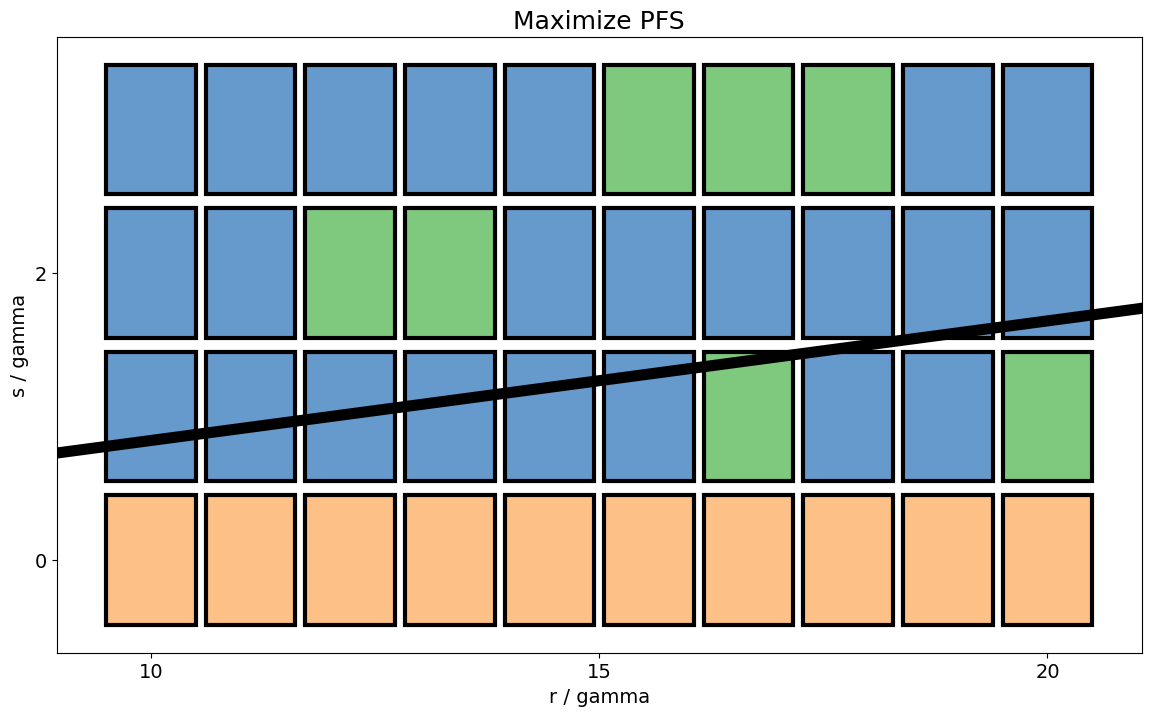

In [32]:
SU.plotphasediagram2_alternate(storage,phasespace,storagereport,timepercycle,rvals,svals,rvalsX,svalsY,gamma,metric,delta1,smin,smax)